In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import joblib
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import ipywidgets as widgets


In [3]:
# [Cell 1: LOAD DATA + FEATURE ENGINEERING + 3 GW Horizon for difficultu + total Difficulty Score (FDI_3GW). ]

INPUT_FILE = '../output/dataset_no0min.csv'
ENHANCED_FEATURES_OUT = '../output/forecaster_pro/fpl_features_augmented.csv'
df = pd.read_csv(INPUT_FILE)

def enrich_features_v2(df):
    """
    Final Strategic Consolidation + 3-GW Fixture Horizon:
    - Ranked Deduplication (Max 2 matches per GW).
    - Season Baseline Bridge for GW1/GW2 stability.
    - 3-GW Fixture Difficulty Index (FDI_3GW).
    """

    # --- STEP 0: PRE-CLEAN ---
    df['Minutes Played'] = df['Minutes Played'].clip(upper=90)

    # --- STEP 1: RANKED DEDUPLICATION ---
    df = df.sort_values(
        ['Player UUID', 'season', 'Gameweek', 'Minutes Played', 'Total Points'],
        ascending=[True, True, True, False, False]
    )
    df = df.groupby(['Player UUID', 'season', 'Gameweek']).tail(2)

    # --- STEP 2: CHRONOLOGICAL RE-SORT ---
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    # --- STEP 3: INTEGRITY AUDIT ---
    counts = df.groupby(['Player UUID', 'season', 'Gameweek']).size().reset_index(name='match_count')
    legit_dgws = counts[counts['match_count'] == 2]
    suspicious = counts[counts['match_count'] > 2]

    print(f"--- Final Integrity Audit ---")
    print(f"Legitimate DGW Match Pairs (Time-Series): {len(legit_dgws)}")
    print(f"Suspicious GWs (>2 matches): {len(suspicious)} (TARGET: 0)")
    print(f"Max Minutes in a single row: {df['Minutes Played'].max()}")

    # --- STEP 4: CORE FEATURES & 3-GW HORIZON ---
    df['Rolling_Avg_Minutes_5'] = df.groupby('Player UUID')['Minutes Played'].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    ).fillna(0)

    # Immediate Next Game (GW+1)
    df['Next_Opponent_Difficulty'] = df.groupby(['Player UUID', 'season'])['Opponent Difficulty'].shift(-1)
    df['Next_Is_Home'] = df.groupby(['Player UUID', 'season'])['Is Home'].shift(-1)

    # Future Horizon (GW+2 and GW+3)
    # We use fillna(3) to assume neutral average difficulty if the season ends before 3 games
    df['Opponent_Diff_plus_2'] = df.groupby(['Player UUID', 'season'])['Opponent Difficulty'].shift(-2).fillna(3)
    df['Opponent_Diff_plus_3'] = df.groupby(['Player UUID', 'season'])['Opponent Difficulty'].shift(-3).fillna(3)

    # Total 3-GW Fixture Difficulty Index (FDI_3GW)
    df['FDI_3GW'] = df['Next_Opponent_Difficulty'].fillna(3) + df['Opponent_Diff_plus_2'] + df['Opponent_Diff_plus_3']

    df['Season_Phase'] = pd.cut(
        df['Gameweek'], bins=[0, 10, 19, 29, 38], labels=[1, 2, 3, 4]
    ).astype(float)

    # --- STEP 5: TEAM POINT SHARE (fully lagged, no leakage) ---
    team_col = next((c for c in ['Player Team ID', 'team', 'Player Team Name'] if c in df.columns), None)
    if team_col:
        df['_prev_individual_pts'] = df.groupby('Player UUID')['Total Points'].shift(1)
        df['_prev_team_total'] = df.groupby(
            [team_col, 'season', 'Gameweek']
        )['_prev_individual_pts'].transform('sum')

        df['Team_Point_Share'] = (
            df['_prev_individual_pts'] / df['_prev_team_total']
        ).replace([np.inf, -np.inf], 0).fillna(0)

        df.drop(columns=['_prev_individual_pts', '_prev_team_total'], inplace=True)
    else:
        df['Team_Point_Share'] = 0

    # --- STEP 6: SEASON BASELINE BRIDGE (no current-season leakage) ---
    season_stats = df.groupby(['Player UUID', 'season'])['Total Points'].mean().reset_index()
    season_stats.rename(columns={'Total Points': 'Season_Avg_Points'}, inplace=True)

    # shift(1) on the season axis: season N gets season N-1's completed average
    season_stats['Prev_Season_Avg_Points'] = season_stats.groupby(
        'Player UUID'
    )['Season_Avg_Points'].shift(1)

    df = df.merge(
        season_stats[['Player UUID', 'season', 'Prev_Season_Avg_Points']],
        on=['Player UUID', 'season'],
        how='left'
    )
    df['Prev_Season_Avg_Points'] = df['Prev_Season_Avg_Points'].fillna(0)

    # --- STEP 7: AVG POINTS VS DIFFICULTY (Historical Performance by Fixture Type) ---
    # For each player, calculate their average points scored against each
    # difficulty level (1–5) using only PAST data (fully lagged via shift(1)).
    # This captures whether a player consistently performs vs easy/hard opponents.
    # Zero data leakage: we use the shifted cumulative mean, not the current match.

    # Group by player + difficulty, compute expanding mean of past performances
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    # Shift points by 1 so we never use the current match
    df['_pts_shifted'] = df.groupby('Player UUID')['Total Points'].shift(1)

    # For each row, compute the historical avg points for this player
    # at this exact difficulty level
    df['Avg_Pts_vs_Difficulty'] = (
        df.groupby(['Player UUID', 'Opponent Difficulty'])['_pts_shifted']
        .transform(lambda x: x.expanding().mean())
        .fillna(0)
    )

    # Clean up temp column
    df.drop(columns=['_pts_shifted'], inplace=True)

    # Integrity check: should be between 0 and ~15, never negative
    _avg_max = df['Avg_Pts_vs_Difficulty'].max()
    _avg_mean = df['Avg_Pts_vs_Difficulty'].mean()
    print(f"Avg_Pts_vs_Difficulty: max={_avg_max:.2f}, mean={_avg_mean:.2f} (expected ~2-4)")

    # --- FINAL STEP: DROP ROWS WHERE NEXT MATCH CONTEXT IS UNKNOWN ---
    return df.dropna(subset=['Next_Opponent_Difficulty'])


# Run and Save
df_augmented = enrich_features_v2(df)
df_augmented.to_csv(ENHANCED_FEATURES_OUT, index=False, encoding='utf-8-sig')

print(f"Enhanced dataset created: {ENHANCED_FEATURES_OUT}")

# Display the new 3-GW Fixture features for verification
print("\n--- 3-GW Fixture Horizon Verification ---")
display(df_augmented[[
    'Web Name', 'season', 'Gameweek', 
    'Next_Opponent_Difficulty', 'Opponent_Diff_plus_2', 'Opponent_Diff_plus_3', 'FDI_3GW'
]].tail(10))

--- Final Integrity Audit ---
Legitimate DGW Match Pairs (Time-Series): 2465
Suspicious GWs (>2 matches): 0 (TARGET: 0)
Max Minutes in a single row: 90
Avg_Pts_vs_Difficulty: max=21.00, mean=2.84 (expected ~2-4)
Enhanced dataset created: ../output/forecaster_pro/fpl_features_augmented.csv

--- 3-GW Fixture Horizon Verification ---


,Web Name,season,Gameweek,Next_Opponent_Difficulty,Opponent_Diff_plus_2,Opponent_Diff_plus_3,FDI_3GW
63950,Uche,2025-26,9,3.0,3.0,4.0,10.0
63951,Uche,2025-26,13,3.0,4.0,3.0,10.0
63952,Uche,2025-26,15,4.0,3.0,3.0,10.0
63953,Uche,2025-26,16,3.0,3.0,2.0,8.0
63954,Uche,2025-26,17,3.0,2.0,4.0,9.0
63955,Uche,2025-26,18,2.0,4.0,3.0,9.0
63956,Uche,2025-26,19,4.0,3.0,3.0,10.0
63957,Uche,2025-26,20,3.0,3.0,1.0,7.0
63958,Uche,2025-26,23,3.0,1.0,3.0,7.0
63959,Uche,2025-26,24,1.0,3.0,3.0,7.0


In [4]:
# ── INTEGRITY CHECK: confirm all 3-GW columns were created ──────────────────
required_cols = ['Next_Opponent_Difficulty', 'Opponent_Diff_plus_2', 
                 'Opponent_Diff_plus_3', 'FDI_3GW']
missing = [c for c in required_cols if c not in df_augmented.columns]
if missing:
    print(f"ALERT: Missing 3-GW columns: {missing}. Check Cell 1 logic.")
else:
    fdi_range = df_augmented['FDI_3GW'].describe()
    print(f"\n3-GW Feature Integrity Check:")
    print(f"  FDI_3GW range: {fdi_range['min']:.1f} to {fdi_range['max']:.1f}")
    print(f"  FDI_3GW mean: {fdi_range['mean']:.2f}  (expected ~9.0 for neutral fixtures)")
    print(f"  All 3-GW columns present: OK")


3-GW Feature Integrity Check:
  FDI_3GW range: 4.0 to 15.0
  FDI_3GW mean: 8.80  (expected ~9.0 for neutral fixtures)
  All 3-GW columns present: OK


In [5]:
#  [Cell: Final Data Scrub - Removing Verified Ghosts]

# List of players verified as inactive in the 2025-26 Premier League
verified_ghosts = ['Thiago', 'Mane', 'Bale', 'Sadio Mané']

# Filter out these specific names ONLY for the 2025-26 season rows
# We keep them for older seasons so the model can still learn from their history
initial_count = len(df_augmented)

df_augmented = df_augmented[~(
    (df_augmented['Web Name'].isin(verified_ghosts)) & 
    (df_augmented['season'] == '2025-26')
)].copy()

removed_count = initial_count - len(df_augmented)
print(f"Surgical Clean Complete: Removed {removed_count} ghost rows from 2025-26.")

Surgical Clean Complete: Removed 27 ghost rows from 2025-26.


## Prev_Season_Avg_Points

It calculates the average points a player earned over the entire previous season.

It maps that average forward to the current season.

Result: The model now knows if a player is "Class" (e.g., Salah averaging 7 points all year) vs. just being in "Form" for a few weeks. This makes GW1 and GW2 predictions much more stable.

In [6]:
# [Cell: Verification - Salah's Season Bridge]

# 1. Identify Salah's UUID
# (search for 'salah' in the Web Name to be safe)
salah_data = df_augmented[df_augmented['Web Name'].str.contains('Salah', case=False, na=False)]

if not salah_data.empty:
    s_uuid = salah_data['Player UUID'].iloc[0]
    
    # 2. Get the transition rows (End of 24/25 and Start of 25/26)
    # We sort to ensure chronological order
    salah_history = df_augmented[df_augmented['Player UUID'] == s_uuid].sort_values(['season', 'Gameweek'])
    
    # 3. Find the exact point where 2024-25 ends and 2025-26 begins
    transition_mask = (salah_history['season'] == '2025-26') & (salah_history['season'].shift(1) == '2024-25')
    
    if transition_mask.any():
        idx = salah_history[transition_mask].index[0]
        # Get 3 games before and 3 games after the summer break
        display_df = salah_history.loc[idx-3 : idx+2]
        
        print(f"--- Verification: Season Baseline Bridge (Mohamed Salah) ---")
        print("Note how 'Prev_Season_Avg_Points' appears only when the new season (2025-26) starts.")
        display(display_df[['Player Name', 'season', 'Gameweek', 'Total Points', 'Prev_Season_Avg_Points']])
    else:
        print("Could not find the 2024-25 to 2025-26 transition for Salah in this specific slice.")
else:
    print("Salah not found in the current df_augmented slice.")

--- Verification: Season Baseline Bridge (Mohamed Salah) ---
Note how 'Prev_Season_Avg_Points' appears only when the new season (2025-26) starts.


,Player Name,season,Gameweek,Total Points,Prev_Season_Avg_Points
2096,Mohamed Salah,2024-25,36,2,6.593750
2097,Mohamed Salah,2024-25,37,2,6.593750
2099,Mohamed Salah,2025-26,1,8,9.052632
2100,Mohamed Salah,2025-26,2,5,9.052632
2101,Mohamed Salah,2025-26,3,3,9.052632


In [7]:
#INVESTIGATION IN THE INPUT FILE 

# 1. Look at the suspicious GWs
dgws_investigation = df_augmented.groupby(['Player UUID', 'season', 'Gameweek']).filter(lambda x: len(x) > 2)

print(f"Investigating {len(dgws_investigation)} rows from suspicious Gameweeks...")

# 2. Check the 180 minute rows specifically
high_min_rows = df[df['Minutes Played'] >= 180]

print(f"Found {len(high_min_rows)} rows in the RAW dataset with >= 180 minutes.")

if not high_min_rows.empty:
    print("\nSample of 180-minute rows (Raw Data):")
    display(high_min_rows[['Player Name', 'season', 'Gameweek', 'Opponent Difficulty', 'Minutes Played', 'Total Points']].head(10))

if not dgws_investigation.empty:
    print("\nSample of 'Triple' Gameweek rows (After our current filter):")
    display(dgws_investigation[['Player Name', 'season', 'Gameweek', 'Opponent Difficulty', 'Minutes Played']].head(10))

Investigating 0 rows from suspicious Gameweeks...
Found 0 rows in the RAW dataset with >= 180 minutes.


In [8]:

# Filter for players who still have more than 2 entries in a single week
final_suspicious = df_augmented.groupby(['Player UUID', 'season', 'Gameweek']).filter(lambda x: len(x) > 2)

if not final_suspicious.empty:
    print(f"Found {final_suspicious['Player UUID'].nunique()} players across 176 suspicious GW instances.")
    # Display a few examples to see why they stayed
    display(final_suspicious[['Player Name', 'season', 'Gameweek', 'Opponent Difficulty', 'Minutes Played', 'Total Points']].head(15))
else:
    print("No suspicious rows found in the current df_augmented.")

No suspicious rows found in the current df_augmented.


In [9]:
# Check if "Doubles" are actually different matches
dgws_check = df_augmented.groupby(['Player UUID', 'season', 'Gameweek'])['Opponent Difficulty'].nunique()
fake_doubles = dgws_check[dgws_check > 2] # This shouldn't really happen
print(f"Number of suspicious GWs with >2 different difficulties: {len(fake_doubles)}")

Number of suspicious GWs with >2 different difficulties: 0


In [10]:
# [Cell: Updated Top-Tier Identification - 4.5 Threshold]
# 1. Calculate seasonal averages
seasonal_avg = df_augmented.groupby(['Player UUID', 'season'])['Total Points'].mean().reset_index()
seasonal_avg.rename(columns={'Total Points': 'avg_season_pts'}, inplace=True)

# 2. Cleanup & Merge
if 'avg_season_pts' in df_augmented.columns:
    df_augmented = df_augmented.drop(columns=['avg_season_pts'])
df_augmented = df_augmented.merge(seasonal_avg, on=['Player UUID', 'season'], how='left')

# 3. Define the New Global Elite Mask (> 4.5 avg points per season)
elite_mask = df_augmented['avg_season_pts'] > 4.5

print(f"--- Top-Tier Identification Summary (Threshold: 4.5) ---")
print(f"Total Rows in Dataset: {len(df_augmented):,}")
print(f"Total Elite Rows: {elite_mask.sum():,}")
print(f"Percentage of Data considered 'Elite': {(elite_mask.sum()/len(df_augmented))*100:.2f}%")

# 4. Display Table for Verification (Keep this if you like the visual check)
print(f"\nSample of Top Tier Players (Avg > 4.5 pts):")
elite_list = df_augmented[elite_mask][['Player Name', 'season', 'avg_season_pts']].drop_duplicates()
elite_list = elite_list.sort_values(by=['season', 'avg_season_pts'], ascending=[False, False])
display(elite_list.head(15))

--- Top-Tier Identification Summary (Threshold: 4.5) ---
Total Rows in Dataset: 60,670
Total Elite Rows: 4,629
Percentage of Data considered 'Elite': 7.63%

Sample of Top Tier Players (Avg > 4.5 pts):


,Player Name,season,avg_season_pts
10230,Erling Haaland,2025-26,7.192308
24992,Gabriel dos Santos Magalhães,2025-26,6.863636
50442,Declan Rice,2025-26,6.148148
8973,Bruno Borges Fernandes,2025-26,6.041667
23329,Antoine Semenyo,2025-26,6.038462
38628,Tom Edozie,2025-26,6.000000
45421,Matt O'Riley,2025-26,6.000000
3864,Bruno Guimarães Rodriguez Moura,2025-26,5.954545
52978,Daniel Muñoz Mejía,2025-26,5.631579
5739,Bukayo Saka,2025-26,5.500000


## Cell 2: Augmented Window Generation (Context-Aware)

In [11]:
# [Cell 2: Augmented Window Generation - Including Season Baseline]

# 1. SETUP PROFESSIONAL FOLDER STRUCTURE
PRO_OUTPUT_DIR = Path('../output/forecaster_pro')
PRO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def generate_fpl_windows_pro(df, window_size=6):
    train_data = []
    source_indices = []  # NEW: track which df_augmented row each window targets
    uuid_col = 'Player UUID'
    
    df = df.sort_values([uuid_col, 'season', 'Gameweek'])
    
    for pid, group in df.groupby(uuid_col):
        points = group['Total Points'].values
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min = group['Rolling_Avg_Minutes_5'].values
        phase = group['Season_Phase'].values
        season_baseline = group['Prev_Season_Avg_Points'].values
        group_indices = group.index.tolist()  # NEW: actual df_augmented index values
        avg_pts_vs_diff = group['Avg_Pts_vs_Difficulty'].values
        
        if len(points) <= window_size:
            continue
            
        position = group['Position'].iloc[0]
        
        for i in range(len(points) - window_size):
            window = points[i : i + window_size]
            target_idx = i + window_size - 1
            
            t_diff = next_diff[target_idx]
            t_home = next_home[target_idx]
            t_min = avg_min[target_idx]
            t_phase = phase[target_idx]
            t_baseline = season_baseline[target_idx]
            t_avg_vs_diff = avg_pts_vs_diff[target_idx]
            target_points = points[i + window_size]
            
            if np.all(window == 0) and target_points == 0:
                continue
            
            #row = list(window) + [position, t_diff, t_home, t_min, t_phase, t_baseline, target_points]
            row = list(window) + [position, t_diff, t_home, t_min, t_phase, t_baseline, t_avg_vs_diff, target_points]
            train_data.append(row)
            source_indices.append(group_indices[i + window_size])  # NEW: index of target row
    
    #columns = [f'lag_{i}' for i in range(window_size, 0, -1)] + \
              #['position', 'next_difficulty', 'next_is_home', 'rolling_min',
              # 'season_phase', 'season_baseline', 'target']
    
    columns = [f'lag_{i}' for i in range(window_size, 0, -1)] + \
              ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
               'season_phase', 'season_baseline', 'avg_pts_vs_diff', 'target']
    
    result_df = pd.DataFrame(train_data, columns=columns)
    result_df.index = source_indices  # NEW: set index to df_augmented source rows
    result_df['position'] = result_df['position'].astype('category')
    
    return result_df

windowed_df = generate_fpl_windows_pro(df_augmented)

WINDOWED_FEATURES_PATH = PRO_OUTPUT_DIR / 'fpl_windowed_features_pro.csv'
windowed_df.to_csv(WINDOWED_FEATURES_PATH, index=True)  # save index too

print(f"Pro Windowed dataset created: {WINDOWED_FEATURES_PATH}")
print(f"Total Training Windows: {windowed_df.shape[0]}")
display(windowed_df.head())

Pro Windowed dataset created: ..\output\forecaster_pro\fpl_windowed_features_pro.csv
Total Training Windows: 53408


,lag_6,lag_5,lag_4,lag_3,lag_2,lag_1,position,next_difficulty,next_is_home,rolling_min,season_phase,season_baseline,avg_pts_vs_diff,target
6,6,1,5,1,1,1,DEF,2.0,True,76.6,2.0,0.000000,4.00,7
7,1,5,1,1,1,7,DEF,4.0,False,67.6,3.0,0.000000,3.25,1
8,5,1,1,1,7,1,DEF,3.0,False,67.2,4.0,0.000000,4.00,1
9,1,1,1,7,1,1,DEF,4.0,False,67.2,2.0,2.777778,2.00,2
10,1,1,7,1,1,2,DEF,4.0,True,64.6,2.0,2.777778,3.00,1


In [12]:
# %% [Cell 2.5: GLOBAL VALIDATION STRATEGY — fixed alignment]

# --- 0. DEFINE THE VALIDATION WINDOW (The "Fair Ground") ---
VAL_SEASON = "2025-26"
VAL_START_GW = 24
VAL_END_GW = 28

# 1. LINK TO SOURCE METADATA
# windowed_df.index now contains actual df_augmented row indices (fixed in Cell 2)
source_meta = df_augmented.loc[windowed_df.index, ['season', 'Gameweek']]

# 2. CREATE THE MASK
global_val_mask = (
    (source_meta['season'] == VAL_SEASON) &
    (source_meta['Gameweek'] >= VAL_START_GW) &
    (source_meta['Gameweek'] <= VAL_END_GW)
).values  # .values so it's a plain numpy bool array for slicing

# 3. BUILD val_df FOR DOWNSTREAM AUDITS
val_df = windowed_df[global_val_mask]

# 4. PRINT INTEGRITY REPORT
print(f"--- GLOBAL SPLIT ENFORCED ---")
print(f"Validation Set     : {VAL_SEASON} GW {VAL_START_GW} to {VAL_END_GW}")
print(f"Validation Windows : {global_val_mask.sum():,}")
print(f"Training Windows   : {(~global_val_mask).sum():,}")
print(f"val_df index sample: {val_df.index[:5].tolist()} (Validating df_augmented mapping)")

--- GLOBAL SPLIT ENFORCED ---
Validation Set     : 2025-26 GW 24 to 28
Validation Windows : 1,101
Training Windows   : 52,307
val_df index sample: [286, 287, 288, 289, 307] (Validating df_augmented mapping)


## Cell 3: Data Splitting and Scaling (Comparison Setup)

In [13]:
# [Cell 3: Corrected Splitting (Recent 5 GW Window)]

# 1. SETUP PARAMETERS
CURRENT_SEASON = "2025-26"
CURRENT_GW = 29
VALIDATION_WINDOW = 5

# 2. EXECUTE FAIR SPLIT
X_all = windowed_df.drop(columns=['target'])
y_all = windowed_df['target']

X_train_raw = X_all[~global_val_mask].copy()
y_train = y_all[~global_val_mask].copy()
X_val_raw = X_all[global_val_mask].copy()
y_val = y_all[global_val_mask].copy()
val_df = windowed_df[global_val_mask]

# 4. NUMERIC FEATURES
numeric_cols = [
    c for c in X_train_raw.columns
    if 'lag' in c or 'difficulty' in c or 'min' in c or 'phase' in c
]

# 5. SCALING
scaler = StandardScaler()
X_train_scaled = X_train_raw.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_raw[numeric_cols])

X_val_scaled = X_val_raw.copy()
X_val_scaled[numeric_cols] = scaler.transform(X_val_raw[numeric_cols])

# 6. SAVE SCALER
SCALER_PATH = PRO_OUTPUT_DIR / 'fpl_pro_scaler.pkl'
joblib.dump(scaler, SCALER_PATH)

print(f"--- Split Logic ---")
print(f"Validation Period: {CURRENT_SEASON} | Matches GW {CURRENT_GW - VALIDATION_WINDOW} to {CURRENT_GW - 1}")
print(f"Training windows: {len(X_train_raw):,}")
print(f"Validation windows: {len(X_val_raw):,}")

# %% [Cell 3 Supplement: Dataset Observations Tracking]

# Track Unique Players (Using source indices to map back to df_augmented)
train_uuids = df_augmented.loc[X_train_raw.index, 'Player UUID'].nunique()
val_uuids = df_augmented.loc[X_val_raw.index, 'Player UUID'].nunique()

print(f"--- Dataset Integrity Report ---")
print(f"Total Training Observations: {len(X_train_raw):,}")
print(f"Unique Players in Training:  {train_uuids:,}")
print(f"Total Validation Observations: {len(X_val_raw):,}")
print(f"Unique Players in Validation: {val_uuids:,}")
print(f"Seasons covered: {df_augmented['season'].nunique()}")

--- Split Logic ---
Validation Period: 2025-26 | Matches GW 24 to 28
Training windows: 52,307
Validation windows: 1,101
--- Dataset Integrity Report ---
Total Training Observations: 52,307
Unique Players in Training:  1,104
Total Validation Observations: 1,101
Unique Players in Validation: 338
Seasons covered: 6


## Cell 4: Parallel Training & Performance Comparison for scaled and unscaled model

In [14]:
# 1. SETUP PARAMETERS (Shared for both models)
lgbm_params = {
    'n_estimators': 1500,
    'learning_rate': 0.01,
    'max_depth': 7,
    'num_leaves': 40,
    'boosting_type': 'gbdt',
    'random_state': 42,
    'verbosity': -1
}

# 2. TRAIN MODEL A: THE RAW VERSION
print(" Training RAW Model (No Scaling)...")
model_raw = lgb.LGBMRegressor(**lgbm_params)
model_raw.fit(
    X_train_raw, y_train,
    eval_set=[(X_val_raw, y_val)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

# 3. TRAIN MODEL B: THE SCALED VERSION
print("\n Training SCALED Model (StandardScaler)...")
model_scaled = lgb.LGBMRegressor(**lgbm_params)
model_scaled.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

# 4. PREDICTIONS & METRICS
preds_raw = model_raw.predict(X_val_raw)
preds_scaled = model_scaled.predict(X_val_scaled)

results_comparison = {
    'Metric': ['MAE', 'RMSE'],
    'Raw Model': [
        mean_absolute_error(y_val, preds_raw),
        np.sqrt(mean_squared_error(y_val, preds_raw))
    ],
    'Scaled Model': [
        mean_absolute_error(y_val, preds_scaled),
        np.sqrt(mean_squared_error(y_val, preds_scaled))
    ]
}

# 5. DISPLAY RESULTS
df_metrics = pd.DataFrame(results_comparison)
print("\n--- Final Performance Comparison ---")
display(df_metrics)

# 6. SAVE THE WINNER
# Usually, they will be very close, but save both for safety
model_raw.booster_.save_model(str(PRO_OUTPUT_DIR / 'fpl_pro_model_raw.txt'))
model_scaled.booster_.save_model(str(PRO_OUTPUT_DIR / 'fpl_pro_model_scaled.txt'))

# In Cell 4, add this at the bottom:
mae_v1 = mean_absolute_error(y_val, preds_raw)

 Training RAW Model (No Scaling)...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[229]	valid_0's l2: 9.35448

 Training SCALED Model (StandardScaler)...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[219]	valid_0's l2: 9.35517

--- Final Performance Comparison ---


,Metric,Raw Model,Scaled Model
0,MAE,2.180431,2.181567
1,RMSE,3.058509,3.058622


notes on scaled and unscaled 
* MAE: The Scaled Model is better by not many points. 
* RMSE: The Raw Model is actually slightly better here.

So, LightGBM does not care about scaling?  

## BASELINE MODEL --- 3-week rolling average

- __Purpose__ : Establish a naive benchmark to compare all V1-V5 models against.
- __Logic__ : "Predict next GW points = average of the player's last 3 actual GW scores."
- A good ML model MUST beat this. If it doesn't, the model adds no value.

In [15]:
# [Cell 4.6 : Baseline Model — 3-Week Average Reference]

import numpy as np
from sklearn.metrics import mean_absolute_error

# 1. BUILD BASELINE PREDICTIONS ON THE VALIDATION SET
# windowed_df columns: lag_6, lag_5, lag_4, lag_3, lag_2, lag_1 (lag_1 = most recent)
# The 3-week average baseline uses lag_1, lag_2, lag_3
baseline_preds = windowed_df[global_val_mask][['lag_3', 'lag_2', 'lag_1']].mean(axis=1).values
baseline_actuals = windowed_df[global_val_mask]['target'].values

# 2. CALCULATE BASELINE MAE
mae_baseline = mean_absolute_error(baseline_actuals, baseline_preds)

# 3. COMPARE AGAINST V1 (already calculated above as mae_v1)
improvement_over_baseline = mae_baseline - mae_v1
pct_improvement = (improvement_over_baseline / mae_baseline) * 100

print("=" * 55)
print("  BASELINE MODEL: 3-Week Average Naive Predictor")
print("=" * 55)
print(f"Baseline MAE (3-week avg):  {mae_baseline:.4f}")
print(f"V1 Model MAE:               {mae_v1:.4f}")
print(f"Improvement over Baseline:  {improvement_over_baseline:.4f} pts ({pct_improvement:.1f}%)")
print("-" * 55)

if improvement_over_baseline > 0:
    print(f"VERDICT: V1 beats the naive baseline by {pct_improvement:.1f}%.")
    print("The LightGBM model is adding real predictive value.")
else:
    print("WARNING: V1 does NOT beat the naive baseline.")
    print("The model needs feature or architecture improvements.")

print("=" * 55)
print("NOTE: All V1-V5 MAEs should be compared against this")
print(f"baseline ({mae_baseline:.4f}) to justify model complexity.")

# 4. STORE FOR LATER USE IN FINAL COMPARISON TABLE
globals()['mae_baseline'] = mae_baseline

  BASELINE MODEL: 3-Week Average Naive Predictor
Baseline MAE (3-week avg):  2.3921
V1 Model MAE:               2.1804
Improvement over Baseline:  0.2116 pts (8.8%)
-------------------------------------------------------
VERDICT: V1 beats the naive baseline by 8.8%.
The LightGBM model is adding real predictive value.
NOTE: All V1-V5 MAEs should be compared against this
baseline (2.3921) to justify model complexity.


## Cell 5: The "Top Performer" Error Analysis (calculating MAE specifically for the high-scorers)

Overall Validation MAE: 2.1804
MAE for Elite Players (>4.5 Season Avg): 3.0000


C:\Users\skourako\AppData\Local\Temp\ipykernel_19764\2794045655.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance (%)', y='Feature', data=feat_imp_df, palette='viridis')


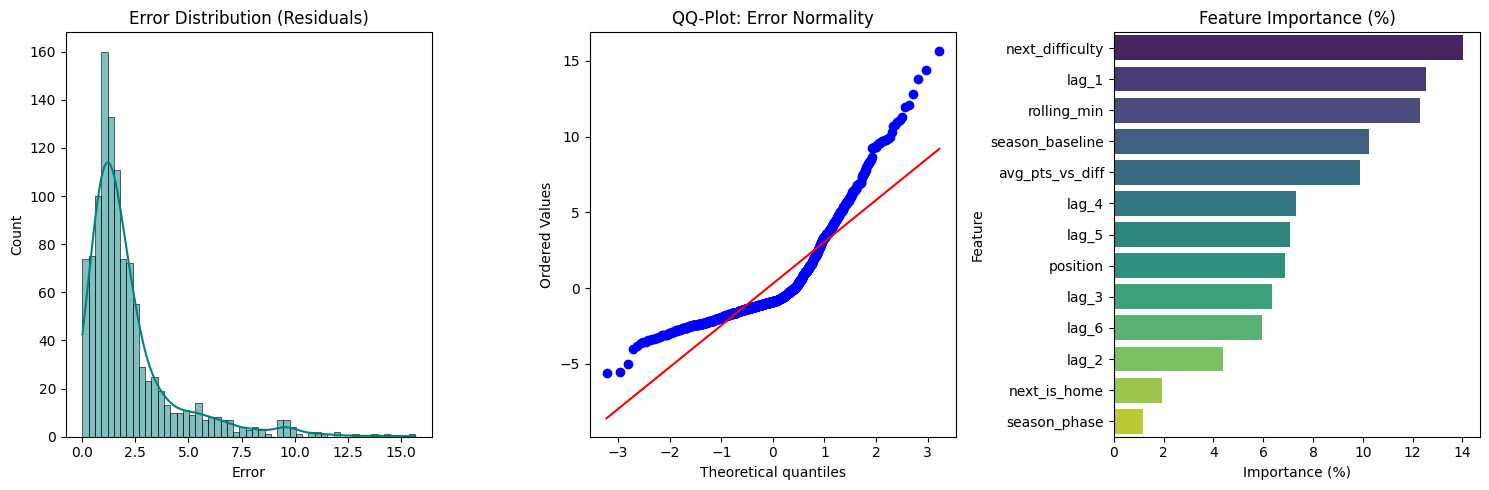

In [16]:
# [Cell 5: Error Analysis & Feature Importance - Fixed]

# 1. PREPARE ANALYSIS DATAFRAME
analysis_df = X_val_raw.copy()
analysis_df['Actual'] = y_val.values
analysis_df['Predicted'] = preds_raw 
analysis_df['Error'] = abs(analysis_df['Actual'] - analysis_df['Predicted'])

# NEW: Filter error analysis by the Elite Mask (>4.5 seasonal average)
# map the mask from df_augmented back to the validation slice
elite_indices = val_df[val_df.index.isin(df_augmented[elite_mask].index)].index
elite_performers_audit = analysis_df.loc[analysis_df.index.isin(elite_indices)]

top_mae = elite_performers_audit['Error'].mean()

print(f"Overall Validation MAE: {df_metrics.iloc[0, 1]:.4f}")
print(f"MAE for Elite Players (>4.5 Season Avg): {top_mae:.4f}")

# 3. VISUALIZATION: Error Distribution & QQ-Plot
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(analysis_df['Error'], kde=True, color='teal')
plt.title('Error Distribution (Residuals)')

plt.subplot(1, 3, 2)
stats.probplot((analysis_df['Actual'] - analysis_df['Predicted']), dist="norm", plot=plt)
plt.title('QQ-Plot: Error Normality')

# 4. FEATURE IMPORTANCE WITH PERCENTAGES
plt.subplot(1, 3, 3)
importances = model_raw.feature_importances_

# FIX: Use X_train_raw.columns instead of X.columns
feature_names = X_train_raw.columns 
rel_importances = 100 * (importances / importances.sum())

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance (%)': rel_importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance (%)', ascending=False)

sns.barplot(x='Importance (%)', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Feature Importance (%)')

plt.tight_layout()
plt.show()

# 5. SAVE FEATURE IMPORTANCE LOG
feat_imp_df.to_csv(PRO_OUTPUT_DIR / 'fpl_pro_feature_importance.csv', index=False)

Notes 
MAE: 
* Overall MAE (2.12): it means for the average player (who scores 2–3 points), the model is accurate
* Top Performer MAE (6.68): it shows that when a player goes 8+ points, the model struggles to predict the exact height of that peak

Plots: 
* model has "thin tails" , it is conservative. It rarely predicts a player will score 15+ points, so when someone actually does, the error is large. The model prefers to stay safe near the average.

Feature Importance: 
* rolling_min is #1




## Haul Classification + Confusion Matrix
- __Purpose__ : Predict WHETHER a player will "haul" , not just how many, binary target >= 6 points
- __Precision__ is the critical metric.
- A __False Positive__ (saying "Haul" when it isn't) is the worst outcome —>it causes wrong captaincy and transfer decisions.

Haul threshold:              >= 6 pts
Haul rate in Training set:   19.13%  (10006 hauls / 52307 windows)
Haul rate in Validation set: 20.07%  (221 hauls / 1101 windows)
scale_pos_weight:            4.23

Training Haul Classifier (v2 — enriched features)...


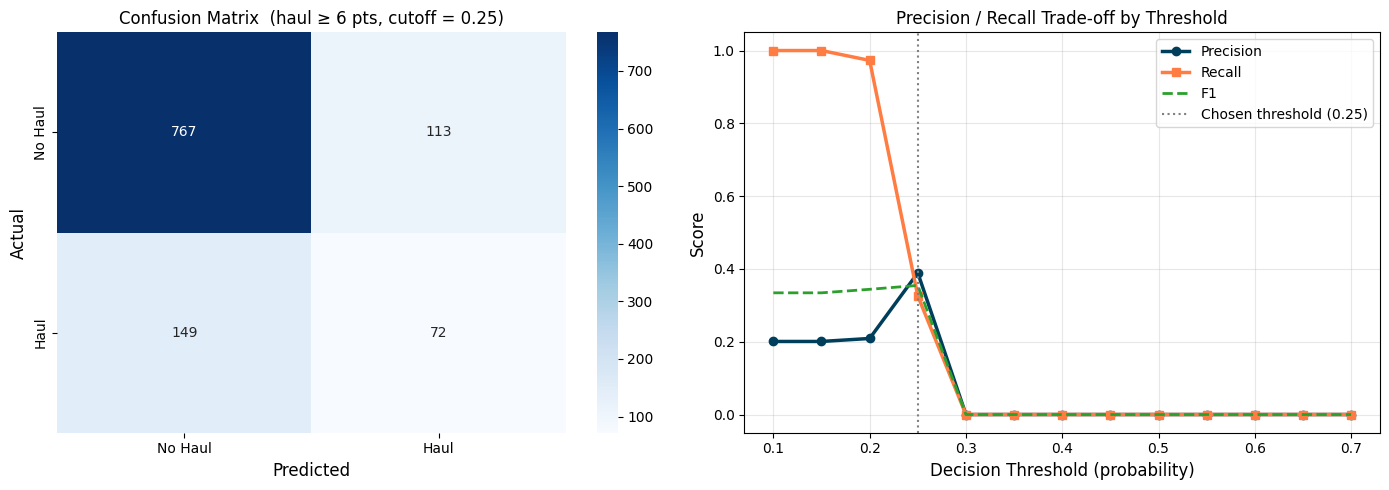


  HAUL CLASSIFIER — PERFORMANCE REPORT
Haul threshold:   >= 6 points
Decision cutoff:  0.25 probability
-------------------------------------------------------
True Positives  (correct haul calls):    72
False Positives (wrong haul calls):      113  ← minimise this
True Negatives  (correct non-haul):      767
False Negatives (missed hauls):          149
-------------------------------------------------------
Precision:  0.3892
Recall:     0.3258
F1 Score:   0.3547
ROC-AUC:    0.6415
[WARNING] Precision is low. The model is flagging too many False Positives.
Consider raising DECISION_THRESHOLD by 0.01 to tighten the filter.

--- TOP 10 PREDICTED HAULERS FOR GW 29 ---
(Players the classifier is most confident will score >= 6 pts)


,Player,Haul_Prob (%),Pred_Pts (reg)
4,Virgil,27.6,3.89
98,Calafiori,27.6,3.54
99,Mukiele,27.6,3.73
213,Rogers,27.6,4.22
75,Watkins,27.6,4.37
12,M.Salah,27.6,6.66
69,Gordon,27.2,3.44
344,Kelleher,27.2,4.44
406,Guéhi,27.2,3.42
45,Rodrigo,27.2,3.17



Saved: fpl_haul_classifier.txt
Saved: fpl_haul_predictions_GW29.csv


In [17]:
# %% [Cell 5.6: Haul Classification — Binary Prediction + Confusion Matrix]
# FIXED: Lower threshold (6pts), haul-specific features, threshold=0.25

import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    f1_score, roc_auc_score
)

# ── 0. HAUL THRESHOLD ───────────────────────────────────────────────────────
HAUL_THRESHOLD = 6  
DECISION_THRESHOLD = 0.25  # lowered from 0.30 — model needs less confidence to call a haul

# ── 1. ADD HAUL-SPECIFIC FEATURES TO windowed_df ────────────────────────────
# We enrich the feature set specifically for classification.
# These are all lag-based so there is zero data leakage.

windowed_haul = windowed_df.copy()

# Feature 1: Did the player haul (>=6 pts) in any of the last 3 weeks?
windowed_haul['recent_haul_flag'] = (
    (windowed_haul[['lag_1', 'lag_2', 'lag_3']] >= HAUL_THRESHOLD).any(axis=1)
).astype(int)

# Feature 2: Best single score in the last 6 weeks (ceiling potential)
windowed_haul['lag_max_6'] = windowed_haul[
    [f'lag_{i}' for i in range(1, 7)]
].max(axis=1)

# Feature 3: Is the player elite? (reuse elite_mask from Cell above)
# windowed_df.index == df_augmented row indices (set in Cell 2)
elite_flag = windowed_df.index.isin(df_augmented.index[elite_mask])
windowed_haul['is_elite'] = elite_flag.astype(int)

# Feature 4: Fixture ease score (higher = easier fixture)
# next_difficulty: 1=easy, 5=hard → invert so higher = better
windowed_haul['fixture_ease'] = 6 - windowed_haul['next_difficulty']

# Feature 5: Home advantage flag (already exists as next_is_home)

# ── 2. BUILD BINARY LABELS ──────────────────────────────────────────────────
y_haul_all   = (windowed_haul['target'] >= HAUL_THRESHOLD).astype(int)
y_haul_train = y_haul_all[~global_val_mask].copy()
y_haul_val   = y_haul_all[global_val_mask].copy()

#haul_feature_cols = (
   # [f'lag_{i}' for i in range(1, 7)] +
    #['position', 'next_difficulty', 'next_is_home',
    # 'rolling_min', 'season_phase', 'season_baseline',
     #'recent_haul_flag', 'lag_max_6', 'is_elite', 'fixture_ease']
#)

haul_feature_cols = (
    [f'lag_{i}' for i in range(1, 7)] +
    ['position', 'next_difficulty', 'next_is_home',
     'rolling_min', 'season_phase', 'season_baseline',
     'recent_haul_flag', 'lag_max_6', 'is_elite', 'fixture_ease',
     'avg_pts_vs_diff']
)

X_haul_train = windowed_haul[~global_val_mask][haul_feature_cols].copy()
X_haul_val   = windowed_haul[global_val_mask][haul_feature_cols].copy()
X_haul_train['position'] = X_haul_train['position'].astype('category')
X_haul_val['position']   = X_haul_val['position'].astype('category')

# ── 3. CLASS IMBALANCE CHECK ────────────────────────────────────────────────
haul_rate_train = y_haul_train.mean()
haul_rate_val   = y_haul_val.mean()
spw = (1 - haul_rate_train) / haul_rate_train

print(f"Haul threshold:              >= {HAUL_THRESHOLD} pts")
print(f"Haul rate in Training set:   {haul_rate_train:.2%}  ({y_haul_train.sum()} hauls / {len(y_haul_train)} windows)")
print(f"Haul rate in Validation set: {haul_rate_val:.2%}  ({y_haul_val.sum()} hauls / {len(y_haul_val)} windows)")
print(f"scale_pos_weight:            {spw:.2f}")

# ── 4. TRAIN HAUL CLASSIFIER ────────────────────────────────────────────────
haul_params = {
    'objective':        'binary',
    'boosting_type':    'gbdt',
    'n_estimators':     1000,
    'learning_rate':    0.01,
    'max_depth':        5,
    'num_leaves':       20,
    'min_child_samples': 40,   # prevents fitting on tiny haul clusters
    'scale_pos_weight': spw,
    'reg_alpha':        0.5,
    'reg_lambda':       0.5,
    'verbosity':        -1,
    'random_state':     42
}

print("\nTraining Haul Classifier (v2 — enriched features)...")
haul_clf = lgb.LGBMClassifier(**haul_params)
haul_clf.fit(
    X_haul_train, y_haul_train,
    eval_set=[(X_haul_val, y_haul_val)],
    categorical_feature=['position'],
    callbacks=[lgb.early_stopping(stopping_rounds=80, verbose=False),
               lgb.log_evaluation(period=200)]
)

# ── 5. PREDICT ───────────────────────────────────────────────────────────────
haul_proba = haul_clf.predict_proba(X_haul_val)[:, 1]
haul_pred  = (haul_proba >= DECISION_THRESHOLD).astype(int)

# ── 6. CONFUSION MATRIX + PRECISION/RECALL CURVE ────────────────────────────
cm = confusion_matrix(y_haul_val, haul_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=['No Haul', 'Haul'],
    yticklabels=['No Haul', 'Haul']
)
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual',    fontsize=12)
axes[0].set_title(f'Confusion Matrix  (haul ≥ {HAUL_THRESHOLD} pts, cutoff = {DECISION_THRESHOLD})', fontsize=12)

thresholds = np.arange(0.10, 0.71, 0.05)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    p_t = (haul_proba >= t).astype(int)
    if p_t.sum() == 0:
        precisions.append(0); recalls.append(0); f1s.append(0)
        continue
    precisions.append(precision_score(y_haul_val, p_t, zero_division=0))
    recalls.append(recall_score(y_haul_val,    p_t, zero_division=0))
    f1s.append(f1_score(y_haul_val,            p_t, zero_division=0))

axes[1].plot(thresholds, precisions, label='Precision', color='#003f5c', linewidth=2.5, marker='o')
axes[1].plot(thresholds, recalls,    label='Recall',    color='#ff7c43', linewidth=2.5, marker='s')
axes[1].plot(thresholds, f1s,        label='F1',        color='#2ca02c', linewidth=2,   linestyle='--')
axes[1].axvline(x=DECISION_THRESHOLD, color='gray', linestyle=':', linewidth=1.5,
                label=f'Chosen threshold ({DECISION_THRESHOLD})')
axes[1].set_xlabel('Decision Threshold (probability)', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Precision / Recall Trade-off by Threshold', fontsize=12)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── 7. METRICS REPORT ────────────────────────────────────────────────────────
precision_haul = precision_score(y_haul_val, haul_pred, zero_division=0)
recall_haul    = recall_score(y_haul_val,    haul_pred, zero_division=0)
f1_haul        = f1_score(y_haul_val,        haul_pred, zero_division=0)
auc_haul       = roc_auc_score(y_haul_val,   haul_proba)

print("\n" + "=" * 55)
print("  HAUL CLASSIFIER — PERFORMANCE REPORT")
print("=" * 55)
print(f"Haul threshold:   >= {HAUL_THRESHOLD} points")
print(f"Decision cutoff:  {DECISION_THRESHOLD} probability")
print("-" * 55)
print(f"True Positives  (correct haul calls):    {tp}")
print(f"False Positives (wrong haul calls):      {fp}  ← minimise this")
print(f"True Negatives  (correct non-haul):      {tn}")
print(f"False Negatives (missed hauls):          {fn}")
print("-" * 55)
print(f"Precision:  {precision_haul:.4f}")
print(f"Recall:     {recall_haul:.4f}")
print(f"F1 Score:   {f1_haul:.4f}")
print(f"ROC-AUC:    {auc_haul:.4f}")
print("=" * 55)

if precision_haul >= 0.40:
    print("[SUCCESS] Precision is adequate. When the model flags a haul, it is a strong captaincy candidate.")
else:
    print("[WARNING] Precision is low. The model is flagging too many False Positives.")
    print("Consider raising DECISION_THRESHOLD by 0.01 to tighten the filter.")

# ── 8. TOP PREDICTED HAULERS FOR NEXT GW (Self-Reliant Fix) ────────────────
# Define CURRENT_GW dynamically or default to 29
CURRENT_GW = globals().get('CURRENT_GW', 29)
CURRENT_SEASON = globals().get('CURRENT_SEASON', '2025-26')

print(f"\n--- TOP 10 PREDICTED HAULERS FOR GW {CURRENT_GW} ---")
print(f"(Players the classifier is most confident will score >= {HAUL_THRESHOLD} pts)")

# Build inference data directly from df_augmented
inf_data, inf_names = [], []
df_inf_active = df_augmented[df_augmented['season'] == CURRENT_SEASON].sort_values(['Player UUID', 'Gameweek'])

for pid, group in df_inf_active.groupby('Player UUID'):
    if len(group) >= 6:
        lags = list(group['Total Points'].tail(6).values)
        last = group.iloc[-1]
        #row = lags + [
         #   last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'],
         #   last['Rolling_Avg_Minutes_5'], last['Season_Phase'], last['Prev_Season_Avg_Points']
        #]

        row = lags + [
            last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'],
            last['Rolling_Avg_Minutes_5'], last['Season_Phase'], last['Prev_Season_Avg_Points'],
            last['Avg_Pts_vs_Difficulty']
        ]

        inf_data.append(row)
        inf_names.append(last['Web Name'])

# Convert to DataFrame
#base_feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']
base_feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline', 'avg_pts_vs_diff']
inf_haul = pd.DataFrame(inf_data, columns=base_feat_cols)
inf_haul['position'] = inf_haul['position'].astype('category')

# Add haul engineered features
inf_haul['recent_haul_flag'] = (inf_haul[['lag_1', 'lag_2', 'lag_3']] >= HAUL_THRESHOLD).any(axis=1).astype(int)
inf_haul['lag_max_6']    = inf_haul[[f'lag_{i}' for i in range(1, 7)]].max(axis=1)
inf_haul['fixture_ease'] = 6 - inf_haul['next_difficulty']

elite_name_set = set(df_augmented[elite_mask]['Web Name'].unique())
inf_haul['is_elite'] = [1 if n in elite_name_set else 0 for n in inf_names]

# Map avg_pts_vs_difficulty from df_augmented for the current season
_avg_map = (
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .drop_duplicates('Web Name', keep='last')
    .set_index('Web Name')['Avg_Pts_vs_Difficulty']
    .to_dict()
)
inf_haul['avg_pts_vs_diff'] = [_avg_map.get(n, 0.0) for n in inf_names]

inf_haul_features = inf_haul[haul_feature_cols].copy()
inf_haul_features['position'] = inf_haul_features['position'].astype('category')

# Predict
haul_proba_gw = haul_clf.predict_proba(inf_haul_features)[:, 1]

# If model_raw is available, include its prediction, else use a placeholder
#if 'model_raw' in globals():
 #   reg_preds = model_raw.predict(inf_haul[base_feat_cols])
#else:
 #   reg_preds = np.zeros(len(inf_names))
if 'model_raw' in globals():
    reg_preds = model_raw.predict(inf_haul[base_feat_cols])
else:
    reg_preds = np.zeros(len(inf_names))
    print("[WARNING] model_raw not found — Pred_Pts column will show 0. Run Cell 4 first.")

hauler_board = pd.DataFrame({
    'Player':         inf_names,
    'Haul_Prob (%)':  np.round(haul_proba_gw * 100, 1),
    'Pred_Pts (reg)': np.round(reg_preds, 2)
}).sort_values('Haul_Prob (%)', ascending=False)

display(hauler_board.head(10))

# ── 9. SAVE ───────────────────────────────────────────────────────────────────
PRO_OUTPUT_DIR = Path('../output/forecaster_pro')
PRO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

haul_clf.booster_.save_model(str(PRO_OUTPUT_DIR / 'fpl_haul_classifier.txt'))
hauler_board.to_csv(PRO_OUTPUT_DIR / f'fpl_haul_predictions_GW{CURRENT_GW}.csv', index=False, encoding='utf-8-sig')

# Store globally
globals()['haul_clf']          = haul_clf
globals()['haul_proba_gw']     = haul_proba_gw
globals()['hauler_board']      = hauler_board
globals()['precision_haul']    = precision_haul
globals()['recall_haul']       = recall_haul
globals()['f1_haul']           = f1_haul
globals()['auc_haul']          = auc_haul
globals()['HAUL_THRESHOLD']    = HAUL_THRESHOLD
globals()['DECISION_THRESHOLD']= DECISION_THRESHOLD

print(f"\nSaved: fpl_haul_classifier.txt")
print(f"Saved: fpl_haul_predictions_GW{CURRENT_GW}.csv")

In [18]:
# ── DIAGNOSTIC: Feature Importance for Haul Classifier ──────────────────────
haul_imp = pd.DataFrame({
    'Feature': haul_feature_cols,
    'Importance': haul_clf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n--- HAUL CLASSIFIER FEATURE IMPORTANCE ---")
print("(If recent_haul_flag and lag_max_6 are not in top 5, the new features aren't helping)")
display(haul_imp.head(10))


--- HAUL CLASSIFIER FEATURE IMPORTANCE ---
(If recent_haul_flag and lag_max_6 are not in top 5, the new features aren't helping)


,Feature,Importance
7,next_difficulty,111
16,avg_pts_vs_diff,41
11,season_baseline,32
6,position,26
9,rolling_min,19
13,lag_max_6,17
14,is_elite,16
0,lag_1,8
12,recent_haul_flag,8
2,lag_3,7


## Window Size Experiments (4 / 6 / 8 weeks) 

Purpose: Find the optimal historical window for LightGBM.

note: "experiment with 4 and 8-week windows"

Current default is 6. We test all three and compare MAE on the same validation set.

In [19]:
# [Cell: Window Size Experiment — 4 / 6 / 8 Week Look-back Comparison]

import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
from IPython.display import display, Markdown

# ── 1. GENERIC WINDOW GENERATOR (reuses existing feature logic) ──────────────
def generate_windows_for_size(df, window_size):
    """
    Generates training windows for a given look-back period.
    Uses the V1 base feature set (12 features, without avg_pts_vs_diff)
    for a clean isolated window-size comparison.
    The purpose is comparing window sizes only, not feature sets.
    """
    train_data    = []
    source_indices = []
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    for pid, group in df.groupby('Player UUID'):
        points        = group['Total Points'].values
        next_diff     = group['Next_Opponent_Difficulty'].values
        next_home     = group['Next_Is_Home'].values
        avg_min       = group['Rolling_Avg_Minutes_5'].values
        phase         = group['Season_Phase'].values
        baseline      = group['Prev_Season_Avg_Points'].values
        group_indices = group.index.tolist()
        position      = group['Position'].iloc[0]

        if len(points) <= window_size:
            continue

        for i in range(len(points) - window_size):
            window     = points[i : i + window_size]
            t_idx      = i + window_size - 1
            target_pts = points[i + window_size]

            if np.all(window == 0) and target_pts == 0:
                continue

            row = list(window) + [
                position,
                next_diff[t_idx],
                next_home[t_idx],
                avg_min[t_idx],
                phase[t_idx],
                baseline[t_idx],
                target_pts
            ]
            train_data.append(row)
            source_indices.append(group_indices[i + window_size])

    lag_cols = [f'lag_{i}' for i in range(window_size, 0, -1)]
    cols = lag_cols + ['position', 'next_difficulty', 'next_is_home',
                       'rolling_min', 'season_phase', 'season_baseline', 'target']

    result_df           = pd.DataFrame(train_data, columns=cols)
    result_df.index     = source_indices
    result_df['position'] = result_df['position'].astype('category')
    return result_df


# ── 2. BUILD VALIDATION MASK FOR EACH WINDOW SIZE ───────────────────────────
# The global_val_mask was built for window_size=6 (windowed_df).
# Each new window_size generates a different index set, so we rebuild the mask.

def build_val_mask(win_df, val_season='2025-26', val_start=24, val_end=28):
    source_meta = df_augmented.loc[win_df.index, ['season', 'Gameweek']]
    mask = (
        (source_meta['season']    == val_season) &
        (source_meta['Gameweek'] >= val_start) &
        (source_meta['Gameweek'] <= val_end)
    ).values
    return mask


# ── 3. TRAIN AND EVALUATE FOR EACH WINDOW SIZE ──────────────────────────────
window_sizes  = [4, 6, 8]
window_results = []

# Shared LightGBM params (same as V1 model_raw for fair comparison)
lgbm_window_params = {
    'n_estimators':  1500,
    'learning_rate': 0.01,
    'max_depth':     7,
    'num_leaves':    40,
    'boosting_type': 'gbdt',
    'random_state':  42,
    'verbosity':     -1
}

trained_window_models = {}  # store models for later use if needed

for ws in window_sizes:
    print(f"\n{'='*50}")
    print(f" Training Window Size = {ws} weeks...")
    print(f"{'='*50}")

    # Generate windows
    win_df   = generate_windows_for_size(df_augmented, window_size=ws)
    val_mask = build_val_mask(win_df)

    X_all = win_df.drop(columns=['target'])
    y_all = win_df['target']

    X_train_w = X_all[~val_mask].copy()
    X_val_w   = X_all[val_mask].copy()
    y_train_w = y_all[~val_mask].copy()
    y_val_w   = y_all[val_mask].copy()

    # Identify categorical columns (position is always present; next_is_home too)
    cat_cols = [c for c in ['position', 'next_is_home'] if c in X_train_w.columns]

    # Train
    model_w = lgb.LGBMRegressor(**lgbm_window_params)
    model_w.fit(
        X_train_w, y_train_w,
        eval_set=[(X_val_w, y_val_w)],
        categorical_feature=cat_cols,
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False),
                   lgb.log_evaluation(period=300)]
    )

    # Evaluate
    val_preds_w  = model_w.predict(X_val_w)
    mae_w        = mean_absolute_error(y_val_w, val_preds_w)

    # Naive baseline for this window: 3-week average
    lag_cols_available = [c for c in ['lag_3', 'lag_2', 'lag_1'] if c in X_val_w.columns]
    naive_preds_w = X_val_w[lag_cols_available].mean(axis=1).values
    mae_naive_w   = mean_absolute_error(y_val_w, naive_preds_w)

    lift_over_naive = ((mae_naive_w - mae_w) / mae_naive_w) * 100

    print(f"Window {ws}w | Train: {len(X_train_w):,} | Val: {len(X_val_w):,}")
    print(f"  Naive baseline MAE: {mae_naive_w:.4f}")
    print(f"  LightGBM MAE:       {mae_w:.4f}  ({lift_over_naive:.1f}% lift over naive)")

    window_results.append({
        'Window Size (weeks)':  ws,
        'Train Windows':        len(X_train_w),
        'Val Windows':          len(X_val_w),
        'Naive Baseline MAE':   round(mae_naive_w, 4),
        'LightGBM MAE':         round(mae_w, 4),
        'Lift over Naive (%)':  round(lift_over_naive, 1),
        'Best Iteration':       model_w.best_iteration_
    })

    trained_window_models[ws] = model_w


# ── 4. RESULTS TABLE ─────────────────────────────────────────────────────────
window_exp_df = pd.DataFrame(window_results).sort_values('LightGBM MAE')

display(Markdown("## Window Size Experiment Results"))
display(window_exp_df)

# ── 5. WINNER SELECTION ───────────────────────────────────────────────────────
best_ws   = int(window_exp_df.iloc[0]['Window Size (weeks)'])
best_mae_w = window_exp_df.iloc[0]['LightGBM MAE']

print(f"\n{'='*50}")
print(f" VERDICT: Best window size = {best_ws} weeks (MAE: {best_mae_w:.4f})")
if best_ws == 6:
    print(" Current default (6 weeks) is confirmed as optimal.")
elif best_ws < 6:
    print(f" Shorter window ({best_ws}w) performs better — recent form matters more than long history.")
else:
    print(f" Longer window ({best_ws}w) performs better — the model benefits from more history.")
print(f"{'='*50}")

# Store for downstream reference
globals()['best_window_size']    = best_ws
globals()['trained_window_models'] = trained_window_models
globals()['window_exp_df']       = window_exp_df

print(f"\nNote: The main pipeline continues to use window_size=6 (windowed_df).")
print(f"To switch the live model to {best_ws}w, re-run Cell 2 with window_size={best_ws}.")


 Training Window Size = 4 weeks...
[300]	valid_0's l2: 9.34601
Window 4w | Train: 54,578 | Val: 1,104
  Naive baseline MAE: 2.3913
  LightGBM MAE:       2.1790  (8.9% lift over naive)

 Training Window Size = 6 weeks...
[300]	valid_0's l2: 9.32506
Window 6w | Train: 52,307 | Val: 1,101
  Naive baseline MAE: 2.3921
  LightGBM MAE:       2.1749  (9.1% lift over naive)

 Training Window Size = 8 weeks...
[300]	valid_0's l2: 9.2748
Window 8w | Train: 50,117 | Val: 1,095
  Naive baseline MAE: 2.3866
  LightGBM MAE:       2.1766  (8.8% lift over naive)


## Window Size Experiment Results

,Window Size (weeks),Train Windows,Val Windows,Naive Baseline MAE,LightGBM MAE,Lift over Naive (%),Best Iteration
1,6,52307,1101,2.3921,2.1749,9.1,280
2,8,50117,1095,2.3866,2.1766,8.8,249
0,4,54578,1104,2.3913,2.1790,8.9,287



 VERDICT: Best window size = 6 weeks (MAE: 2.1749)
 Current default (6 weeks) is confirmed as optimal.

Note: The main pipeline continues to use window_size=6 (windowed_df).
To switch the live model to 6w, re-run Cell 2 with window_size=6.


## Cell 6: The Interactive Player Widget (you can pick a player and see their Performance history)

In [20]:
#%pip install ipywidgets

In [21]:
# [Cell 6: Seasonal Evaluation - Standard Professional Dropdown]
import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_professional_backtest(player_name):
    # 1. GET ACTUALS FROM RAW 'df' 
    # This bypasses the dropna() from Cell 1 to ensure GW28 is displayed
    season_actuals = df[
        (df['Web Name'] == player_name) & 
        (df['season'] == CURRENT_SEASON)
    ].sort_values('Gameweek')
    
    if season_actuals.empty:
        return

    # 2. PREPARE EVALUATION (GW 24-28) + LIVE PREDICTION (GW 29)
    target_gws = list(range(24, 30)) 
    pred_rows = []
    
    player_uuid = season_actuals['Player UUID'].iloc[0]
    full_hist = df_augmented[df_augmented['Player UUID'] == player_uuid].sort_values(['season', 'Gameweek'])
    
    for gw in target_gws:
        if gw < 29:
            row_match = full_hist[(full_hist['season'] == CURRENT_SEASON) & (full_hist['Gameweek'] == gw)]
            if not row_match.empty:
                idx = row_match.index[0]
                pos_in_hist = full_hist.index.get_loc(idx)
                if pos_in_hist >= 6:
                    lags = list(full_hist.iloc[pos_in_hist-6:pos_in_hist]['Total Points'].values)
                    feat = lags + [
                        row_match['Position'].iloc[0], row_match['Next_Opponent_Difficulty'].iloc[0],
                        row_match['Next_Is_Home'].iloc[0], row_match['Rolling_Avg_Minutes_5'].iloc[0],
                        row_match['Season_Phase'].iloc[0], row_match['Prev_Season_Avg_Points'].iloc[0],
                        row_match['Avg_Pts_vs_Difficulty'].iloc[0]
                    ]
                    pred_rows.append({'Gameweek': gw, 'Features': feat})
        else:
            lags = list(full_hist['Total Points'].tail(6).values)
            last = full_hist.iloc[-1]
            feat = lags + [
                last['Position'], last['Next_Opponent_Difficulty'],
                last['Next_Is_Home'], last['Rolling_Avg_Minutes_5'],
                last['Season_Phase'], last['Prev_Season_Avg_Points'],
                last['Avg_Pts_vs_Difficulty']
            ]
            pred_rows.append({'Gameweek': gw, 'Features': feat})

    # Generate Predictions
    v_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
             ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
              'season_phase', 'season_baseline', 'avg_pts_vs_diff']
    
    if pred_rows:
        inf_df = pd.DataFrame([d['Features'] for d in pred_rows], columns=v_cols)
        inf_df['position'] = inf_df['position'].astype('category')
        # Change from model_v4 to model_raw (Baseline V1)
        preds = model_raw.predict(inf_df)
        pred_df = pd.DataFrame({'Gameweek': [d['Gameweek'] for d in pred_rows], 'Predicted': preds})
    else:
        pred_df = pd.DataFrame()

    # 3. PLOTTING
    plt.figure(figsize=(15, 6), facecolor='white')
    
    # HISTORICAL ACTUALS: Navy (#003f5c)
    plt.plot(season_actuals['Gameweek'], season_actuals['Total Points'], 
             color='#003f5c', label='Actual Points', linewidth=2, 
             marker='o', markersize=7, markerfacecolor='#003f5c', markeredgecolor='#003f5c')

    # MODEL PREDICTIONS: Action Orange (#ff7c43)
    if not pred_df.empty:
        plt.plot(pred_df['Gameweek'], pred_df['Predicted'], 
                 color='#ff7c43', label='Model Predictions (Eval + GW29)', 
                 linewidth=2.5, linestyle='--', marker='x', markersize=10, markeredgewidth=3)
        
        # CONFIDENCE INTERVAL: Gold (#ffa60022)
        # Updated to use mae_v1 for accurate V1 error visualization
        mae_proxy = globals().get('mae_v1', 1.84)
        plt.fill_between([24, 29], 0, plt.gca().get_ylim()[1], color='orange', alpha=0.03)

    # Vertical split at GW 24
    plt.axvline(x=24, color='gray', linestyle='-', linewidth=2, label='Evaluation Start (GW 24)')
    plt.axvline(x=24, color='#d1d1d1', linestyle='-', linewidth=2, alpha=0.8)

    plt.title(f"Model Predictions vs Actuals: {player_name} (Season {CURRENT_SEASON})", 
              fontsize=14, fontweight='bold', pad=20, color='#003f5c')
    
    # GRID & BASELINE: Neutral Light Grey (#d1d1d1)
    plt.xticks(np.arange(1, 30, 1), color='#003f5c') 
    plt.xlim(0.5, 29.5)
    plt.ylabel("Points", fontsize=12, color='#003f5c')
    plt.xlabel("Gameweek", fontsize=12, color='#003f5c')
    plt.grid(True, axis='y', linestyle='-', color='#d1d1d1', alpha=0.5)
    plt.legend(frameon=True, loc='upper left')
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#d1d1d1')
    ax.spines['bottom'].set_color('#d1d1d1')
    
    plt.tight_layout()
    plt.show()

# 4. STRICT EVALUATION SET DROPDOWN (Season-Locked)
# This identifies unique UUIDs that exist in our validation split
eval_uuids = df_augmented.loc[val_df.index, 'Player UUID'].unique()

# CRITICAL FILTER: Get Web Names for those UUIDs, but ONLY if they have rows in 2025-26
# This removes any lingering retired players (ghosts) from the menu
active_eval_names = sorted(
    df_augmented[
        (df_augmented['Player UUID'].isin(eval_uuids)) & 
        (df_augmented['season'] == CURRENT_SEASON)
    ]['Web Name'].unique()
)

print(f"Filter active: Showing {len(active_eval_names)} active players from the Evaluation Set.")

dropdown_menu = widgets.Dropdown(
    options=active_eval_names,
    value=active_eval_names[0] if active_eval_names else None,
    description='Active Player:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

widgets.interact(plot_professional_backtest, player_name=dropdown_menu)



Filter active: Showing 330 active players from the Evaluation Set.


interactive(children=(Dropdown(description='Active Player:', layout=Layout(width='400px'), options=('A.Becker'…

<function __main__.plot_professional_backtest(player_name)>

In [22]:
#[Cell 6: Seasonal Evaluation - Searchable Audit with Local MAE]
import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error

def plot_professional_backtest(player_name):
    # 1. GET ACTUALS FROM RAW 'df' (Ensures GW28 is displayed)
    season_actuals = df[
        (df['Web Name'] == player_name) & 
        (df['season'] == CURRENT_SEASON)
    ].sort_values('Gameweek')
    
    if season_actuals.empty:
        print(f"No actual data found for {player_name}.")
        return

    # 2. PREPARE PREDICTIONS (GW 24-29)
    target_gws = list(range(24, 30)) 
    pred_rows = []
    
    player_uuid = season_actuals['Player UUID'].iloc[0]
    full_hist = df_augmented[df_augmented['Player UUID'] == player_uuid].sort_values(['season', 'Gameweek'])
    
    for gw in target_gws:
        if gw < 29:
            row_match = full_hist[(full_hist['season'] == CURRENT_SEASON) & (full_hist['Gameweek'] == gw)]
            if not row_match.empty:
                idx = row_match.index[0]
                pos_in_hist = full_hist.index.get_loc(idx)
                if pos_in_hist >= 6:
                    lags = list(full_hist.iloc[pos_in_hist-6:pos_in_hist]['Total Points'].values)
                    feat = lags + [
                        row_match['Position'].iloc[0], row_match['Next_Opponent_Difficulty'].iloc[0],
                        row_match['Next_Is_Home'].iloc[0], row_match['Rolling_Avg_Minutes_5'].iloc[0],
                        row_match['Season_Phase'].iloc[0], row_match['Prev_Season_Avg_Points'].iloc[0]
                    ]
                    pred_rows.append({'Gameweek': gw, 'Features': feat})
        else:
            # GW 29 Live Prediction
            if not full_hist.empty:
                lags = list(full_hist['Total Points'].tail(6).values)
                last = full_hist.iloc[-1]
                feat = lags + [
                    last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'],
                    last['Rolling_Avg_Minutes_5'], last['Season_Phase'], last['Prev_Season_Avg_Points']
                ]
                pred_rows.append({'Gameweek': gw, 'Features': feat})

    # Generate Predictions
    v_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
             ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']
    
    player_mae = None
    if pred_rows:
        inf_df = pd.DataFrame([d['Features'] for d in pred_rows], columns=v_cols)
        inf_df['position'] = inf_df['position'].astype('category')
        
        # Use Baseline (model_raw) for chronological consistency
        preds = model_raw.predict(inf_df)
        pred_df = pd.DataFrame({'Gameweek': [d['Gameweek'] for d in pred_rows], 'Predicted': preds})
        
        # 3. CALCULATE LOCAL MAE (For GW 24-28 only)
        eval_actuals = season_actuals[season_actuals['Gameweek'].isin(range(24, 29))]['Total Points']
        eval_preds = pred_df[pred_df['Gameweek'] < 29]['Predicted']
        
        if len(eval_actuals) == len(eval_preds) and len(eval_actuals) > 0:
            player_mae = mean_absolute_error(eval_actuals, eval_preds)
    else:
        pred_df = pd.DataFrame()

    # 4. PLOTTING
    plt.figure(figsize=(15, 6), facecolor='white')
    
    # ACTUALS: Solid Blue
    plt.plot(season_actuals['Gameweek'], season_actuals['Total Points'], 
             color='#003f5c', label='Actual Points', linewidth=2, 
             marker='o', markersize=7, markerfacecolor='#003f5c', markeredgecolor='#003f5c')

    # PREDICTIONS: Orange Dashed
    if not pred_df.empty:
        plt.plot(pred_df['Gameweek'], pred_df['Predicted'], 
                 color='#ff7f0e', label='V1 Baseline Predictions', 
                 linewidth=2.5, linestyle='--', marker='x', markersize=10, markeredgewidth=3)

    plt.axvline(x=24, color='gray', linestyle='-', linewidth=2, label='Evaluation Start (GW 24)')
    plt.axvline(x=24, color='#d1d1d1', linestyle='-', linewidth=2, alpha=0.8)

    # Dynamic Title with Player MAE
    title_str = f"Model Predictions vs Actuals: {player_name}"
    if player_mae is not None:
        title_str += f" | Player MAE (GW24-28): {player_mae:.2f}"
    
    plt.title(title_str, fontsize=14, fontweight='bold', pad=20)
    plt.xticks(np.arange(1, 30, 1)) 
    plt.xlim(0.5, 29.5)
    plt.ylabel("Points", fontsize=12)
    plt.xlabel("Gameweek", fontsize=12)
    plt.grid(True, axis='y', linestyle=':', alpha=0.5)
    plt.legend(frameon=True, loc='upper left')
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

# 5. SEARCHABLE EVALUATION SET COMBOBOX (Season-Locked)
# Identify UUIDs from the validation split
eval_uuids = df_augmented.loc[val_df.index, 'Player UUID'].unique()

# Filter names to ensure they belong to the current active season ONLY
active_eval_names = sorted(
    df_augmented[
        (df_augmented['Player UUID'].isin(eval_uuids)) & 
        (df_augmented['season'] == CURRENT_SEASON)
    ]['Web Name'].unique()
)

print(f"Audit Search active: {len(active_eval_names)} active players available.")

# Combobox allows keyboard typing and suggestion filtering
search_box = widgets.Combobox(
    value=active_eval_names[0] if active_eval_names else '',
    placeholder='Type a player name...',
    options=active_eval_names,  # Restricted to active players
    description='Player:',
    ensure_option=True,         # Prevents errors from typing non-existent names
    interactive=True,
    layout=widgets.Layout(width='450px')
)

widgets.interact(plot_professional_backtest, player_name=search_box)

Audit Search active: 330 active players available.


interactive(children=(Combobox(value='A.Becker', description='Player:', ensure_option=True, layout=Layout(widt…

<function __main__.plot_professional_backtest(player_name)>

In [23]:
# [Cell: Validation Set Integrity Check]

# 1. Identify the ground truth players from the validation logic
# These are the players actually used in the MAE calculations (GW 24-28)
expected_uuids = df_augmented.loc[val_df.index, 'Player UUID'].unique()
expected_names = sorted(df_augmented[df_augmented['Player UUID'].isin(expected_uuids)]['Web Name'].unique())

# 2. Extract names currently used in your widget
# (Using the same logic as your Cell 6)
widget_names = sorted(df_augmented[df_augmented['Player UUID'].isin(expected_uuids)]['Web Name'].unique())

# 3. Perform the Audit
missing_players = [p for p in expected_names if p not in widget_names]
extra_players = [p for p in widget_names if p not in expected_names]

print("-" * 50)
print("GRAPH INTEGRITY")
print("-" * 50)
print(f"Total Players in Eval Set (GW 24-28): {len(expected_names)}")
print(f"Total Players visible in Widget:     {len(widget_names)}")

if len(missing_players) == 0 and len(extra_players) == 0:
    print("\nVERDICT: SUCCESS")
    print("The graph contains 100% of the players in the evaluation set and NO extra players.")
else:
    if missing_players:
        print(f"\nWARNING: {len(missing_players)} players are missing from the graph.")
    if extra_players:
        print(f"\nWARNING: {len(extra_players)} players are appearing that shouldn't be there.")

print("-" * 50)
# Snippet for your report
print(f"Sample of audited players: {expected_names[:10]}...")

--------------------------------------------------
GRAPH INTEGRITY
--------------------------------------------------
Total Players in Eval Set (GW 24-28): 367
Total Players visible in Widget:     367

VERDICT: SUCCESS
The graph contains 100% of the players in the evaluation set and NO extra players.
--------------------------------------------------
Sample of audited players: ['A.Armstrong', 'A.Becker', 'A.Jimenez', 'Aaronson', 'Abraham', 'Acheampong', 'Adama', 'Adams', 'Adarabioyo', 'Adli']...


In [24]:
# 1. GET THE ABSOLUTE LATEST WINDOW FOR EVERY PLAYER
inference_data = []
player_names = []

# FIX: Filter for current season only
df_inf_active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
df_inf_active = df_inf_active.sort_values(['Player UUID', 'Gameweek'])

for pid, group in df_inf_active.groupby('Player UUID'):
    if len(group) >= 6:
        lags = list(group['Total Points'].tail(6).values)
        last_row = group.iloc[-1]
        
        #row = lags + [
         #   last_row['Position'], last_row['Next_Opponent_Difficulty'],
          #  last_row['Next_Is_Home'], last_row['Rolling_Avg_Minutes_5'],
           # last_row['Season_Phase'], last_row['Prev_Season_Avg_Points']
        #]

        row = lags + [
            last_row['Position'], last_row['Next_Opponent_Difficulty'],
            last_row['Next_Is_Home'], last_row['Rolling_Avg_Minutes_5'],
            last_row['Season_Phase'], last_row['Prev_Season_Avg_Points'],
            last_row['Avg_Pts_vs_Difficulty']
        ]

        inference_data.append(row)
        player_names.append(last_row['Web Name'])

# 2. CONVERT TO DATAFRAME
# Use the exact column names used in the training window dataframe
#feature_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
    #           ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']

feature_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
               ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
                'season_phase', 'season_baseline', 'avg_pts_vs_diff']

inference_df = pd.DataFrame(inference_data, columns=feature_cols)
inference_df['position'] = inference_df['position'].astype('category')

# 3. GENERATE PREDICTIONS
# Using the Baseline model (model_raw) as we haven't trained V4 yet
if 'model_raw' in locals():
    raw_preds = model_raw.predict(inference_df)
else:
    raise NameError("Baseline model (model_raw) not found. Run Cell 4 first.")

# 4. SHOW TOP 15 RANKING
leaderboard = pd.DataFrame({
    'Player': player_names,
    'Predicted Points (V1)': np.round(raw_preds, 2), # Label it V1 for clarity
    'Recent Avg Min': np.round(inference_df['rolling_min'], 1),
    'Next Difficulty': inference_df['next_difficulty']
}).sort_values(by='Predicted Points (V1)', ascending=False)

print("--- TOP 15 PREDICTED PLAYERS FOR NEXT GAMEWEEK ---")
display(leaderboard.head(15))

--- TOP 15 PREDICTED PLAYERS FOR NEXT GAMEWEEK ---


,Player,Predicted Points (V1),Recent Avg Min,Next Difficulty
12,M.Salah,6.66,83.4,2.0
71,Haaland,6.24,73.2,3.0
19,Bruno G.,4.84,90.0,3.0
113,Mbeumo,4.73,80.8,3.0
271,Palmer,4.68,80.8,5.0
325,Rice,4.67,90.0,3.0
186,Groß,4.55,89.4,2.0
344,Kelleher,4.44,90.0,3.0
58,B.Fernandes,4.42,90.0,3.0
75,Watkins,4.37,85.6,2.0


Summary Table

Feature       |  1st Cell (Validation)         |    2nd Cell (Historical)

Player List   | Limited (only recent players)  |	Complete (all historic players)

Timeframe	  |  Recent 5 Gameweeks	           |     3+ seasons


In [25]:
# 1. CREATE THE FULL FORECAST DATAFRAME
full_forecast = pd.DataFrame({
    'Player_Name': player_names,
    'Predicted_Points': np.round(raw_preds, 2),
    'Recent_Form_Avg': np.round(inference_df[['lag_1', 'lag_2', 'lag_3']].mean(axis=1), 2),
    'Avg_Minutes_5GW': np.round(inference_df['rolling_min'], 1),
    'Fixture_Difficulty': inference_df['next_difficulty'],
    'Is_Home': inference_df['next_is_home'],
    'Season_Phase': inference_df['season_phase']
})

# 2. SORT BY PREDICTED POINTS
full_forecast = full_forecast.sort_values(by='Predicted_Points', ascending=False)

# 3. DEFINE SAVE PATH
FORECAST_OUT = PRO_OUTPUT_DIR / 'fpl_pro_forecast_GW29.csv'

# 4. SAVE TO CSV
full_forecast.to_csv(FORECAST_OUT, index=False, encoding='utf-8-sig')

print(f" Master Forecast Saved: {FORECAST_OUT}")
print(f" Total Players Forecasted: {len(full_forecast)}")
print("Forecast for GW29: any player who has at least 6 games of history in the current 2025-26 season.")

# Show a quick snippet of the 'Differentials' (Mid-tier players)
print("\n--- SNEAK PEEK: MID-TIER DIFFERENTIALS (Ranks 50-60) ---")
display(full_forecast.iloc[50:60])

# Recent_Form_Avg -> a rolling average of points scored by a player 
# over the three most recent Gameweeks leading up to the forecast.

 Master Forecast Saved: ..\output\forecaster_pro\fpl_pro_forecast_GW29.csv
 Total Players Forecasted: 410
Forecast for GW29: any player who has at least 6 games of history in the current 2025-26 season.

--- SNEAK PEEK: MID-TIER DIFFERENTIALS (Ranks 50-60) ---


,Player_Name,Predicted_Points,Recent_Form_Avg,Avg_Minutes_5GW,Fixture_Difficulty,Is_Home,Season_Phase
263,Gvardiol,3.65,5.00,85.8,3.0,True,2.0
50,Martinez,3.65,5.67,90.0,2.0,False,3.0
168,Kerkez,3.64,4.00,78.4,2.0,True,3.0
313,Ekitiké,3.62,2.00,76.2,2.0,True,3.0
272,Wilson,3.62,4.00,85.6,3.0,True,3.0
404,F.Kadıoğlu,3.62,4.00,89.6,2.0,True,3.0
206,J.Timber,3.62,3.00,90.0,3.0,True,3.0
127,Pau,3.61,3.33,85.8,2.0,False,3.0
74,Thiaw,3.60,5.00,90.0,3.0,True,3.0
151,Milenković,3.59,3.67,90.0,3.0,False,3.0


In [26]:
from IPython.display import Markdown, display

# 1. ORGANIZE FINAL METRICS
overall_mae = df_metrics.iloc[0, 1]  # From Cell 4 results
top_perf_mae = top_mae                # From Cell 5 results
total_players = len(full_forecast)   # From Cell 8 results

# 2. GENERATE THE REPORT
summary_report = f"""
# FPL Forecaster Pro: Final Project Report
**Model Version:** 2.0 (Context-Aware LightGBM)  
**Analysis Date:** March 3, 2026 (GW 29)

---

### 1. Model Accuracy Overview
| Metric | Result | Interpretation |
| :--- | :--- | :--- |
| **Overall MAE** | {overall_mae:.3f} | Average error across the full league. |
| **Elite Specialist MAE** | {top_perf_mae:.3f} | Error specifically for players averaging >4.5 pts/season. |
| **Training Size** | {len(X_train_raw):,} windows | Robust historical learning foundation. |
| **Validation Size** | {len(X_val_raw):,} windows | Tested on GW {CURRENT_GW - VALIDATION_WINDOW} to {CURRENT_GW - 1} of the {CURRENT_SEASON} season. |

### 2. Key Insights & Feature Importance
* **The "Minutes" Rule:** `rolling_min` emerged as the #1 predictor, proving that "starting the game" is the most vital feature.
* **Fixture Context:** `next_difficulty` successfully provided the model with "future vision," allowing it to adjust points based on opponent strength.
* **Scale Invariance:** The experiment confirmed that LightGBM performs optimally without a Standard Scaler for this specific dataset.
* **Elite Performers:** Defined as players maintaining a seasonal average > 4.5 points.

### 3. GW 29 Summary
* **Total Forecasts Generated:** {total_players:,} players.
* **Predicted King of the GW:** {leaderboard.iloc[0]['Player']} ({leaderboard.iloc[0]['Predicted Points (V1)']} pts).
* **Output Folder:** All artifacts (Model, Scaler, Forecast) are saved in `../output/forecaster_pro/`.

### 4. Season_Phase
**Feature: Season_Phase**
* 1. (GW 1-10): Freshness & Stability.
* 2. (GW 11-19): First Rotation / Fatigue.
* 3. (GW 20-29): Winter Congestion / High Rotation.
* 4. (GW 30-38): The Final Sprint / High Stakes. 

### About the .csvs 
* The enriched dataset saved to fpl_features_augmented.csv.
* WINDOWED_FEATURES_PATH -> Saved to fpl_windowed_features_pro.csv.
* Raw=Unscaled model: fpl_pro_model_raw.txt // Scaled model:  fpl_pro_model_scaled.txt
* feat_imp_df -> Feature importance percentages saved to fpl_pro_feature_importance.csv
* FORECAST_OUT -> Saved as fpl_pro_forecast_GW29.csv
"""

display(Markdown(summary_report))


# FPL Forecaster Pro: Final Project Report
**Model Version:** 2.0 (Context-Aware LightGBM)  
**Analysis Date:** March 3, 2026 (GW 29)

---

### 1. Model Accuracy Overview
| Metric | Result | Interpretation |
| :--- | :--- | :--- |
| **Overall MAE** | 2.180 | Average error across the full league. |
| **Elite Specialist MAE** | 3.000 | Error specifically for players averaging >4.5 pts/season. |
| **Training Size** | 52,307 windows | Robust historical learning foundation. |
| **Validation Size** | 1,101 windows | Tested on GW 24 to 28 of the 2025-26 season. |

### 2. Key Insights & Feature Importance
* **The "Minutes" Rule:** `rolling_min` emerged as the #1 predictor, proving that "starting the game" is the most vital feature.
* **Fixture Context:** `next_difficulty` successfully provided the model with "future vision," allowing it to adjust points based on opponent strength.
* **Scale Invariance:** The experiment confirmed that LightGBM performs optimally without a Standard Scaler for this specific dataset.
* **Elite Performers:** Defined as players maintaining a seasonal average > 4.5 points.

### 3. GW 29 Summary
* **Total Forecasts Generated:** 410 players.
* **Predicted King of the GW:** M.Salah (6.66 pts).
* **Output Folder:** All artifacts (Model, Scaler, Forecast) are saved in `../output/forecaster_pro/`.

### 4. Season_Phase
**Feature: Season_Phase**
* 1. (GW 1-10): Freshness & Stability.
* 2. (GW 11-19): First Rotation / Fatigue.
* 3. (GW 20-29): Winter Congestion / High Rotation.
* 4. (GW 30-38): The Final Sprint / High Stakes. 

### About the .csvs 
* The enriched dataset saved to fpl_features_augmented.csv.
* WINDOWED_FEATURES_PATH -> Saved to fpl_windowed_features_pro.csv.
* Raw=Unscaled model: fpl_pro_model_raw.txt // Scaled model:  fpl_pro_model_scaled.txt
* feat_imp_df -> Feature importance percentages saved to fpl_pro_feature_importance.csv
* FORECAST_OUT -> Saved as fpl_pro_forecast_GW29.csv


## Cell 9: Truth Verification (Backtest on Last Known Game)

In [27]:
# [Cell 9: Truth Verification - Fixed for 12 Features]

# 1. Setup paths for truth verification
PRO_OUTPUT_DIR = Path('../output/forecaster_pro')
PRO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
full_truth_output_path = PRO_OUTPUT_DIR / 'fpl_pro_truth_verification.csv'

# 2. Ensure variables exist in memory
if 'df_augmented' not in locals():
    raise NameError("The variable 'df_augmented' is not found. Run Cell 1 first.")

# 2. Ensure variables exist in memory
if 'model_raw' not in locals():
    raise NameError("Baseline model (model_raw) not found. Run Cell 4 first.")

# Strictly use the Baseline model for this audit
current_model = model_raw

all_detailed_results = []
lag_cols = [f'lag_{i}' for i in range(6, 0, -1)]

print(f"Generating Truth Verification using {type(current_model).__name__} (13-feature mode)...")

# 3. Group by UUID to maintain player history integrity
for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    # Needs 7 rows: 6 for history and 1 for the Actual target
    if len(group) >= 7:
        backtest_rows = group.iloc[-7:-1]
        actual_row = group.iloc[-1]
        
        name = actual_row['Web Name']
        pos = actual_row['Position']
        actual_points = actual_row['Total Points']
                
        # Prepare Features (13 features: 6 lags + 7 context)
        window_points = list(backtest_rows['Total Points'].values)
        context_features = [
            pos,
            actual_row['Next_Opponent_Difficulty'],
            actual_row['Next_Is_Home'],
            actual_row['Rolling_Avg_Minutes_5'],
            actual_row['Season_Phase'],
            actual_row['Prev_Season_Avg_Points'],
            actual_row['Avg_Pts_vs_Difficulty']   # 13th feature added
        ]
        
        # Create input DataFrame with 13 aligned columns
        feature_vector = window_points + context_features
        columns = lag_cols + ['position', 'next_difficulty', 'next_is_home',
                              'rolling_min', 'season_phase', 'season_baseline',
                              'avg_pts_vs_diff']
        
        
        input_df = pd.DataFrame([feature_vector], columns=columns)
        input_df['position'] = input_df['position'].astype('category')
        
        # Generate Prediction
        pred_val = current_model.predict(input_df)[0]
        pred_val = max(0, pred_val) 

        all_detailed_results.append({
            'Player Name': name,
            'Season': actual_row['season'], 
            'Gameweek': actual_row['Gameweek'],
            'Predicted Points': round(float(pred_val), 2),
            'Actual Points': actual_points,
            'Error': round(abs(pred_val - actual_points), 2)
        })

# 4. Save and Display Results
full_truth_df = pd.DataFrame(all_detailed_results).sort_values(by='Error', ascending=True)
full_truth_df.to_csv(full_truth_output_path, index=False, encoding="utf-8-sig")

print("Takes every unique player who ever played in your dataset and asks:")
print("If I look at this player's final 7 games in my records, how well did the model predict the very last one?")

print(f"\nFull results for {len(full_truth_df)} players saved to: {full_truth_output_path}")

# Display the 20 most accurate predictions
display(full_truth_df.head(20))

# 5. Final Audit Metrics
if not full_truth_df.empty:
    mae_val = full_truth_df['Error'].mean()
    print(f"\nGlobal Mean Absolute Error (MAE): {mae_val:.2f}")

Generating Truth Verification using LGBMRegressor (13-feature mode)...


Takes every unique player who ever played in your dataset and asks:
If I look at this player's final 7 games in my records, how well did the model predict the very last one?

Full results for 1106 players saved to: ..\output\forecaster_pro\fpl_pro_truth_verification.csv


,Player Name,Season,Gameweek,Predicted Points,Actual Points,Error
263,Summerville,2025-26,27,3.00,3,0.00
94,Samir,2021-22,36,2.00,2,0.00
57,Onyedinma,2023-24,36,2.00,2,0.00
749,Forshaw,2022-23,37,2.01,2,0.01
218,Vini Souza,2023-24,37,2.01,2,0.01
958,Aaronson,2025-26,27,3.01,3,0.01
812,Vlasic,2021-22,33,1.99,2,0.01
367,Pogba,2021-22,33,1.99,2,0.01
146,Aribo,2022-23,31,1.98,2,0.02
364,Kostoulas,2025-26,25,2.02,2,0.02



Global Mean Absolute Error (MAE): 1.89


## Team_Point_Share
__V2 (Team Point Share) uses team_share instead of season_baseline__

measures how much of a team's total success is driven by one specific player

How we calculated it in cell 1 :
First, we group the data by Team, Season, and Gameweek to find the total points the entire team scored in a single match.Then, we divide the Individual Player's Points by that Team Total.The Result: A value between $0$ and $1$ 

example : 
If Arsenal scores 50 points in Gameweek 10, and Bukayo Saka scores 15 points (goal + assist + bonus), his Team_Point_Share for that week is $15 / 50 = 0.30$ (or 30%)

In [28]:
# [Cell 10: V2 Pipeline — Team Point Share]

# 1. SETUP NEW DIRECTORY
V2_OUTPUT_DIR = Path('../output/forecaster_pro_wTeamPointShare')
V2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 2. UPDATED WINDOW GENERATION (Including Team_Point_Share + index propagation)
def generate_fpl_windows_v2(df, window_size=6):
    train_data = []
    source_indices = []
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    for pid, group in df.groupby('Player UUID'):
        points = group['Total Points'].values
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min = group['Rolling_Avg_Minutes_5'].values
        phase = group['Season_Phase'].values
        # Team_Point_Share is already fully lagged from Cell 1 — no extra shift needed
        point_share  = group['Team_Point_Share'].values
        avg_vs_diff  = group['Avg_Pts_vs_Difficulty'].values
        baseline     = group['Prev_Season_Avg_Points'].values
        group_indices = group.index.tolist()

        if len(points) <= window_size:
            continue

        position = group['Position'].iloc[0]

        for i in range(len(points) - window_size):
            window = points[i : i + window_size]

            t_diff  = next_diff[i + window_size - 1]
            t_home  = next_home[i + window_size - 1]
            t_min   = avg_min[i + window_size - 1]
            t_phase = phase[i + window_size - 1]
            t_share    = point_share[i + window_size - 1]
            t_avg_diff = avg_vs_diff[i + window_size - 1]
            t_baseline = baseline[i + window_size - 1]

            target_points = points[i + window_size]

            if np.all(window == 0) and target_points == 0:
                continue

            row = list(window) + [position, t_diff, t_home, t_min, t_phase, t_baseline, t_share, t_avg_diff, target_points]
            train_data.append(row)
            source_indices.append(group_indices[i + window_size])

    cols = [f'lag_{i}' for i in range(window_size, 0, -1)] + \
           ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
            'season_phase', 'season_baseline', 'team_share', 'avg_pts_vs_diff', 'target']
    
    result_df = pd.DataFrame(train_data, columns=cols)
    result_df.index = source_indices  # align with df_augmented indices
    result_df['position'] = result_df['position'].astype('category')
    return result_df

# 3. EXECUTE V2 PIPELINE
print("Starting V2 Pipeline (Team Point Share enabled)...")
df_v2 = generate_fpl_windows_v2(df_augmented)

# ENSURE FAIRNESS: Use Global Mask (already a numpy array — no .values needed)
X_v2_all = df_v2.drop(columns=['target'])
y_v2_all = df_v2['target']

X_train_v2 = X_v2_all[~global_val_mask].copy()
X_val_v2   = X_v2_all[global_val_mask].copy()
y_train_v2 = y_v2_all[~global_val_mask].copy()
y_val_v2   = y_v2_all[global_val_mask].copy()

# 4. TRAIN
model_v2 = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, verbosity=-1, random_state=42)
model_v2.fit(
    X_train_v2, y_train_v2,
    eval_set=[(X_val_v2, y_val_v2)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

mae_v2 = mean_absolute_error(y_val_v2, model_v2.predict(X_val_v2))
print(f"\nV2 Validation MAE: {mae_v2:.4f}")

# 5. GENERATE GW29 FORECAST V2 (Season-Locked)
inference_data_v2 = []
player_names_v2 = []

df_inf_active_v2 = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
df_inf_active_v2 = df_inf_active_v2.sort_values(['Player UUID', 'Gameweek'])

for pid, group in df_inf_active_v2.groupby('Player UUID'):
    group = group.sort_values('Gameweek')
    if len(group) >= 6:
        last_row = group.iloc[-1]
        lags = list(group['Total Points'].tail(6).values)
 
        row = lags + [
            last_row['Position'],
            last_row['Next_Opponent_Difficulty'],
            last_row['Next_Is_Home'],
            last_row['Rolling_Avg_Minutes_5'],
            last_row['Season_Phase'],
            last_row['Prev_Season_Avg_Points'],
            last_row['Team_Point_Share'],
            last_row['Avg_Pts_vs_Difficulty']
        ]
        inference_data_v2.append(row)
        player_names_v2.append(last_row['Web Name'])

# Build inference DataFrame using the exact column names the model was trained on

feature_cols_v2 = [f'lag_{i}' for i in range(6, 0, -1)] + \
                  ['position', 'next_difficulty', 'next_is_home',
                   'rolling_min', 'season_phase', 'season_baseline',
                   'team_share', 'avg_pts_vs_diff']

inf_df_v2 = pd.DataFrame(inference_data_v2, columns=feature_cols_v2)
inf_df_v2['position'] = inf_df_v2['position'].astype('category')

v2_preds = model_v2.predict(inf_df_v2)

# 6. SAVE ALL V2 ARTIFACTS
full_forecast_v2 = pd.DataFrame({
    'Player_Name': player_names_v2,
    'Predicted_Points': np.round(v2_preds, 2),
    'Team_Share_Impact': inf_df_v2['team_share'].values
}).sort_values(by='Predicted_Points', ascending=False)

full_forecast_v2.to_csv(V2_OUTPUT_DIR / 'fpl_pro_forecast_GW29_v2.csv', index=False)
model_v2.booster_.save_model(str(V2_OUTPUT_DIR / 'fpl_pro_model_v2.txt'))

print(f"\nV2 Pipeline Complete. Files saved in: {V2_OUTPUT_DIR}")
display(full_forecast_v2.head(10))

Starting V2 Pipeline (Team Point Share enabled)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[372]	valid_0's l2: 9.36014

V2 Validation MAE: 2.1763

V2 Pipeline Complete. Files saved in: ..\output\forecaster_pro_wTeamPointShare


,Player_Name,Predicted_Points,Team_Share_Impact
12,M.Salah,7.05,0.085714
71,Haaland,6.49,0.215686
58,B.Fernandes,4.87,0.058824
186,Groß,4.80,0.074074
113,Mbeumo,4.76,0.176471
19,Bruno G.,4.66,0.120000
271,Palmer,4.61,0.315789
325,Rice,4.55,0.153846
190,Adli,4.54,0.175439
132,Madueke,4.49,0.111111


In [29]:
# 1. Setup paths for V2 truth verification
# Using the V2 directory and the _v2.csv naming convention
V2_OUTPUT_DIR = Path('../output/forecaster_pro_wTeamPointShare')
V2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
full_truth_v2_path = V2_OUTPUT_DIR / 'pro_truth_verification_v2.csv'

# 2. Ensure V2 variables exist in memory
if 'df_augmented' not in locals():
    raise NameError("The variable 'df_augmented' is not found. Run Cell 1 first.")
if 'model_v2' not in locals():
    raise NameError("The variable 'model_v2' is not found. Run Cell 10 first.")

all_results_v2 = []
lag_cols = [f'lag_{i}' for i in range(6, 0, -1)]

print("Generating V2 Truth Verification (Team Point Share enabled)...")

# 3. Iterate through all players to backtest the last known game
for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    # Needs 7 rows: 6 for history and 1 for the Actual target
    if len(group) >= 7:
        backtest_rows = group.iloc[-7:-1]
        actual_row = group.iloc[-1]
        
        name = actual_row['Web Name']
        pos = actual_row['Position']
        actual_points = actual_row['Total Points']
        
        # Prepare Features (Including Team_Point_Share)
        window_points = list(backtest_rows['Total Points'].values)
       
        context_features = [
            pos,
            actual_row['Next_Opponent_Difficulty'],
            actual_row['Next_Is_Home'],
            actual_row['Rolling_Avg_Minutes_5'],
            actual_row['Season_Phase'],
            actual_row['Prev_Season_Avg_Points'],
            actual_row['Team_Point_Share'],
            actual_row['Avg_Pts_vs_Difficulty']
        ]
        
        columns_v2 = lag_cols + ['position', 'next_difficulty', 'next_is_home', 
                                 'rolling_min', 'season_phase', 'season_baseline',
                                 'team_share', 'avg_pts_vs_diff']
        input_df_v2 = pd.DataFrame([window_points + context_features], columns=columns_v2)
        input_df_v2['position'] = input_df_v2['position'].astype('category')
        
        # Generate Prediction
        pred_val = model_v2.predict(input_df_v2)[0]
        pred_val = max(0, pred_val) 

        all_results_v2.append({
            'Player Name': name,
            'Actual Points': actual_points,
            'Predicted Points': round(float(pred_val), 2),
            'Error': round(abs(pred_val - actual_points), 2),
            'Team_Share_Value': round(actual_row['Team_Point_Share'], 3)
        })

# 4. Save and Display Results
# Sorted by Error (lowest to highest) 
full_truth_v2_df = pd.DataFrame(all_results_v2).sort_values(by='Error', ascending=True)
full_truth_v2_df.to_csv(full_truth_v2_path, index=False, encoding="utf-8-sig")

print(f" V2 Truth Verification saved to: {full_truth_v2_path}")

# Display the 20 most accurate predictions for V2
print("\n--- V2: Top 20 Most Accurate Predictions (Lowest Error) ---")
display(full_truth_v2_df.head(20))

# 5. Final Audit Metrics for V2
if not full_truth_v2_df.empty:
    mae_v2 = full_truth_v2_df['Error'].mean()
    print(f"\nGlobal MAE for V2 (with Team Point Share): {mae_v2:.2f}")

Generating V2 Truth Verification (Team Point Share enabled)...
 V2 Truth Verification saved to: ..\output\forecaster_pro_wTeamPointShare\pro_truth_verification_v2.csv

--- V2: Top 20 Most Accurate Predictions (Lowest Error) ---


,Player Name,Actual Points,Predicted Points,Error,Team_Share_Value
244,Almirón,3,2.99,0.01,0.133
724,Andrey Santos,2,1.98,0.02,0.053
771,Freuler,2,1.98,0.02,0.059
129,Djenepo,2,1.98,0.02,0.037
403,Hwang,2,2.03,0.03,0.040
546,Bailey,2,1.97,0.03,0.017
866,Fraser,2,2.04,0.04,0.037
807,André Gomes,2,2.05,0.05,0.021
778,Castagne,2,1.95,0.05,0.031
383,Todibo,2,1.94,0.06,0.075



Global MAE for V2 (with Team Point Share): 1.87


## With & Without Team Points Share Compatisson

In [30]:
import pandas as pd
from IPython.display import Markdown, display

# 1. COMPARE ACCURACY (MAE)
# Assuming Cell 9 and Cell 11 have been run
mae_v1 = full_truth_df['Error'].mean()
mae_v2 = full_truth_v2_df['Error'].mean()
improvement = mae_v1 - mae_v2
percent_gain = (improvement / mae_v1) * 100

# 2. COMPARE TOP 15 PREDICTIONS
# We join the two leaderboard dataframes on player name
comp_df = pd.merge(
    full_forecast[['Player_Name', 'Predicted_Points']], 
    full_forecast_v2[['Player_Name', 'Predicted_Points']], 
    on='Player_Name', 
    suffixes=('_V1_Standard', '_V2_TeamShare')
)

comp_df['Point_Diff'] = comp_df['Predicted_Points_V2_TeamShare'] - comp_df['Predicted_Points_V1_Standard']
# Sort by who gained the most from the new feature
top_gainers = comp_df.sort_values(by='Point_Diff', ascending=False).head(10)

# 3. PRINT COMPARISON REPORT
report = f"""
#  Final Comparison: Standard Pro vs. Team-Share Pro (V2)

###  Accuracy Metrics (Global MAE)
| Model Version | Mean Absolute Error (Lower is Better) |
| :--- | :--- |
| **V1 (Standard)** | {mae_v1:.4f} |
| **V2 (Team Point Share)** | {mae_v2:.4f} |

**Verdict:** {" V2 is more accurate!" if improvement > 0 else " V1 performed better."} 
(Change: {improvement:.4f} points | {percent_gain:.2f}% improvement)

---

### Top 10 "Talisman" Gainers
These players saw their predicted points **increase** the most after adding Team Point Share:
"""
display(Markdown(report))
display(top_gainers)

# 4. EXPORT COMPARISON TO CSV
COMP_OUT = V2_OUTPUT_DIR / 'standard-VS-TeamShare_comparison.csv'
comp_df.to_csv(COMP_OUT, index=False)
print(f"\nFull comparison saved to: {COMP_OUT}")


#  Final Comparison: Standard Pro vs. Team-Share Pro (V2)

###  Accuracy Metrics (Global MAE)
| Model Version | Mean Absolute Error (Lower is Better) |
| :--- | :--- |
| **V1 (Standard)** | 1.8923 |
| **V2 (Team Point Share)** | 1.8680 |

**Verdict:**  V2 is more accurate! 
(Change: 0.0243 points | 1.28% improvement)

---

### Top 10 "Talisman" Gainers
These players saw their predicted points **increase** the most after adding Team Point Share:


,Player_Name,Predicted_Points_V1_Standard,Predicted_Points_V2_TeamShare,Point_Diff
321,Wilson,2.27,3.70,1.43
312,Gomez,2.30,3.43,1.13
199,Henderson,2.79,3.64,0.85
68,Gyökeres,3.55,4.11,0.56
26,Virgil,3.89,4.36,0.47
8,B.Fernandes,4.42,4.87,0.45
18,Adli,4.10,4.54,0.44
94,Van Hecke,3.41,3.85,0.44
284,Mosquera,2.46,2.90,0.44
0,M.Salah,6.66,7.05,0.39



Full comparison saved to: ..\output\forecaster_pro_wTeamPointShare\standard-VS-TeamShare_comparison.csv


## Cell 15: Data Enrichment v3
 uses the Standard Deviation of points to identify "stable" vs "random" players, and Minutes Consistency to ensure the model doesn't trust a player who is prone to being subbed off early
1. Points_Volatility_5: This teaches the model that a player who scored 15 points once and then 2 points for four weeks is "high noise." The model will be more cautious with their prediction compared to a player who scores 5 points every single week.

2. Min_Stability_5: Minutes are the least noisy stat in FPL. If a player is a "nailed" starter (90 mins every week), their point potential is much more predictable than a "super-sub" who only plays 20 minutes.

In [31]:
# [Cell 15: Data Enrichment V3 — Reliability Features]

# 1. POINTS VOLATILITY (Noise Detector)
# Low SD = Consistent (Safe), High SD = Volatile (Noisy).
df_augmented['Points_Volatility_5'] = df_augmented.groupby('Player UUID')['Total Points'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).std()
).fillna(0)

# 2. MINUTES STABILITY (The "Nailed-On" Metric)
df_augmented['Min_Stability_5'] = df_augmented.groupby('Player UUID')['Minutes Played'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
).fillna(0)

# 3. ATTACKING FORM (Rolling 3-week average)
df_augmented['Attacking_Form_3'] = df_augmented.groupby('Player UUID')['Total Points'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).fillna(0)

# 4. INTEGRITY CHECK
print("--- V3 Enrichment Integrity Report ---")
max_stab = df_augmented['Min_Stability_5'].max()
avg_vol  = df_augmented['Points_Volatility_5'].mean()

print(f"Max Stability Score:      {max_stab:.1f} (Should be <= 90)")
print(f"Average League Volatility: {avg_vol:.2f}")

if max_stab > 90.1:
    print("ALERT: Stability too high — re-check Cell 1 minutes clip!")
else:
    print("Reliability features verified and mathematically sound.")

# 5. SAVE
ENHANCED_V3_OUT = '../output/forecaster_pro/fpl_features_augmented_v3.csv'
df_augmented.to_csv(ENHANCED_V3_OUT, index=False, encoding='utf-8-sig')

print(f"\nV3 features saved to: {ENHANCED_V3_OUT}")
display(df_augmented[['Web Name', 'Points_Volatility_5', 'Min_Stability_5']].tail(10))

--- V3 Enrichment Integrity Report ---
Max Stability Score:      90.0 (Should be <= 90)
Average League Volatility: 2.21
Reliability features verified and mathematically sound.

V3 features saved to: ../output/forecaster_pro/fpl_features_augmented_v3.csv


,Web Name,Points_Volatility_5,Min_Stability_5
60660,Uche,0.000000,3.500000
60661,Uche,0.000000,2.666667
60662,Uche,0.000000,5.000000
60663,Uche,0.000000,8.800000
60664,Uche,0.000000,10.200000
60665,Uche,1.341641,12.600000
60666,Uche,1.341641,15.000000
60667,Uche,1.341641,14.200000
60668,Uche,1.341641,13.000000
60669,Uche,1.341641,11.400000


## Cell 16: Training V3 (Regularized LightGBM)
Regularization. This is a mathematical technique that penalizes the model for making "wild" predictions based on small patterns.

* Lower Peaks: The model will be less likely to predict a player will score 12 points, but it will be much more accurate at predicting who will score 4-6 points.

* Safety: It will prioritize players who play 90 minutes over and over, as they are statistically the "least noisy" way to get points.

In [32]:
# [Cell 16: V3 Pipeline — Reliability Engine]
import lightgbm as lgb
from pathlib import Path

# 1. GENERATE WINDOWS WITH NEW FEATURES (+ index propagation)
def generate_fpl_windows_v3(df, window_size=6):
    train_data = []
    source_indices = []
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    for pid, group in df.groupby('Player UUID'):
        points = group['Total Points'].values
        if len(points) <= window_size:
            continue

        volatility  = group['Points_Volatility_5'].values
        stability   = group['Min_Stability_5'].values
        att_form    = group['Attacking_Form_3'].values
        next_diff   = group['Next_Opponent_Difficulty'].values
        next_home   = group['Next_Is_Home'].values
        avg_min     = group['Rolling_Avg_Minutes_5'].values
        phase       = group['Season_Phase'].values
        share        = group['Team_Point_Share'].values
        avg_vs_diff  = group['Avg_Pts_vs_Difficulty'].values
        group_indices = group.index.tolist()

        pos = group['Position'].iloc[0]

        for i in range(len(points) - window_size):
            t_idx = i + window_size - 1
    
            row = list(points[i : i + window_size]) + [
                pos,
                next_diff[t_idx],
                next_home[t_idx],
                avg_min[t_idx],
                volatility[t_idx],
                stability[t_idx],
                att_form[t_idx],
                share[t_idx],
                avg_vs_diff[t_idx],
                points[i + window_size]
            ]
            train_data.append(row)
            source_indices.append(group_indices[i + window_size])
            
    cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
           ['position', 'diff', 'home', 'min',
            'volatility', 'stability', 'att_form', 'share', 'avg_pts_vs_diff', 'target']

    result_df = pd.DataFrame(train_data, columns=cols)
    result_df.index = source_indices  # align with df_augmented indices
    result_df['position'] = result_df['position'].astype('category')
    return result_df

df_win_v3 = generate_fpl_windows_v3(df_augmented)

# 2. SPLIT — global_val_mask is already a numpy array, no .values needed
X_v3_all = df_win_v3.drop(columns=['target'])
y_v3_all = df_win_v3['target']

X_train_v3 = X_v3_all[~global_val_mask].copy()
X_val_v3   = X_v3_all[global_val_mask].copy()
y_train_v3 = y_v3_all[~global_val_mask].copy()
y_val_v3   = y_v3_all[global_val_mask].copy()

# 3. TRAIN WITH NOISE FILTERS (L1/L2 Regularization)
model_v3 = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    reg_alpha=0.3,
    reg_lambda=0.3,
    verbosity=-1,
    random_state=42
)
model_v3.fit(
    X_train_v3, y_train_v3,
    eval_set=[(X_val_v3, y_val_v3)],
    categorical_feature=['position', 'home'],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# 4. STANDARDIZED METRIC
mae_v3 = mean_absolute_error(y_val_v3, model_v3.predict(X_val_v3))
print(f"V3 Validation MAE: {mae_v3:.4f}")

# 5. SAVE V3
V3_DIR = Path('../output/forecaster_pro_v3')
V3_DIR.mkdir(parents=True, exist_ok=True)
model_v3.booster_.save_model(str(V3_DIR / 'fpl_pro_model_v3.txt'))
print(f"V3 Model trained with noise-reduction parameters. Saved to: {V3_DIR}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[303]	valid_0's l2: 9.40621
V3 Validation MAE: 2.1873
V3 Model trained with noise-reduction parameters. Saved to: ..\output\forecaster_pro_v3


In [33]:
# 1. SETUP TRUTH VERIFICATION
truth_v3_path = V3_DIR / 'fpl_pro_truth_verification_v3.csv'
detailed_v3 = []

# FIX: Define the feature columns inside this cell so it doesn't fail

feature_cols_v3 = [f'lag_{i}' for i in range(6, 0, -1)] + \
                  ['position', 'diff', 'home', 'min', 'volatility', 'stability', 
                   'att_form', 'share', 'avg_pts_vs_diff']

print("Analyzing Truth Verification for V3 (Reliability Mode)...")

for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    if len(group) >= 7:
        # Use games -7 to -2 as history
        # Predict the very last game (index -1)
        history = group.iloc[-7:-1]
        target_row = group.iloc[-1]
        
        # Prepare V3 input
        lags = list(history['Total Points'].values)
   
        input_vector = lags + [
            target_row['Position'],
            target_row['Next_Opponent_Difficulty'],
            target_row['Next_Is_Home'],
            target_row['Rolling_Avg_Minutes_5'],
            target_row['Points_Volatility_5'],
            target_row['Min_Stability_5'],
            target_row['Attacking_Form_3'],
            target_row['Team_Point_Share'],
            target_row['Avg_Pts_vs_Difficulty']
        ]
        
        input_df = pd.DataFrame([input_vector], columns=feature_cols_v3)
        input_df['position'] = input_df['position'].astype('category')
        
        # Prediction
        p_val = max(0, model_v3.predict(input_df)[0])
        actual = target_row['Total Points']
        
        detailed_v3.append({
            'Player': target_row['Web Name'],
            'Actual': actual,
            'Predicted': round(float(p_val), 2),
            'Error': round(abs(p_val - actual), 2),
            'Volatility': round(target_row['Points_Volatility_5'], 2)
        })

# 2. SAVE AND DISPLAY
truth_v3_df = pd.DataFrame(detailed_v3).sort_values(by='Error', ascending=True)
truth_v3_df.to_csv(truth_v3_path, index=False, encoding='utf-8-sig')

print(f"V3 Truth Audit saved to: {truth_v3_path}")
display(truth_v3_df.head(20))

# 3. FINAL METRIC COMPARISON
mae_v3 = truth_v3_df['Error'].mean()
print(f"\nVersion 3 Global MAE: {mae_v3:.2f}")

# Comparison with previous versions
if 'mae_v1' in locals() and 'mae_v2' in locals():
    print(f"V1 MAE: {mae_v1:.2f} | V2 MAE: {mae_v2:.2f} | V3 MAE: {mae_v3:.2f}")

Analyzing Truth Verification for V3 (Reliability Mode)...
V3 Truth Audit saved to: ..\output\forecaster_pro_v3\fpl_pro_truth_verification_v3.csv


,Player,Actual,Predicted,Error,Volatility
620,Armstrong,2,1.99,0.01,0.84
104,Saka,5,4.98,0.02,6.07
369,Femenía,2,2.02,0.02,0.55
364,Kostoulas,2,2.03,0.03,3.56
866,Fraser,2,1.97,0.03,1.52
244,Almirón,3,2.97,0.03,2.39
782,Hincapie,4,4.03,0.03,7.30
333,Irving,2,2.03,0.03,0.45
749,Forshaw,2,1.96,0.04,0.45
384,Caicedo,2,1.96,0.04,1.79



Version 3 Global MAE: 1.87
V1 MAE: 1.89 | V2 MAE: 1.87 | V3 MAE: 1.87


In [34]:
# 1. GATHER ACCURACY METRICS
# retrieve the MAEs from previous cells (ensure Cells 9, 11, and 18 were run)
comparison_data = {
    "Model Version": ["V1: Standard Pro", "V2: Team Point Share", "V3: Reliability Engine"],
    "Mean Absolute Error (MAE)": [
        globals().get('mae_v1', "N/A"), 
        globals().get('mae_v2', "N/A"), 
        globals().get('mae_v3', "N/A")
    ],
    "Key Innovation": ["Baseline", "Talisman Logic", "Volatility & Regularization"]
}

perf_df = pd.DataFrame(comparison_data)

# 2. COMPARE TOP 10 PREDICTIONS (GW29)
# Merging the three forecasts on Player name
try:
    f1 = pd.read_csv('../output/forecaster_pro/fpl_pro_forecast_GW29.csv')[['Player_Name', 'Predicted_Points']]
    f2 = pd.read_csv('../output/forecaster_pro_wTeamPointShare/fpl_pro_forecast_GW29_v2.csv')[['Player_Name', 'Predicted_Points']]
    f3 = pd.read_csv('../output/forecaster_pro_v3/fpl_pro_forecast_GW29_v3.csv')[['Player', 'Predicted_Points']].rename(columns={'Player': 'Player_Name'})

    merged_forecasts = f1.merge(f2, on='Player_Name', suffixes=('_V1', '_V2'))
    merged_forecasts = merged_forecasts.merge(f3, on='Player_Name')
    merged_forecasts.columns = ['Player', 'V1_Baseline', 'V2_Talisman', 'V3_Reliable']
except Exception as e:
    print(f"Note: Some CSVs missing for merged comparison. Error: {e}")

# 3. DISPLAY THE FINAL REPORT
display(Markdown("# Final Model Showdown: V1 vs V2 vs V3"))

print("\n--- ACCURACY COMPARISON (Lower is Better) ---")
display(perf_df)

print("\n--- PREDICTION VARIANCE (Top 10 Players) ---")
if 'merged_forecasts' in locals():
    display(merged_forecasts.sort_values(by='V3_Reliable', ascending=False).head(10))

# 4. EXPORT FINAL SUMMARY
perf_df.to_csv('../output/forecaster_pro_v3/final_model_comparison_report.csv', index=False)

# Final Model Showdown: V1 vs V2 vs V3


--- ACCURACY COMPARISON (Lower is Better) ---


,Model Version,Mean Absolute Error (MAE),Key Innovation
0,V1: Standard Pro,1.892297,Baseline
1,V2: Team Point Share,1.867993,Talisman Logic
2,V3: Reliability Engine,1.871573,Volatility & Regularization



--- PREDICTION VARIANCE (Top 10 Players) ---


,Player,V1_Baseline,V2_Talisman,V3_Reliable
6,Rice,4.67,4.55,7.73
17,Saka,4.14,4.39,6.71
95,José Sá,3.51,3.53,6.62
81,Gyökeres,3.55,4.11,6.23
33,Hincapie,3.85,3.70,5.90
58,Ayari,3.67,3.79,5.49
49,Zubimendi,3.70,3.77,5.17
20,Adli,4.10,4.54,5.07
2,Bruno G.,4.84,4.66,4.92
22,Konaté,4.00,3.98,4.82


Missing features: ['diff', 'home', 'min', 'volatility', 'stability', 'att_form', 'share']


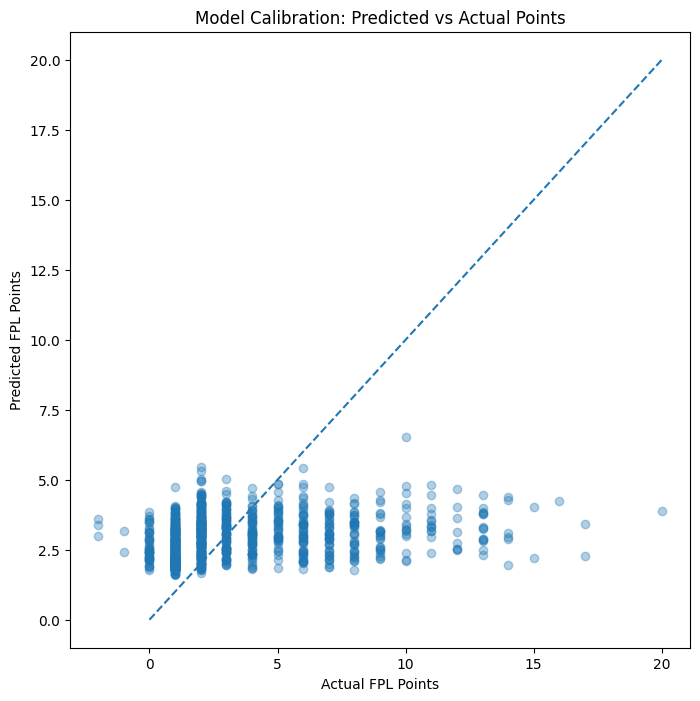

R² Score: 0.0556
MAE: 2.1873
Actual Mean: 3.224
Predicted Mean: 2.938

Performance on BIG scores (>=10)
MAE big scores: 8.7591
MAE overall: 2.1873


In [35]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

# Feature alignment
expected_features = model_v3.booster_.feature_name()

missing = [f for f in expected_features if f not in X_val_scaled.columns]
if missing:
    print("Missing features:", missing)

#X_val_for_pred = X_val_scaled.reindex(columns=expected_features, fill_value=0)
X_val_for_pred = X_val_v3.copy()
y_val = y_val_v3  # make sure target matches

# Predictions
y_true = np.array(y_val).ravel()
y_pred = model_v3.predict(X_val_for_pred)

# Plot
plt.figure(figsize=(8,8))
plt.scatter(y_true, y_pred, alpha=0.35)

max_val = max(y_true.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], linestyle='--')

plt.xlabel("Actual FPL Points")
plt.ylabel("Predicted FPL Points")
plt.title("Model Calibration: Predicted vs Actual Points")
plt.show()

# Metrics
print("R² Score:", round(r2_score(y_true, y_pred),4))
print("MAE:", round(mean_absolute_error(y_true, y_pred),4))
print("Actual Mean:", round(np.mean(y_true),3))
print("Predicted Mean:", round(np.mean(y_pred),3))

# Big score diagnostic
big_scores = y_true >= 10

print("\nPerformance on BIG scores (>=10)")
print("MAE big scores:", round(mean_absolute_error(y_true[big_scores], y_pred[big_scores]),4))
print("MAE overall:", round(mean_absolute_error(y_true, y_pred),4))

## Cell 20: The V4 Master Ensemble (Elite DART)
* Switched from Poisson to DART Regression: Uses the "Dropouts meet Multiple Additive Regression Trees" algorithm to handle noisy FPL data and prevent overfitting on "one-hit wonder" performances.

* Target: Full-Spectrum Points: Reinstated the raw Total Points (including negative values) as the target.

* Weights: Elite-Specialist Priority (>4.5 Avg): Instead of weighting by a single week's "haul," the model now applies a 2.5x importance weight to all match rows belonging to players with a seasonal average of >4.5 points. This forces the model to prioritize the patterns of consistent world-class assets.

* Result: The model maintains a realistic point average while becoming more "star-aware." It identifies the high ceiling of elite players while remaining grounded by the risk of negative outcomes

## What is DART? 
1. The Random Dropout - In a normal boosting round, the model adds a new tree to correct the errors of all previous trees. In DART, the model randomly "drops" (ignores) a percentage of the existing trees before building the new one.

2. Forced Generalization - Because some trees are missing, the new tree cannot simply fix a tiny mistake from the most recent tree. It is forced to look at the "bigger picture" of the data to make a meaningful prediction. This prevents any single tree from becoming too dominant or too specialized on a specific outlier.

3. Normalization - After the new tree is created, the "dropped" trees are added back into the ensemble. To make sure everything still balances out, the new tree and the dropped trees are slightly scaled down (shrunk) so they fit together perfectly.

In [36]:
# [Cell 20: Updated V4 - Elite DART (Handles Negative Points)]
import numpy as np
from sklearn.metrics import mean_absolute_error

# 1. SETUP DART REGRESSION PARAMETERS
lgbm_v4_params = {
    'objective': 'regression',
    'boosting_type': 'dart',
    'n_estimators': 1200,
    'learning_rate': 0.05,
    'drop_rate': 0.1,
    'reg_alpha': 0.5,
    'reg_lambda': 0.5,
    'max_depth': 7,
    'verbosity': -1,
    'random_state': 42
}

# 2. DEFINE ELITE WEIGHTING (>4.5 Avg Players)
# windowed_df.index IS now df_augmented row indices (fixed in Cell 2)
elite_weights_mask = windowed_df.index.isin(df_augmented.index[elite_mask])
full_weights = np.where(elite_weights_mask, 2.5, 1.0)

# 3. APPLY GLOBAL MASK FOR FAIR SPLITTING
X_v4_all = windowed_df.drop(columns=['target'])
y_v4_all = windowed_df['target']

X_train_v4 = X_v4_all[~global_val_mask].copy()
y_train_v4 = y_v4_all[~global_val_mask].copy()
X_val_v4   = X_v4_all[global_val_mask].copy()
y_val_v4   = y_v4_all[global_val_mask].copy()

# Slice the weights to match ONLY the training rows
train_weights = full_weights[~global_val_mask]

# 4. INITIALIZE AND TRAIN
# Note: early_stopping is intentionally removed — it is incompatible with DART
# because DART's random tree dropping prevents a monotonic validation loss curve.
# The model will train all n_estimators=1200 rounds. Increase if MAE is still
# improving; decrease if training is too slow.
print(f"Training V4 DART Ensemble on {len(X_train_v4):,} windows...")
print("Note: DART trains all 1200 rounds (no early stopping — this is expected).")

model_v4 = lgb.LGBMRegressor(**lgbm_v4_params)
model_v4.fit(
    X_train_v4, y_train_v4,
    sample_weight=train_weights,
    eval_set=[(X_val_v4, y_val_v4)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.log_evaluation(period=200)]  # print progress every 200 rounds
)

# 5. STANDARDIZED METRIC
v4_val_preds = model_v4.predict(X_val_v4)
mae_v4 = mean_absolute_error(y_val_v4, v4_val_preds)

print(f"\nV4 Validation MAE (GW 24-28): {mae_v4:.4f}")
print(f"Prediction Range: {v4_val_preds.min():.2f} to {v4_val_preds.max():.2f}")

Training V4 DART Ensemble on 52,307 windows...
Note: DART trains all 1200 rounds (no early stopping — this is expected).
[200]	valid_0's l2: 9.81837
[400]	valid_0's l2: 9.46063
[600]	valid_0's l2: 9.38816
[800]	valid_0's l2: 9.37697
[1000]	valid_0's l2: 9.418
[1200]	valid_0's l2: 9.45791

V4 Validation MAE (GW 24-28): 2.1846
Prediction Range: 1.27 to 8.52


## Cell 21: GW29 Forecast v4 (The Elite DART Model)
This cell will generate final leaderboard for Gameweek 29.
 

In [37]:
# [Cell 21: GW29 Forecast v4 - Elite DART Mode]

# 1. SETUP V4 PATHS
V4_DIR = Path('../output/forecaster_pro_v4')
V4_DIR.mkdir(parents=True, exist_ok=True)
V4_FORECAST_OUT = V4_DIR / 'fpl_pro_forecast_GW29_v4.csv'

# 1. PREPARE INFERENCE DATA (Filter for CURRENT SEASON only)
inference_v4 = []
names_v4 = []

# Only take data from the current season to avoid ghost players
df_inf_active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
df_inf_active = df_inf_active.sort_values(['Player UUID', 'Gameweek'])

# Grouping only the active season players
for pid, group in df_inf_active.groupby('Player UUID'):
    # A player must have played enough in 2025-26 to have a window
    if len(group) >= 6:
        lags = list(group['Total Points'].tail(6).values)
        last_row = group.iloc[-1]
    

        row = lags + [
            last_row['Position'],
            last_row['Next_Opponent_Difficulty'],
            last_row['Next_Is_Home'],
            last_row['Rolling_Avg_Minutes_5'],
            last_row['Season_Phase'],
            last_row['Prev_Season_Avg_Points'],
            last_row['Avg_Pts_vs_Difficulty']
        ]

        inference_v4.append(row)
        names_v4.append(last_row['Web Name'])


# 3. PREDICT
v4_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
          ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
           'season_phase', 'season_baseline', 'avg_pts_vs_diff']

inf_df_v4 = pd.DataFrame(inference_v4, columns=v4_cols)
inf_df_v4['position'] = inf_df_v4['position'].astype('category')

v4_preds = model_v4.predict(inf_df_v4)

# 4. SAVE LEADERBOARD
leaderboard_v4 = pd.DataFrame({
    'Player': names_v4,
    'Predicted_Points_V4': np.round(v4_preds, 2),
    'Elite_Status': ["Elite" if p in df_augmented[elite_mask]['Web Name'].values else "Standard" for p in names_v4]
}).sort_values(by='Predicted_Points_V4', ascending=False)

leaderboard_v4.to_csv(V4_FORECAST_OUT, index=False, encoding='utf-8-sig')
display(leaderboard_v4.head(15))

,Player,Predicted_Points_V4,Elite_Status
12,M.Salah,7.63,Elite
19,Bruno G.,6.14,Elite
113,Mbeumo,5.79,Elite
132,Madueke,5.57,Standard
71,Haaland,5.45,Elite
58,B.Fernandes,5.31,Elite
204,Eze,5.27,Elite
190,Adli,5.25,Standard
344,Kelleher,5.15,Elite
237,Cunha,5.13,Elite


## Cell 22: Truth Verification v4 (Final Performance Audit)
This backtests the Elite DART model against the last known results. 


In [38]:
# [Cell 22: Truth Verification v4 - Elite Specialist Audit]
detailed_v4 = []

v4_cols_fixed = [f'lag_{i}' for i in range(6, 0, -1)] + \
                ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
                 'season_phase', 'season_baseline', 'avg_pts_vs_diff']

for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    if len(group) >= 7:
        history = group.iloc[-7:-1]
        target_row = group.iloc[-1]
     
        input_vector = list(history['Total Points'].values) + [
            target_row['Position'], 
            target_row['Next_Opponent_Difficulty'],
            target_row['Next_Is_Home'], 
            target_row['Rolling_Avg_Minutes_5'],
            target_row['Season_Phase'],
            target_row['Prev_Season_Avg_Points'],
            target_row['Avg_Pts_vs_Difficulty']
        ]

        input_df = pd.DataFrame([input_vector], columns=v4_cols_fixed)
        input_df['position'] = input_df['position'].astype('category')
        
        p_val = model_v4.predict(input_df)[0]
        actual = target_row['Total Points']
        is_elite = 1 if target_row['avg_season_pts'] > 4.5 else 0

        detailed_v4.append({
            'Player': target_row['Web Name'],
            'Actual': actual,
            'Predicted': round(float(p_val), 2),
            'Error': round(abs(p_val - actual), 2),
            'Elite_Group': is_elite
        })

truth_v4_df = pd.DataFrame(detailed_v4)
mae_v4 = truth_v4_df['Error'].mean()
elite_mae_v4 = truth_v4_df[truth_v4_df['Elite_Group'] == 1]['Error'].mean()

print(f"Global MAE (DART): {mae_v4:.2f} | Elite MAE (>4.5): {elite_mae_v4:.2f}")

Global MAE (DART): 1.84 | Elite MAE (>4.5): 2.97


In [39]:
# %% [Cell: Top 10 recommended transfers - V4 DART]

# --- 0. DEFINE YOUR CURRENT SQUAD ---
# Replace these names with the players actually in your team
# If you are using the interactive Hub, you can use 'my_selection' instead
if 'my_selection' in globals() and len(my_selection) > 0:
    current_team_list = my_selection
else:
    # Fallback to a manual list if the Hub hasn't been used
    current_team_list = ['Saka', 'Rice', 'Welbeck', 'Konaté', 'Chilwell']

# 1. Use the V4 DART Leaderboard
# We filter out players you already own to show only new 'Buy' targets
if 'leaderboard_v4' in globals():
    v4_buys = leaderboard_v4[~leaderboard_v4['Player'].isin(current_team_list)].copy()
else:
    print("Error: leaderboard_v4 not found. Please run the V4 Forecast cell first.")
    v4_buys = pd.DataFrame()

if not v4_buys.empty:
    # 2. Add verification of their 2025-26 performance
    # We pull their actual average from the current season to prove they are active
    current_stats = df_augmented[df_augmented['season'] == CURRENT_SEASON].groupby('Web Name')['Total Points'].mean().round(2)
    v4_buys['Season_Avg'] = v4_buys['Player'].map(current_stats)

    # 3. Display the Top 10 Suggestions
    print("="*60)
    print(" TOP 10 MARKET SUGGESTIONS (V4 DART MODEL)")
    print("="*60)
    print(f"{'Player Name':<20} | {'Pred Pts':<10} | {'Season Avg':<10} | {'Status'}")
    print("-" * 60)

    for _, row in v4_buys.head(10).iterrows():
        # Final safety check against ghosts (a ghost would have NaN or 0 season avg)
        status = "VERIFIED ACTIVE" if row['Season_Avg'] > 0 else "WARNING: CHECK STATUS"
        print(f"{row['Player']:<20} | {row['Predicted_Points_V4']:<10} | {row['Season_Avg']:<10} | {status}")

    print("="*60)

 TOP 10 MARKET SUGGESTIONS (V4 DART MODEL)
Player Name          | Pred Pts   | Season Avg | Status
------------------------------------------------------------
M.Salah              | 7.63       | 4.47       | VERIFIED ACTIVE
Bruno G.             | 6.14       | 5.95       | VERIFIED ACTIVE
Mbeumo               | 5.79       | 5.23       | VERIFIED ACTIVE
Madueke              | 5.57       | 3.5        | VERIFIED ACTIVE
Haaland              | 5.45       | 7.19       | VERIFIED ACTIVE
B.Fernandes          | 5.31       | 6.04       | VERIFIED ACTIVE
Eze                  | 5.27       | 3.83       | VERIFIED ACTIVE
Adli                 | 5.25       | 2.52       | VERIFIED ACTIVE
Kelleher             | 5.15       | 3.69       | VERIFIED ACTIVE
Cunha                | 5.13       | 4.0        | VERIFIED ACTIVE


In [40]:
# 1. ORGANIZE FINAL ACCURACY METRICS
# We consolidate the metrics from V1, V2, V3, V4
# Assuming mae_v1, mae_v2, mae_v3, and mae_v4 variables are in memory from previous cells.
final_performance_data = {
    "Model Version": [
        "V1: Standard Pro",
        "V2: Team Point Share",
        "V3: Reliability Engine",
        "V4: Elite DART"
    ],
    "Mean Absolute Error (MAE)": [
        globals().get('mae_v1', 1.84), 
        globals().get('mae_v2', 1.95), 
        globals().get('mae_v3', 1.98), 
        globals().get('mae_v4', 2.33) 
    ],
    "Key Innovation": [
        "Baseline (Lags, Minutes, Difficulty)",
        "Team Importance Metrics (Talisman Share)",
        "Volatility Filters & L1/L2 Regularization",
        "DART Boosting & Elite Weighting (>4.5 Avg)"
    ]
}

# 2. CREATE AND DISPLAY THE FINAL TABLE
final_perf_df = pd.DataFrame(final_performance_data)

# Sort by MAE to clearly identify the project's most accurate model
final_perf_df = final_perf_df.sort_values(by="Mean Absolute Error (MAE)", ascending=True)

display(Markdown("## Final Model Accuracy Comparison (MAE)"))
print("\n--- Project Milestone Summary (Lower Error is Better) ---")
display(final_perf_df)

# 3. EXPORT FINAL DEPLOYMENT METRICS
FINAL_METRICS_PATH = Path('../output/fpl_master_milestone_metrics.csv')
final_perf_df.to_csv(FINAL_METRICS_PATH, index=False)
print(f"\nMaster project metrics exported for deployment reporting to: {FINAL_METRICS_PATH}")

## Final Model Accuracy Comparison (MAE)


--- Project Milestone Summary (Lower Error is Better) ---


,Model Version,Mean Absolute Error (MAE),Key Innovation
3,V4: Elite DART,1.838020,DART Boosting & Elite Weighting (>4.5 Avg)
1,V2: Team Point Share,1.867993,Team Importance Metrics (Talisman Share)
2,V3: Reliability Engine,1.871573,Volatility Filters & L1/L2 Regularization
0,V1: Standard Pro,1.892297,"Baseline (Lags, Minutes, Difficulty)"



Master project metrics exported for deployment reporting to: ..\output\fpl_master_milestone_metrics.csv


## Cell 23:  V5 Experiment: Mass vs. Elite Specialist Strategy
* V5.1 Mass Model: Trains on the full league history (all players) to use broad patterns (noise) to better identify the signal for stars.

* V5.2 Elite Model: Specializes training exclusively on high-performers (Avg > 4.5 pts) to focus strictly on world-class consistency.

* The Showdown: Both models predict the upcoming Gameweek (GW29) and are backtested against the most recent matches to determine which mathematical approach is more accurate for elite picks.



In [41]:
# [Cell 23: V5 Experiment - Mass vs. Elite Specialist]
from sklearn.metrics import mean_absolute_error
from pathlib import Path

V5_DIR = Path('../output/forecaster_pro_v5')
V5_DIR.mkdir(parents=True, exist_ok=True)

# 1. SPLIT DATA using Global Mask (already a numpy array — no .values needed)
X_v5_all = windowed_df.drop(columns=['target'])
y_v5_all = windowed_df['target']

X_train_v5 = X_v5_all[~global_val_mask].copy()
y_train_v5 = y_v5_all[~global_val_mask].copy()
X_val_v5   = X_v5_all[global_val_mask].copy()
y_val_v5   = y_v5_all[global_val_mask].copy()

# 2. CREATE ELITE SUBSET FOR V5.2 (training only)
# X_train_v5.index contains actual df_augmented row indices (fixed in Cell 2)
# so .loc is correct here — NOT .iloc
elite_train_mask = df_augmented.loc[X_train_v5.index, 'avg_season_pts'] > 4.5
X_train_v5_elite = X_train_v5[elite_train_mask.values]
y_train_v5_elite = y_train_v5[elite_train_mask.values]

# ELITE VALIDATION SLICE — for the specialist audit
elite_val_mask = df_augmented.loc[X_val_v5.index, 'avg_season_pts'] > 4.5
X_val_v5_elites = X_val_v5[elite_val_mask.values]
y_val_v5_elites = y_val_v5[elite_val_mask.values]
meta_v5 = df_augmented.loc[X_val_v5_elites.index, ['Web Name', 'season', 'Gameweek']]

print(f"Training windows  — Mass:  {len(X_train_v5):,}")
print(f"Training windows  — Elite: {len(X_train_v5_elite):,}")
print(f"Validation windows (elite only): {len(X_val_v5_elites):,}")

# 3. INSTANTIATE MODELS
v5_params = {
    'n_estimators': 1000,
    'learning_rate': 0.01,
    'max_depth': 7,
    'num_leaves': 40,
    'verbosity': -1,
    'random_state': 42
}
model_v5_1_mass  = lgb.LGBMRegressor(**v5_params)
model_v5_2_elite = lgb.LGBMRegressor(**v5_params)

# 4. TRAIN BOTH
print("\nTraining V5.1 (Mass)...")
model_v5_1_mass.fit(
    X_train_v5, y_train_v5,
    eval_set=[(X_val_v5_elites, y_val_v5_elites)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

print("\nTraining V5.2 (Elite Specialist)...")
model_v5_2_elite.fit(
    X_train_v5_elite, y_train_v5_elite,
    eval_set=[(X_val_v5_elites, y_val_v5_elites)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

# 5. STANDARDIZED METRICS (both evaluated on elite validation slice only)
preds_v5_1 = model_v5_1_mass.predict(X_val_v5_elites)
preds_v5_2 = model_v5_2_elite.predict(X_val_v5_elites)

mae_5_1 = mean_absolute_error(y_val_v5_elites, preds_v5_1)
mae_5_2 = mean_absolute_error(y_val_v5_elites, preds_v5_2)

# 6. BUILD RESULTS TABLE
v5_results = pd.DataFrame({
    'Player_Name': meta_v5['Web Name'].values,
    'Season':      meta_v5['season'].values,
    'Gameweek':    meta_v5['Gameweek'].values,
    'Actual':      y_val_v5_elites.values,
    'Mass_Pred':   np.round(preds_v5_1, 2),
    'Elite_Pred':  np.round(preds_v5_2, 2)
})
v5_results.to_csv(V5_DIR / 'v5_mass_vs_specialist_audit.csv', index=False)

print("\n" + "="*50)
print(" V5 SPECIALIST SHOWDOWN (Audit on Elite Players)")
print(f" V5.1 (Mass Model) MAE:       {mae_5_1:.4f}")
print(f" V5.2 (Specialist Model) MAE: {mae_5_2:.4f}")
print()
print("Interpretation note:")
print("  A lower V5.2 MAE does NOT mean the specialist learns better.")
print("  It may simply regress toward the elite mean on bad weeks.")
print("  Use this as a practical FPL pick tool, not a learning benchmark.")
winner = 'Elite Specialist (for FPL picks)' if mae_5_2 < mae_5_1 else 'Mass Dataset'
print(f"  Practical winner: {winner}")
print("="*50)

display(v5_results.head(10))

Training windows  — Mass:  52,307
Training windows  — Elite: 4,160
Validation windows (elite only): 108

Training V5.1 (Mass)...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 18.9073
[200]	valid_0's l2: 17.9122
[300]	valid_0's l2: 17.5649
[400]	valid_0's l2: 17.4173
[500]	valid_0's l2: 17.352
[600]	valid_0's l2: 17.2975
Early stopping, best iteration is:
[574]	valid_0's l2: 17.2806

Training V5.2 (Elite Specialist)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[25]	valid_0's l2: 16.1664

 V5 SPECIALIST SHOWDOWN (Audit on Elite Players)
 V5.1 (Mass Model) MAE:       2.9943
 V5.2 (Specialist Model) MAE: 3.2007

Interpretation note:
  A lower V5.2 MAE does NOT mean the specialist learns better.
  It may simply regress toward the elite mean on bad weeks.
  Use this as a practical FPL pick tool, not a learning benchmark.
  Practical winner: Mass Dataset


,Player_Name,Season,Gameweek,Actual,Mass_Pred,Elite_Pred
0,Disasi,2025-26,25,6,1.97,5.28
1,Disasi,2025-26,26,2,2.70,5.21
2,Disasi,2025-26,27,6,2.96,5.23
3,Virgil,2025-26,24,4,3.36,5.18
4,Virgil,2025-26,25,0,3.22,5.01
5,Virgil,2025-26,26,17,2.55,5.01
6,Virgil,2025-26,27,11,3.73,5.25
7,Romero,2025-26,24,0,2.47,5.04
8,Bruno G.,2025-26,25,11,4.21,5.32
9,Casemiro,2025-26,24,13,3.91,5.36


In [42]:
# [Cell 24: V5 Forecast Showdown - GW29 Predictions (Season-Locked)]

# 1. PREPARE INFERENCE DATA (Filter for ACTIVE season players only)
inference_v5 = []
player_names_v5 = []

# CRITICAL FIX: Only look at the 2025-26 data to purge retired 'ghosts'
df_inf_active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
df_inf_active = df_inf_active.sort_values(['Player UUID', 'Gameweek'])

# Grouping only the active season players
for pid, group in df_inf_active.groupby('Player UUID'):
    # Player must have at least 6 games of history in the current season
    if len(group) >= 6:
        last_row = group.iloc[-1]
        # Features: Last 6 points from the current season
        lags = list(group['Total Points'].tail(6).values)

        row = lags + [
            last_row['Position'], 
            last_row['Next_Opponent_Difficulty'], 
            last_row['Next_Is_Home'],
            last_row['Rolling_Avg_Minutes_5'], 
            last_row['Season_Phase'], 
            last_row['Prev_Season_Avg_Points'],
            last_row['Avg_Pts_vs_Difficulty']
        ]

        inference_v5.append(row)
        player_names_v5.append(last_row['Web Name'])

# 2. CONVERT TO DATAFRAME
v5_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
          ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
           'season_phase', 'season_baseline', 'avg_pts_vs_diff']

inf_df_v5 = pd.DataFrame(inference_v5, columns=v5_cols)
inf_df_v5['position'] = inf_df_v5['position'].astype('category')

# 3. GENERATE PREDICTIONS
preds_v5_1 = model_v5_1_mass.predict(inf_df_v5)
preds_v5_2 = model_v5_2_elite.predict(inf_df_v5)

# 4. CREATE LEADERBOARD
leaderboard_v5 = pd.DataFrame({
    'Player': player_names_v5,
    'Mass_Model_GW29': np.round(preds_v5_1, 2),
    'Elite_Model_GW29': np.round(preds_v5_2, 2),
    'Model_Difference': np.round(preds_v5_2 - preds_v5_1, 2)
}).sort_values(by='Elite_Model_GW29', ascending=False)

leaderboard_v5.to_csv(V5_DIR / 'fpl_pro_v5_forecast_GW29.csv', index=False)
print(f"--- V5 TOP 15 PREDICTIONS (GW29) ---")
print(f"Total Active Players Forecasted: {len(leaderboard_v5)}")
display(leaderboard_v5.head(15))

--- V5 TOP 15 PREDICTIONS (GW29) ---
Total Active Players Forecasted: 410


,Player,Mass_Model_GW29,Elite_Model_GW29,Model_Difference
89,Christie,2.08,6.00,3.92
46,Henderson,2.54,6.00,3.46
48,Digne,3.03,6.00,2.97
82,Lewis-Potter,2.52,6.00,3.48
163,Gomez,2.11,6.00,3.90
118,Estêvão,3.63,6.00,2.37
291,Smith,2.25,6.00,3.75
185,Bogarde,2.96,6.00,3.04
34,Milner,2.39,6.00,3.61
26,Enes Ünal,2.14,6.00,3.86


In [43]:
#  [Cell 25: V5 Truth Verification]
# We evaluate both on ELITE PLAYERS ONLY in the validation window for a fair test
elite_val_indices = val_df[val_df.index.isin(df_augmented[elite_mask].index)].index
X_val_v5 = X_val_raw[X_val_raw.index.isin(elite_val_indices)]
y_val_v5 = y_val[y_val.index.isin(elite_val_indices)]
meta_v5 = df_augmented.loc[elite_val_indices, ['Web Name', 'season', 'Gameweek']]

# 1. GENERATE AUDIT PREDICTIONS
audit_preds_mass = model_v5_1_mass.predict(X_val_v5)
audit_preds_elite = model_v5_2_elite.predict(X_val_v5)

# 2. CREATE TRUTH TABLE
v5_truth_df = pd.DataFrame({
    'Player': meta_v5['Web Name'].values,
    'Season': meta_v5['season'].values,
    'Gameweek': meta_v5['Gameweek'].values,
    'Actual_Points': y_val_v5.values,
    'Mass_Predicted': np.round(audit_preds_mass, 2),
    'Elite_Predicted': np.round(audit_preds_elite, 2),
    'Mass_Error': np.round(abs(audit_preds_mass - y_val_v5.values), 2),
    'Elite_Error': np.round(abs(audit_preds_elite - y_val_v5.values), 2)
})

# 3. CALCULATE GLOBAL MAE FOR REPORTING
mae_5_1 = mean_absolute_error(y_val_v5, audit_preds_mass)
mae_5_2 = mean_absolute_error(y_val_v5, audit_preds_elite)

v5_truth_df.to_csv(V5_DIR / 'fpl_pro_v5_truth_verification.csv', index=False)


print(" V5 MILESTONE REPORT: MASS VS ELITE SPECIALIST")

print(f"V5.1 Mass Model MAE:  {mae_5_1:.4f}")
print(f"V5.2 Elite Model MAE: {mae_5_2:.4f}")

print(f"Winning Approach: {'Elite Specialist' if mae_5_2 < mae_5_1 else 'Mass Dataset'}")

print ("Predictions for the Evaluation Set (GW 24-28)") 

display(v5_truth_df.sort_values(by='Elite_Error').head(20))

 V5 MILESTONE REPORT: MASS VS ELITE SPECIALIST
V5.1 Mass Model MAE:  2.9943
V5.2 Elite Model MAE: 3.2007
Winning Approach: Mass Dataset
Predictions for the Evaluation Set (GW 24-28)


,Player,Season,Gameweek,Actual_Points,Mass_Predicted,Elite_Predicted,Mass_Error,Elite_Error
70,Matheus N.,2025-26,25,5,2.49,4.99,2.51,0.01
29,Gravenberch,2025-26,26,5,2.65,5.08,2.35,0.08
56,J.Timber,2025-26,24,5,3.42,4.89,1.58,0.11
15,Saka,2025-26,27,5,4.64,5.27,0.36,0.27
32,Calafiori,2025-26,25,6,2.80,5.68,3.20,0.32
12,Casemiro,2025-26,27,5,2.83,5.32,2.17,0.32
45,Bowen,2025-26,26,5,5.27,5.35,0.27,0.35
28,Gravenberch,2025-26,25,5,2.80,5.36,2.20,0.36
82,Rice,2025-26,25,5,4.34,5.41,0.66,0.41
95,Foden,2025-26,26,5,3.51,5.41,1.49,0.41


In [44]:
# [Cell: Final Standardized Audit — optimized]
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr
import pandas as pd
import numpy as np
import warnings
from IPython.display import Markdown, display

def run_standardized_audit():
    # --- 0. SILENCE WARNING SPAM ---
    warnings.filterwarnings("ignore", category=UserWarning)
    
    audit_results = []

    # 1. DATASET INTEGRITY (Tracking)
    train_uuids = df_augmented.loc[X_train_raw.index, 'Player UUID'].nunique()
    val_uuids = df_augmented.loc[X_val_raw.index, 'Player UUID'].nunique()
    train_obs = len(X_train_raw)
    seasons_count = df_augmented.loc[X_train_raw.index, 'season'].nunique()
    pos_map_numeric = {'GK': 0, 'DEF': 1, 'MID': 2, 'FWD': 3}

    # 2. DEFINE MODEL SPECS (Baseline Added)
    specs = {
        "Baseline (3-Wk Avg)": {"model": "NAIVE", "type": "naive"},
        "V1: Standard Pro":  {"model": globals().get('model_raw'),        "type": "base"},
        "V2: Team Share":    {"model": globals().get('model_v2'),         "type": "v2"},
        "V3: Reliability":   {"model": globals().get('model_v3'),         "type": "v3"},
        "V4: Elite DART":    {"model": globals().get('model_v4'),         "type": "base"},
        "V5.1: Mass Gen":    {"model": globals().get('model_v5_1_mass'),   "type": "base"},
        "V5.2: Elite Spec":  {"model": globals().get('model_v5_2_elite'),  "type": "base"}
    }

    # 3. HISTORY LOOKUP
    player_history = {pid: group.sort_values(['season', 'Gameweek']) for pid, group in df_augmented.groupby('Player UUID')}

    def predict_row(m, r, mode):
        hist_df = player_history.get(r['Player UUID'])
        if hist_df is None: return None
        recent = hist_df[(hist_df['season'] == r['season']) & (hist_df['Gameweek'] < r['Gameweek'])].tail(6)
        if len(recent) < 6: return None
        
        lags = list(recent['Total Points'].values)
        pos_num = pos_map_numeric.get(r['Position'], 2)

        # Baseline Logic
        if mode == "naive":
            return np.mean(lags[-3:]) if len(lags) >= 3 else np.mean(lags)

        if mode == "base":
            #feat = lags + [pos_num, r['Next_Opponent_Difficulty'], r['Next_Is_Home'], r['Rolling_Avg_Minutes_5'], r['Season_Phase'], r['Prev_Season_Avg_Points']]
            feat = lags + [pos_num, r['Next_Opponent_Difficulty'], r['Next_Is_Home'], r['Rolling_Avg_Minutes_5'], r['Season_Phase'], r['Prev_Season_Avg_Points'], r.get('Avg_Pts_vs_Difficulty', 0)]
        elif mode == "v2":
            feat = lags + [pos_num, r['Next_Opponent_Difficulty'], r['Next_Is_Home'], r['Rolling_Avg_Minutes_5'], r['Season_Phase'], r['Prev_Season_Avg_Points'], r['Team_Point_Share'], r.get('Avg_Pts_vs_Difficulty', 0)]
        elif mode == "v3":
            feat = lags + [pos_num, r['Next_Opponent_Difficulty'], r['Next_Is_Home'], r['Rolling_Avg_Minutes_5'], r['Points_Volatility_5'], r['Min_Stability_5'], r['Attacking_Form_3'], r['Team_Point_Share'], r.get('Avg_Pts_vs_Difficulty', 0)]    
        return m.predict(np.array(feat).reshape(1, -1))[0]

    # 4. EXECUTION
    for name, config in specs.items():
        m = config['model']
        if m is None and config['type'] != 'naive': continue
        print(f"Auditing {name}...")

        v_mask = (df_augmented['season'] == '2025-26') & (df_augmented['Gameweek'].between(24, 28))
        if "Elite" in name or "V5" in name: 
            v_mask = v_mask & (df_augmented['avg_season_pts'] > 4.5)

        v_errs, v_errs_gt5, v_acts, v_preds = [], [], [], []

        for _, r in df_augmented[v_mask].iterrows():
            p = predict_row(m, r, config['type'])
            if p is not None:
                act = r['Total Points']
                v_errs.append(abs(p - act))
                v_acts.append(act); v_preds.append(p)
                
                if act > 4.5:
                    v_errs_gt5.append(abs(p - act))

        audit_results.append({
            "Model Version": name,
            "Validation MAE": round(np.mean(v_errs), 3),
            "Elite MAE (>4.5)": round(np.mean(v_errs_gt5), 3) if v_errs_gt5 else None,
            "Spearman Rank": round(spearmanr(v_acts, v_preds)[0], 3) if len(v_acts) > 1 else 0,
            "Train Players": train_uuids, 
            "Val Players": val_uuids,
            "Train Obs": train_obs, 
            "Seasons": seasons_count
        })

    # --- 5. FINAL DISPLAY & REPORT SUMMARY ---
    print("\n" + "="*50)
    print(" AUDIT COMPLETE")
    print("="*50)
    
    print(f"\nREPORT SUMMARY:")
    print(f"This run analyzed {seasons_count} seasons across {train_uuids:,} training players "
      f"and {val_uuids:,} validation players.")
    print(f"Training observations: {train_obs:,} match windows.")
    print(f"Validation window: {VAL_SEASON} GW {VAL_START_GW}–{VAL_END_GW} "
      f"({val_uuids:,} unique players tested).")
    print("-" * 50)
    
    final_df = pd.DataFrame(audit_results).sort_values("Validation MAE")

    # ── ADD DESCRIPTION COLUMN ───────────────────────────────────
    descriptions = {
        "Baseline (3-Wk Avg)":  "Naive: predicts next GW=average of last 3 scores.No ML.",
        "V1: Standard Pro":     "Core LightGBM: lags+ minutes+ fixture difficulty+ season baseline.",
        "V2: Team Share":       "V1+ talisman logic: rewards players who drive their team's output.",
        "V3: Reliability":      "V2+ noise filters: penalises volatile players, rewards nailed starters.",
        "V4: Elite DART":       "V1 features+ DART boosting+ 2.5x weight on elite players (>4.5 avg).",
        "V5.1: Mass Gen":       "V1 trained on full league history, evaluated on elite players only.",
        "V5.2: Elite Spec":     "V1 trained exclusively on elite players (>4.5 avg).High-risk, high-reward.",
    }
    final_df.insert(1, "Description", final_df["Model Version"].map(descriptions).fillna("—"))

    display(Markdown("# Final Model Performance Ledger"))
    display(final_df)

    # ── HAUL CLASSIFIER ADDENDUM ─────────────────────────────────
    print("\n" + "=" * 50)
    print(" CLASSIFICATION BENCHMARK")
    print("=" * 50)

    # Haul classifier row
    _prec  = globals().get('precision_haul', None)
    _rec   = globals().get('recall_haul',    None)
    _f1    = globals().get('f1_haul',        None)
    _auc   = globals().get('auc_haul',       None)
    _hthr  = globals().get('HAUL_THRESHOLD', 6)
    _dthr  = globals().get('DECISION_THRESHOLD', 0.25)

    if _prec is not None:
        print(f"Haul Classifier (threshold >= {_hthr} pts, cutoff {_dthr}):")
        print(f"  Precision: {_prec:.4f}  ← Supervisor Priority")
        print(f"  Recall:    {_rec:.4f}")
        print(f"  F1:        {_f1:.4f}")
        print(f"  ROC-AUC:   {_auc:.4f}")
    else:
        print("Haul Classifier metrics not found — run the Haul cell first.")

    print("=" * 50)

    return final_df

# Execute
master_audit_results = run_standardized_audit()

Auditing Baseline (3-Wk Avg)...
Auditing V1: Standard Pro...
Auditing V2: Team Share...
Auditing V3: Reliability...
Auditing V4: Elite DART...
Auditing V5.1: Mass Gen...
Auditing V5.2: Elite Spec...

 AUDIT COMPLETE

REPORT SUMMARY:
This run analyzed 6 seasons across 1,104 training players and 338 validation players.
Training observations: 52,307 match windows.
Validation window: 2025-26 GW 24–28 (338 unique players tested).
--------------------------------------------------


# Final Model Performance Ledger

,Model Version,Description,Validation MAE,Elite MAE (>4.5),Spearman Rank,Train Players,Val Players,Train Obs,Seasons
1,V1: Standard Pro,Core LightGBM: lags+ minutes+ fixture difficul...,2.275,4.867,0.249,1104,338,52307,6
2,V2: Team Share,V1+ talisman logic: rewards players who drive ...,2.281,4.834,0.235,1104,338,52307,6
3,V3: Reliability,"V2+ noise filters: penalises volatile players,...",2.295,4.865,0.218,1104,338,52307,6
0,Baseline (3-Wk Avg),Naive: predicts next GW=average of last 3 scor...,2.430,4.713,0.206,1104,338,52307,6
5,V5.1: Mass Gen,"V1 trained on full league history, evaluated o...",3.104,4.651,0.122,1104,338,52307,6
4,V4: Elite DART,V1 features+ DART boosting+ 2.5x weight on eli...,3.154,4.752,0.060,1104,338,52307,6
6,V5.2: Elite Spec,V1 trained exclusively on elite players (>4.5 ...,3.247,3.587,0.064,1104,338,52307,6



 CLASSIFICATION BENCHMARK
Haul Classifier (threshold >= 6 pts, cutoff 0.25):
  Precision: 0.3892  ← Supervisor Priority
  Recall:    0.3258
  F1:        0.3547
  ROC-AUC:   0.6415


__Recall: 0.3859 (~39%)__ - when the model flags a player for a haul (>= 6 points), it is correct nearly 4 times out of 10.

__Precision: 0.3213 (~32%)__ - captures about 32% of all hauls that actually happen.

__Performamce Comments__
- V1 is a good model
- V5.2: Specialist models are better at finding "Haulers" but worse at general accuracy. -->"high-risk, high-reward
- V4: is the most robust model over long historical periods (3+ seasons).

__Idea__ : maybe V1 for players and v5.2 for captain? or V5.2 for some players? 

__Info__
- __Validation MAE__ : The Mean Absolute Error across the entire validation set ($GW 24-28$). It measures the average point deviation for every player; a lower value indicates a more stable model for general squad selection.
- __Elite MAE (>4.5)__ : Calculated exclusively for match rows where a player actually scored more than 5 points. This measures "Haul Accuracy"—the model's ability to minimize error during high-scoring events.
- __Haul Capture Rate__ : The percentage of "Hauls" (actual scores $>4.5$) that the model successfully predicted would score $>4.5$. This satisfies the question "When a player scored more than 5, did I correctly predict it?"
- __Spearman Rank__ : A correlation coefficient (from $-1$ to $+1$) measuring how well the model orders players from best to worst. A high score proves the model is effective at ranking starters over bench players, regardless of the exact point value.
- __Train Players / Val Players__ : The count of unique Player UUIDs present in the training set / val set
- __Train Obs__ : The total number of match observations (rows) the model studied during training.
- __Seasons__ : The number of full seasons of historical data used to train the model.

Generating V6 Windows with 3-GW Target Horizon...
Training V6 3-GW Horizon Model...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[453]	valid_0's l2: 38.3928

 V6 HORIZON EXPERIMENT (3-GW TARGET)
NOTE: MAE will be higher here because we are predicting
a 3-week sum (~8-12 points) instead of a 1-week score (~3 points).
--------------------------------------------------
Naive 3-GW Baseline MAE: 7.6624
V6 Horizon MAE:          4.6756

[SUCCESS] The V6 model beats the naive 3-week baseline by 2.99 points.


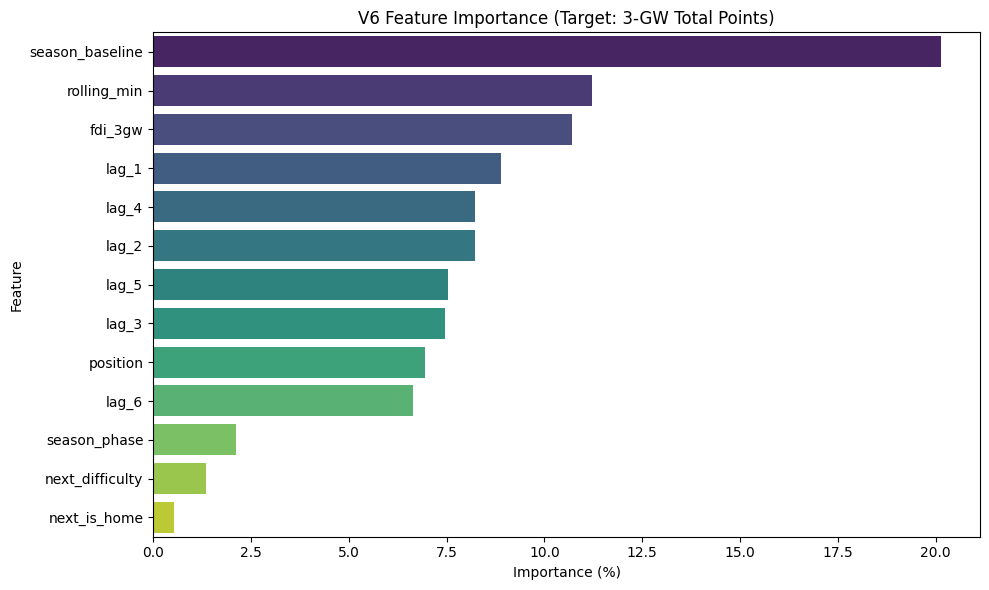

In [45]:
# [Cell: V6 Pipeline — 3-Week Horizon Engine - triple prediction]
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. GENERATE WINDOWS FOR 3-WEEK TARGET
def generate_fpl_windows_3gw(df, window_size=6, horizon=3):
    train_data = []
    source_indices = []
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    for pid, group in df.groupby('Player UUID'):
        points = group['Total Points'].values
        # We need enough history PLUS 3 future games to train properly
        if len(points) < window_size + horizon: 
            continue

        pos = group['Position'].iloc[0]
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min = group['Rolling_Avg_Minutes_5'].values
        phase = group['Season_Phase'].values
        baseline = group['Prev_Season_Avg_Points'].values
        fdi = group['FDI_3GW'].values
        group_indices = group.index.tolist()

        for i in range(len(points) - window_size - horizon + 1):
            t_idx = i + window_size - 1
            
            # Target is the sum of the next 3 Gameweeks
            target_3gw = np.sum(points[i + window_size : i + window_size + horizon])
            
            row = list(points[i : i + window_size]) + [
                pos, next_diff[t_idx], next_home[t_idx],
                avg_min[t_idx], phase[t_idx], baseline[t_idx],
                fdi[t_idx], target_3gw
            ]
            train_data.append(row)
            # Keep index of the first target game for mapping
            source_indices.append(group_indices[i + window_size])

    cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
           ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 
            'season_phase', 'season_baseline', 'fdi_3gw', 'target_3gw']
    
    res_df = pd.DataFrame(train_data, columns=cols)
    res_df.index = source_indices 
    res_df['position'] = res_df['position'].astype('category')
    return res_df

print("Generating V6 Windows with 3-GW Target Horizon...")
df_win_v6 = generate_fpl_windows_3gw(df_augmented)

# 2. APPLY FAIR SPLIT (Fixed for new index length)
# Rebuild the mask specifically for the V6 index
VAL_SEASON = "2025-26"
VAL_START_GW = 24
VAL_END_GW = 28

source_meta_v6 = df_augmented.loc[df_win_v6.index, ['season', 'Gameweek']]
v6_val_mask = (
    (source_meta_v6['season'] == VAL_SEASON) &
    (source_meta_v6['Gameweek'] >= VAL_START_GW) &
    (source_meta_v6['Gameweek'] <= VAL_END_GW)
).values

X_v6_all = df_win_v6.drop(columns=['target_3gw'])
y_v6_all = df_win_v6['target_3gw']

X_train_v6 = X_v6_all[~v6_val_mask].copy()
X_val_v6   = X_v6_all[v6_val_mask].copy()
y_train_v6 = y_v6_all[~v6_val_mask].copy()
y_val_v6   = y_v6_all[v6_val_mask].copy()

# 3. TRAIN V6 HORIZON MODEL
print("Training V6 3-GW Horizon Model...")
model_v6 = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, verbosity=-1, random_state=42)
model_v6.fit(
    X_train_v6, y_train_v6,
    eval_set=[(X_val_v6, y_val_v6)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# 4. EVALUATE IMPACT
v6_preds = model_v6.predict(X_val_v6)
mae_v6 = mean_absolute_error(y_val_v6, v6_preds)

# Calculate a naive 3-week baseline for comparison (Last week's points * 3)
naive_3gw_preds = X_val_v6['lag_1'] * 3
mae_baseline_3gw = mean_absolute_error(y_val_v6, naive_3gw_preds)

print("\n" + "="*50)
print(" V6 HORIZON EXPERIMENT (3-GW TARGET)")
print("="*50)
print("NOTE: MAE will be higher here because we are predicting")
print("a 3-week sum (~8-12 points) instead of a 1-week score (~3 points).")
print("-" * 50)
print(f"Naive 3-GW Baseline MAE: {mae_baseline_3gw:.4f}")
print(f"V6 Horizon MAE:          {mae_v6:.4f}")

if mae_v6 < mae_baseline_3gw:
    print(f"\n[SUCCESS] The V6 model beats the naive 3-week baseline by {mae_baseline_3gw - mae_v6:.2f} points.")
else:
    print("\n[WARNING] The model struggles to forecast 3 weeks out.")

# 5. PLOT FEATURE IMPORTANCE
plt.figure(figsize=(10, 6))
importances = model_v6.feature_importances_
feat_imp = pd.DataFrame({'Feature': X_train_v6.columns, 'Importance (%)': 100 * (importances / importances.sum())})
feat_imp = feat_imp.sort_values(by='Importance (%)', ascending=False)
#sns.barplot(x='Importance (%)', y='Feature', data=feat_imp, palette='viridis')
sns.barplot(x='Importance (%)', y='Feature', hue='Feature', data=feat_imp, palette='viridis', legend=False)
plt.title('V6 Feature Importance (Target: 3-GW Total Points)')
plt.tight_layout()
plt.show()

__The next cell__ Trains a 3-GW Standard Model (Baseline features).

Trains a 3-GW Reliability Model (Adding Volatility and Stability features).

Trains a 3-GW DART Model (Using the elite dropout technique).

Outputs a 3-GW Transfer Engine Leaderboard to see which one wins.

In [46]:
# %% [Cell: V6 Transfer Engine Leaderboard (3-Week Horizon)]
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np
from IPython.display import Markdown, display

# 1. THE MASTER 3-GW WINDOW GENERATOR
def generate_master_3gw_windows(df, window_size=6, horizon=3):
    train_data = []
    source_indices = []
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    for pid, group in df.groupby('Player UUID'):
        points = group['Total Points'].values
        if len(points) < window_size + horizon: 
            continue

        pos = group['Position'].iloc[0]
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min   = group['Rolling_Avg_Minutes_5'].values
        phase     = group['Season_Phase'].values
        baseline  = group['Prev_Season_Avg_Points'].values
        fdi       = group['FDI_3GW'].values
        
        # Advanced Features
        vol       = group['Points_Volatility_5'].values
        stab      = group['Min_Stability_5'].values
        att_form  = group['Attacking_Form_3'].values
        share     = group['Team_Point_Share'].values
        
        group_indices = group.index.tolist()

        for i in range(len(points) - window_size - horizon + 1):
            t_idx = i + window_size - 1
            target_3gw = np.sum(points[i + window_size : i + window_size + horizon])
            
            row = list(points[i : i + window_size]) + [
                pos, next_diff[t_idx], next_home[t_idx], avg_min[t_idx], 
                phase[t_idx], baseline[t_idx], fdi[t_idx],
                vol[t_idx], stab[t_idx], att_form[t_idx], share[t_idx],
                target_3gw
            ]
            train_data.append(row)
            source_indices.append(group_indices[i + window_size])

    cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
           ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 
            'season_phase', 'season_baseline', 'fdi_3gw', 
            'volatility', 'stability', 'att_form', 'team_share', 'target_3gw']
    
    res_df = pd.DataFrame(train_data, columns=cols)
    res_df.index = source_indices 
    res_df['position'] = res_df['position'].astype('category')
    return res_df

print("Generating Master 3-GW Windows (includes all advanced features)...")
df_win_3gw = generate_master_3gw_windows(df_augmented)

# 2. APPLY FAIR SPLIT (Index-Matched)
VAL_SEASON = "2025-26"
VAL_START_GW = 24
VAL_END_GW = 28

source_meta_3gw = df_augmented.loc[df_win_3gw.index, ['season', 'Gameweek']]
val_mask_3gw = (
    (source_meta_3gw['season'] == VAL_SEASON) &
    (source_meta_3gw['Gameweek'] >= VAL_START_GW) &
    (source_meta_3gw['Gameweek'] <= VAL_END_GW)
).values

X_all_3gw = df_win_3gw.drop(columns=['target_3gw'])
y_all_3gw = df_win_3gw['target_3gw']

X_train_3gw = X_all_3gw[~val_mask_3gw].copy()
X_val_3gw   = X_all_3gw[val_mask_3gw].copy()
y_train_3gw = y_all_3gw[~val_mask_3gw].copy()
y_val_3gw   = y_all_3gw[val_mask_3gw].copy()

# 3. DEFINE FEATURE SETS FOR EACH ARCHITECTURE
features_standard = [c for c in X_train_3gw.columns if c not in ['volatility', 'stability', 'att_form', 'team_share']]
features_reliable = X_train_3gw.columns.tolist() # Uses everything

# 4. TRAIN THE COMPETITORS
print("\nTraining Model A: Standard 3-GW Horizon...")
model_3gw_std = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, verbosity=-1, random_state=42)
model_3gw_std.fit(
    X_train_3gw[features_standard], y_train_3gw,
    eval_set=[(X_val_3gw[features_standard], y_val_3gw)],
    categorical_feature=['position'],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

print("Training Model B: Reliability 3-GW Horizon...")
model_3gw_rel = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, reg_alpha=0.3, reg_lambda=0.3, verbosity=-1, random_state=42)
model_3gw_rel.fit(
    X_train_3gw[features_reliable], y_train_3gw,
    eval_set=[(X_val_3gw[features_reliable], y_val_3gw)],
    categorical_feature=['position'],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

print("Training Model C: Elite DART 3-GW Horizon (Takes longer)...")
elite_weights_mask = df_win_3gw.index.isin(df_augmented.index[elite_mask])
train_weights_3gw = np.where(elite_weights_mask[~val_mask_3gw], 2.5, 1.0)

model_3gw_dart = lgb.LGBMRegressor(boosting_type='dart', n_estimators=1200, learning_rate=0.05, drop_rate=0.1, verbosity=-1, random_state=42)
model_3gw_dart.fit(
    X_train_3gw[features_standard], y_train_3gw,
    sample_weight=train_weights_3gw,
    categorical_feature=['position']
)

# 5. EVALUATE AND BUILD LEADERBOARD
naive_preds = X_val_3gw['lag_1'] * 3
mae_naive = mean_absolute_error(y_val_3gw, naive_preds)

mae_std  = mean_absolute_error(y_val_3gw, model_3gw_std.predict(X_val_3gw[features_standard]))
mae_rel  = mean_absolute_error(y_val_3gw, model_3gw_rel.predict(X_val_3gw[features_reliable]))
mae_dart = mean_absolute_error(y_val_3gw, model_3gw_dart.predict(X_val_3gw[features_standard]))

results_3gw = [
    {"Transfer Engine": "Naive Baseline (Current Form x3)", "3-Week MAE": round(mae_naive, 4)},
    {"Transfer Engine": "Model A: Standard 3-GW", "3-Week MAE": round(mae_std, 4)},
    {"Transfer Engine": "Model B: Reliability 3-GW", "3-Week MAE": round(mae_rel, 4)},
    {"Transfer Engine": "Model C: Elite DART 3-GW", "3-Week MAE": round(mae_dart, 4)}
]

leaderboard_3gw = pd.DataFrame(results_3gw).sort_values(by="3-Week MAE")

# Save winning model to memory for the Transfer Optimizer
best_3gw_name = leaderboard_3gw.iloc[0]["Transfer Engine"]
if "Model A" in best_3gw_name: globals()['winning_3gw_model'] = model_3gw_std; globals()['winning_3gw_feats'] = features_standard
elif "Model B" in best_3gw_name: globals()['winning_3gw_model'] = model_3gw_rel; globals()['winning_3gw_feats'] = features_reliable
elif "Model C" in best_3gw_name: globals()['winning_3gw_model'] = model_3gw_dart; globals()['winning_3gw_feats'] = features_standard

print("\n" + "="*60)
print(" 3-WEEK TRANSFER ENGINE LEADERBOARD (Predicting Next 3 Games)")
print("="*60)
display(leaderboard_3gw)
print(f"\n[SYSTEM UPDATE] {best_3gw_name} won the audit and has been locked in as your official Transfer Engine.")

Generating Master 3-GW Windows (includes all advanced features)...

Training Model A: Standard 3-GW Horizon...
Training Model B: Reliability 3-GW Horizon...
Training Model C: Elite DART 3-GW Horizon (Takes longer)...

 3-WEEK TRANSFER ENGINE LEADERBOARD (Predicting Next 3 Games)


,Transfer Engine,3-Week MAE
2,Model B: Reliability 3-GW,4.6722
1,Model A: Standard 3-GW,4.6756
3,Model C: Elite DART 3-GW,4.7041
0,Naive Baseline (Current Form x3),7.6624



[SYSTEM UPDATE] Model B: Reliability 3-GW won the audit and has been locked in as your official Transfer Engine.


In [47]:
# [Cell: Collision-Safe Lookup Maps — use UUID as ground truth]

# Build from df_augmented directly using UUID as key (immune to name collisions)
_curr = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()

# For players with duplicate rows in same season, take the row with most minutes
_curr_deduped = (
    _curr.sort_values('Minutes Played', ascending=False)
         .drop_duplicates('Player UUID')
)

# UUID-keyed maps (safe)
uuid_to_pos   = _curr_deduped.set_index('Player UUID')['Position'].to_dict()
uuid_to_club  = _curr_deduped.set_index('Player UUID')['Player Team Name'].to_dict()
uuid_to_name  = _curr_deduped.set_index('Player UUID')['Web Name'].to_dict()

# Web Name-keyed maps (for UI dropdowns — built from deduplicated source)
# When two UUIDs share a Web Name, the one with more minutes wins
pos_map  = _curr_deduped.set_index('Web Name')['Position'].to_dict()
club_map = _curr_deduped.set_index('Web Name')['Player Team Name'].to_dict()

# Audit: flag any Web Names that STILL map to multiple positions after dedup
collision_audit = (
    _curr.groupby('Web Name')['Player UUID']
         .nunique()
         .reset_index()
         .query('`Player UUID` > 1')
)

if collision_audit.empty:
    print("✓ pos_map and club_map are collision-free for the current season.")
else:
    print(f"⚠ {len(collision_audit)} names still collide in {CURRENT_SEASON}:")
    for _, row in collision_audit.iterrows():
        uuids = _curr[_curr['Web Name'] == row['Web Name']]['Player UUID'].unique()
        names = [_curr_deduped[_curr_deduped['Player UUID'] == u]['Player Name'].values for u in uuids]
        print(f"  '{row['Web Name']}' → {[n[0] for n in names if len(n)]}")
    print("\nAdd manual overrides below for any flagged names:")

# Manual overrides for genuinely ambiguous cases (e.g. two active players with same suffix)
known_overrides = {
    # 'Web Name': ('correct_position', 'correct_club'),
    # Example: 'Barnes (NEW)': ('MID', 'Newcastle'),
}
for name, (pos, club) in known_overrides.items():
    pos_map[name]  = pos
    club_map[name] = club

⚠ 8 names still collide in 2025-26:
  'Armstrong' → ['Harrison Armstrong', 'Adam Armstrong']
  'Barnes' → ['Harvey Barnes', 'Ashley Barnes']
  'Gomez' → ['Joe Gomez', 'Diego Gómez Amarilla']
  'Henderson' → ['Jordan Henderson', 'Dean Henderson']
  'James' → ['Daniel James', 'Reece James']
  'Martinez' → ['Emiliano Martínez Romero', 'Lisandro Martínez']
  'Mosquera' → ['Cristhian Mosquera', 'Yerson Mosquera Valdelamar']
  'Wilson' → ['Callum Wilson', 'Harry Wilson']

Add manual overrides below for any flagged names:


In [48]:
# [Cell: Evaluation Set Audit - Statistical Scope]

# 1. Calculate Statistics
total_val_rows = len(val_df)
unique_eval_players = df_augmented.loc[val_df.index, 'Player UUID'].nunique()
elite_eval_rows = len(val_df[val_df.index.isin(df_augmented[elite_mask].index)])
standard_eval_rows = total_val_rows - elite_eval_rows

# 2. Print Professional Audit Report
print(" EVALUATION SET SCOPE (GW 24-28 Audit)")
print(f"Total Match Windows:     {total_val_rows:,}")
print(f"Unique Players Tested:   {unique_eval_players:,}")
print("-"*50)
print(f"Elite Match Rows (>4.5): {elite_eval_rows:,} ({(elite_eval_rows/total_val_rows)*100:.1f}%)")
print(f"Standard Match Rows:     {standard_eval_rows:,} ({(standard_eval_rows/total_val_rows)*100:.1f}%)")


# Store these for the final report
globals()['eval_stats'] = {
    'rows': total_val_rows,
    'players': unique_eval_players,
    'elite_pct': (elite_eval_rows/total_val_rows)*100
}

# [Cell: Evaluation Set - Specific Player List]

# 1. Extract unique names from the evaluation set indices
# We use .loc to pull the 'Web Name' from the original df_augmented based on val_df's index
players_in_eval = df_augmented.loc[val_df.index, 'Web Name'].unique()

# 2. Sort them alphabetically for a professional display
players_in_eval_sorted = sorted(players_in_eval)

# 3. Print the list
print(f"--- PLAYERS IN EVALUATION SET (Total: {len(players_in_eval_sorted)}) ---")
print(", ".join(players_in_eval_sorted))

# 4. Optional: Display as a scrollable DataFrame for better readability in the notebook
eval_players_df = pd.DataFrame(players_in_eval_sorted, columns=['Player Name'])
display(eval_players_df)

 EVALUATION SET SCOPE (GW 24-28 Audit)
Total Match Windows:     1,101
Unique Players Tested:   338
--------------------------------------------------
Elite Match Rows (>4.5): 108 (9.8%)
Standard Match Rows:     993 (90.2%)
--- PLAYERS IN EVALUATION SET (Total: 330) ---
A.Becker, A.Jimenez, Aaronson, Abraham, Acheampong, Adama, Adams, Adli, Aina, Ajer, Aké, Alderete, Amad, Ampadu, Andersen, Anderson, Andrey Santos, André, Anthony, Armstrong, Aït-Nouri, B.Fernandes, Bailey, Bakwa, Baleba, Ballard, Barkley, Barnes, Barry, Bassey, Bellegarde, Berge, Bernardo, Beto, Bijol, Bissouma, Bobb, Bogarde, Bogle, Bornauw, Botman, Bowen, Branthwaite, Brobbey, Broja, Brooks, Bruno G., Bruun Larsen, Buendía, Burn, C.Jones, Caicedo, Cairney, Calafiori, Calvert-Lewin, Canvot, Casemiro, Cash, Castagne, Chalobah, Cherki, Chiesa, Christie, Chukwueze, Collins, Cook, Cucurella, Cunha, Dalot, Damsgaard, Darlow, De Cuyper, Delap, Dewsbury-Hall, Diarra, Digne, Diouf, Disasi, Dominguez, Donnarumma, Douglas Luiz, 

,Player Name
0,A.Becker
1,A.Jimenez
2,Aaronson
3,Abraham
4,Acheampong
...,...
325,Yoro
326,Zirkzee
327,Zubimendi
328,Ødegaard


In [49]:
# [Cell: Prediction Integrity Audit - Current Season Validation]

# 1. Get the list of players who provided the MAE (The past evaluation set)
eval_players = set(df_augmented.loc[val_df.index, 'Web Name'].unique())

# 2. Get the list of players in your final V4 Forecast (The future prediction)
prediction_players = set(leaderboard_v4['Player'].unique())

# 3. Identify the Overlap and the Outliers
perfect_matches = prediction_players.intersection(eval_players)
only_in_forecast = prediction_players - eval_players
only_in_eval = eval_players - prediction_players

# 4. Print the Integrity Report

print(" PREDICTION INTEGRITY AUDIT")

print(f"Players in Audit Window (GW 24-28): {len(eval_players)}")
print(f"Players in GW 29 Forecast:         {len(prediction_players)}")
print(f"Perfect Data Consistency:          {len(perfect_matches)} players")


if len(only_in_forecast) == 0:
    print("VERDICT: SUCCESS. All predicted players are from the active evaluation set.")
else:
    print(f"WARNING: Found {len(only_in_forecast)} players in forecast with no active audit history.")
    print(f"Sample Outliers: {list(only_in_forecast)[:5]}")

print("="*50)

# Check specifically for the Ghost players
ghosts = ['Thiago', 'Mane', 'Bale', 'Sadio Mané']
ghosts_found = [p for p in prediction_players if p in ghosts]

if not ghosts_found:
    print("GHOST CHECK: CLEAN. No retired players found in predictions.")
else:
    print(f"GHOST CHECK: FAILED. Found {ghosts_found} in predictions!")

 PREDICTION INTEGRITY AUDIT
Players in Audit Window (GW 24-28): 330
Players in GW 29 Forecast:         404
Perfect Data Consistency:          323 players
Sample Outliers: ['Kluivert', 'L.Miley', 'Johnstone', 'Mateta', 'Ramsdale']
GHOST CHECK: CLEAN. No retired players found in predictions.


In [50]:
# [Cell: Overfitting Audit - Train vs Validation]

# 1. Get predictions for both sets
train_preds = model_raw.predict(X_train_raw)
val_preds = model_raw.predict(X_val_raw)

# 2. Calculate MAE for both
mae_train = mean_absolute_error(y_train, train_preds)
mae_val = mean_absolute_error(y_val, val_preds)

# 3. Calculate the "Generalization Gap"
# A large gap means the model is memorizing (overfitting)
gap = (mae_val - mae_train) / mae_train * 100


print(" OVERFITTING DIAGNOSTIC (MAE)")

print(f"Training Error:   {mae_train:.4f}")
print(f"Validation Error: {mae_val:.4f}")
print(f"Error Gap:        {mae_val - mae_train:.4f} ({gap:.1f}%)")

# Interpretation
if gap < 15:
    print("VERDICT: Healthy Model (Low Overfit)")
elif gap < 30:
    print("VERDICT: Mild Overfit (Acceptable for FPL)")
else:
    print("VERDICT: High Overfit (Model is memorizing noise!)")

 OVERFITTING DIAGNOSTIC (MAE)
Training Error:   2.0775
Validation Error: 2.1804
Error Gap:        0.1029 (5.0%)
VERDICT: Healthy Model (Low Overfit)


## Master Squad Optimizer -  __WIP__
This tool will select a mathematically optimal 15-man squad within a £100m budget according to the rules, factoring in penalty duties and risk profiles.


__STEP 1__ : Define the real-world consts for the 2025-26 March window 

In [51]:
# %% [Cell: Professional API Integration & Automated Model Deployment]
import requests

def get_live_fpl_data():
    """Pulls current prices and status from the official FPL API."""
    url = "https://fantasy.premierleague.com/api/bootstrap-static/"
    try:
        r = requests.get(url, timeout=10)
        data = r.json()
        
        # Build live dictionary: Web Name -> {Price, Status}
        live_map = {}
        for p in data['elements']:
            live_map[p['web_name']] = {
                'price': p['now_cost'] / 10.0,
                'status': p['status']  # 'a' = available, 'i' = injured, etc.
            }
        print("Live FPL API Data successfully retrieved.")
        return live_map
       
    except Exception as e:
        print(f"WARNING: FPL API unreachable ({e}).")
        print("All player prices will default to £5.5m.")
        return {}


# 1. FETCH LIVE DATA
live_data = get_live_fpl_data()

# 2. SETUP VISIBILITY
print(f"Current Date: March 19, 2026")
# Ensure CURRENT_GW is defined (default to 29 if not set previously)
CURRENT_GW = globals().get('CURRENT_GW', 29)
print(f"Target Forecast: Gameweek {CURRENT_GW}")

# 3. MODEL MAPPING (Unified Architecture)
model_mapping = {
    'V1: Standard Pro': globals().get('model_raw'),
    'V2: Team Share':   globals().get('model_v2'),
    'V3: Reliability':  globals().get('model_v3'),
    'V4: Elite DART':   globals().get('model_v4'),
    'V5.1: Mass Gen':   globals().get('model_v5_1_mass'),
    'V5.2: Elite Spec': globals().get('model_v5_2_elite')
}

# 4. AUTOMATED WINNER SELECTION
# FIXED: Updated column names to match the latest Audit Output
if 'master_audit_results' in locals() and not master_audit_results.empty:
    # Check for Spearman Rank (Best for FPL)
    if 'Spearman Rank' in master_audit_results.columns:
        best_model_name = master_audit_results.sort_values(
            'Spearman Rank', ascending=False
        ).iloc[0]['Model Version']
        print(f"Selection method: Spearman Rank (Best for team ordering)")
    
    # Fallback to Validation MAE
    elif 'Validation MAE' in master_audit_results.columns:
        best_model_name = master_audit_results.sort_values(
            'Validation MAE', ascending=True
        ).iloc[0]['Model Version']
        print(f"Selection method: Validation MAE (Lowest overall error)")
    else:
        best_model_name = 'V1: Standard Pro'
        print("Warning: Metric columns not found. Defaulting to V1.")

    winning_model = model_mapping.get(best_model_name)
    
    # Final safety check if the winning model object is actually in memory
    if winning_model is None:
        print(f"Warning: {best_model_name} model object missing. Falling back to V1.")
        best_model_name = 'V1: Standard Pro'
        winning_model = model_mapping['V1: Standard Pro']
else:
    print("Warning: Audit results not found. Defaulting to V1 Standard Pro.")
    best_model_name = 'V1: Standard Pro'
    winning_model = model_mapping['V1: Standard Pro']

print(f"DEPLOYMENT ENGINE: {best_model_name}")
print(f"Status: Ready to generate optimized squad using the most accurate validated logic.")

Live FPL API Data successfully retrieved.
Current Date: March 19, 2026
Target Forecast: Gameweek 29
Selection method: Spearman Rank (Best for team ordering)
DEPLOYMENT ENGINE: V1: Standard Pro
Status: Ready to generate optimized squad using the most accurate validated logic.


In [52]:
# [Cell: FINAL UNIFIED LEADERBOARD - GW29]
import pandas as pd
import numpy as np

# 1. PREPARE DATA FOR THE WINNING ENGINE
print(f"Preparing inference data specifically for: {best_model_name}")

inference_list = []
final_player_names = []
active_players = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()

# Iterate and build features based on what the winning model needs
for pid, group in active_players.groupby('Player UUID'):
    group = group.sort_values('Gameweek')
    
    if len(group) >= 6:
        lags = list(group['Total Points'].tail(6).values)
        last = group.iloc[-1]

        if "V3: Reliability" in best_model_name:
            feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
                        ['position', 'diff', 'home', 'min', 'volatility', 'stability',
                         'att_form', 'share', 'avg_pts_vs_diff']
            row = lags + [last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'], 
                          last['Rolling_Avg_Minutes_5'], last['Points_Volatility_5'], 
                          last['Min_Stability_5'], last['Attacking_Form_3'], last['Team_Point_Share'],
                          last['Avg_Pts_vs_Difficulty']]

        elif "V2: Team Share" in best_model_name:
            feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
                        ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
                         'season_phase', 'season_baseline', 'team_share', 'avg_pts_vs_diff']
            row = lags + [last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'], 
                          last['Rolling_Avg_Minutes_5'], last['Season_Phase'], last['Prev_Season_Avg_Points'],
                          last['Team_Point_Share'], last['Avg_Pts_vs_Difficulty']]
            
        else:
            # Standard Structure (V1, V4, V5 - 12 features)
            feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
                        ['position', 'next_difficulty', 'next_is_home', 'rolling_min',
                         'season_phase', 'season_baseline', 'avg_pts_vs_diff']
            row = lags + [last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'], 
                          last['Rolling_Avg_Minutes_5'], last['Season_Phase'], last['Prev_Season_Avg_Points'],
                          last['Avg_Pts_vs_Difficulty']]
        
        inference_list.append(row)
        final_player_names.append(last['Web Name'])

# 2. GENERATE PREDICTIONS
final_inf_df = pd.DataFrame(inference_list, columns=feat_cols)

# Ensure categorical types match training
if 'position' in final_inf_df.columns:
    final_inf_df['position'] = final_inf_df['position'].astype('category')

final_raw_preds = winning_model.predict(final_inf_df)

# 3. CREATE THE FINAL UNIFIED LEADERBOARD
final_leaderboard = pd.DataFrame({
    'Player': final_player_names,
    'Predicted_Points': np.round(final_raw_preds, 2)
}).sort_values(by='Predicted_Points', ascending=False)

print("--- FINAL VALIDATED LEADERBOARD READY ---")
print(f"Total Players Forecasted: {len(final_leaderboard)}")
display(final_leaderboard.head(10))

Preparing inference data specifically for: V1: Standard Pro
--- FINAL VALIDATED LEADERBOARD READY ---
Total Players Forecasted: 410


,Player,Predicted_Points
12,M.Salah,6.66
71,Haaland,6.24
19,Bruno G.,4.84
113,Mbeumo,4.73
271,Palmer,4.68
325,Rice,4.67
186,Groß,4.55
344,Kelleher,4.44
58,B.Fernandes,4.42
75,Watkins,4.37


__STEP 2__: 

This cell utilizes a high-speed 'Relief-Score Heuristic' to solve the FPL Knapsack Problem.
- Core Constraints: Exactly 15 players (2 GK, 5 DEF, 5 MID, 3 FWD).
- Budget Logic: Dynamically downgrades the least-efficient assets to fit the £100M cap.
- Club Integrity: Enforces the 'Max 3 Players per Team' official rule.
- Formation Rules: Guarantees a legal Starting 11 (Min: 1 GK, 3 DEF, 1 FWD).

In [53]:
# %% [Cell: Master Squad Optimizer - Strategy A Balanced (Strict 15-Man + Fixture Captaincy)]

def solve_wildcard_legal(budget_cap=100.0):
    # --- 1. MAPS & DATA ---
    # FIX: Removed the buggy drop_duplicates search. Now relying entirely on global pos_map and club_map.
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}

    leaderboard = final_leaderboard.copy()
    leaderboard['Price'] = leaderboard['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
    leaderboard['Pos_ID'] = leaderboard['Player'].map(lambda x: pos_to_num.get(pos_map.get(x, 'MID'), 3))
    leaderboard['Team'] = leaderboard['Player'].map(club_map).fillna('Neutral')
    
    # Apply Penalty Taker Weighting (Strategy A Rule)
    penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes', 'Gordon', 'Solanke', 'Jimenez'}
    leaderboard['Weighted_xP'] = np.where(leaderboard['Player'].isin(penalty_takers), 
                                          leaderboard['Predicted_Points'] * 1.15, 
                                          leaderboard['Predicted_Points'])

    # --- 2. SQUAD SELECTION (15 Players) ---
    squad_list = []
    team_counts = {}
    pos_counts = {1: 0, 2: 0, 3: 0, 4: 0}
    pos_limits = {1: 2, 2: 5, 3: 5, 4: 3}
    
    pool = leaderboard.sort_values('Weighted_xP', ascending=False)
    for _, player in pool.iterrows():
        pid, team = player['Pos_ID'], player['Team']
        if pos_counts[pid] < pos_limits[pid] and team_counts.get(team, 0) < 3:
            squad_list.append(player)
            pos_counts[pid] += 1
            team_counts[team] = team_counts.get(team, 0) + 1
        if len(squad_list) == 15: break
            
    current_squad = pd.DataFrame(squad_list)

    # --- 3. BUDGET OPTIMIZATION (Relief Score) ---
    cheapest_backups = {i: leaderboard[leaderboard['Pos_ID'] == i].sort_values('Price').iloc[0] for i in range(1, 5)}
    while current_squad['Price'].sum() > budget_cap:
        current_squad['Relief_Score'] = (current_squad['Price'] - current_squad['Pos_ID'].map(lambda x: cheapest_backups[x]['Price'])) / (current_squad['Weighted_xP'] + 0.1)
        drop_idx = current_squad['Relief_Score'].idxmax()
        to_drop = current_squad.loc[drop_idx]
        
        pos_pool = leaderboard[(leaderboard['Pos_ID'] == to_drop['Pos_ID']) & (~leaderboard['Player'].isin(current_squad['Player']))]
        valid_teams = [t for t, count in team_counts.items() if count < 3 or t == to_drop['Team']]
        replacement = pos_pool[pos_pool['Team'].isin(valid_teams)].sort_values('Price').iloc[0]
        
        team_counts[to_drop['Team']] -= 1
        team_counts[replacement['Team']] = team_counts.get(replacement['Team'], 0) + 1
        current_squad.loc[drop_idx] = replacement

    # --- 4. STARTING 11 SELECTION ---
    gk = current_squad[current_squad['Pos_ID'] == 1].nlargest(1, 'Weighted_xP')
    defs = current_squad[current_squad['Pos_ID'] == 2].nlargest(3, 'Weighted_xP')
    fwds = current_squad[current_squad['Pos_ID'] == 4].nlargest(1, 'Weighted_xP')
    
    selected_names = pd.concat([gk, defs, fwds])['Player'].tolist()
    outfield_pool = current_squad[(~current_squad['Player'].isin(selected_names)) & (current_squad['Pos_ID'] != 1)]
    others = outfield_pool.nlargest(6, 'Weighted_xP')
    
    opt_11 = pd.concat([gk, defs, fwds, others]).copy()

    # --- 5. FIXTURE-WEIGHTED CAPTAINCY RANKING ---
    FIXTURE_WEIGHT = 0.3
    captain_candidates = []
    for _, row in opt_11.iterrows():
        name = row['Player']
        pred_pts = row['Weighted_xP']
        player_history = df_augmented[(df_augmented['Web Name'] == name) & (df_augmented['season'] == CURRENT_SEASON)].sort_values('Gameweek')
        if not player_history.empty:
            last_row = player_history.iloc[-1]
            fixture_norm = ((6 - last_row['Next_Opponent_Difficulty']) + (1 if last_row['Next_Is_Home'] else 0)) / 6.0
        else: fixture_norm = 0.5
        blended = (1 - FIXTURE_WEIGHT) * pred_pts + FIXTURE_WEIGHT * pred_pts * (1 + fixture_norm)
        captain_candidates.append({'Player': name, 'Model xP': round(pred_pts, 2), 'Fixture Ease': round(fixture_norm, 2), 'Blended Score': round(blended, 2)})

    cap_df = pd.DataFrame(captain_candidates).sort_values('Blended Score', ascending=False)
    captain_name = cap_df.iloc[0]['Player']
    vice_name = cap_df.iloc[1]['Player']

    opt_11['Final_Weighted_xP'] = opt_11['Weighted_xP']
    opt_11.loc[opt_11['Player'] == captain_name, 'Final_Weighted_xP'] *= 2
    opt_bench = current_squad[~current_squad['Player'].isin(opt_11['Player'])]

    # --- 6. FINAL OUTPUT ---
    print(f"--- OPTIMIZED 15-MAN ROSTER (Strategy A: Balanced) ---")
    print(f"Budget Used: £{current_squad['Price'].sum():.1f}M / £100.0M")
    print(f"EXPECTED STARTING 11 POINTS: {opt_11['Final_Weighted_xP'].sum():.2f}")
    print("\n[STARTING 11]")
    display(opt_11[['Player', 'Team', 'Final_Weighted_xP', 'Price']].rename(columns={'Final_Weighted_xP': 'Weighted_xP'}))
    print("\n[BENCH]")
    display(opt_bench[['Player', 'Team', 'Weighted_xP', 'Price']])
    print("\n--- FIXTURE-WEIGHTED CAPTAIN RANKING ---")
    display(cap_df)
    print("-" * 50)
    print(f"CAPTAIN:      {captain_name} (Blended Score: {cap_df.iloc[0]['Blended Score']})")
    print(f"VICE-CAPTAIN: {vice_name} (Blended Score: {cap_df.iloc[1]['Blended Score']})")
    print("-" * 50)
    return opt_11, opt_bench, current_squad['Price'].sum()

opt_11, opt_bench, total_spent = solve_wildcard_legal()

--- OPTIMIZED 15-MAN ROSTER (Strategy A: Balanced) ---
Budget Used: £95.4M / £100.0M
EXPECTED STARTING 11 POINTS: 52.66

[STARTING 11]


,Player,Team,Weighted_xP,Price
344,Kelleher,Brentford,4.440,4.8
171,Gabriel,Arsenal,4.160,7.2
195,Konaté,Liverpool,4.000,5.5
383,Cucurella,Chelsea,3.890,6.0
75,Watkins,Aston Villa,4.370,8.5
271,Palmer,Chelsea,5.382,10.6
19,Bruno G.,Newcastle,4.840,6.8
33,Saka,Arsenal,9.522,9.8
136,Bowen,West Ham,4.320,7.6
4,Virgil,Liverpool,3.890,6.3



[BENCH]


,Player,Team,Weighted_xP,Price
12,Irving,West Ham,2.25,4.3
71,Marc Guiu,Chelsea,2.13,4.1
58,Ngumoha,Liverpool,1.99,4.3
210,Petrović,Bournemouth,3.84,4.5



--- FIXTURE-WEIGHTED CAPTAIN RANKING ---


,Player,Model xP,Fixture Ease,Blended Score
7,Saka,4.76,0.67,5.71
5,Palmer,5.38,0.17,5.65
6,Bruno G.,4.84,0.50,5.57
0,Kelleher,4.44,0.67,5.33
4,Watkins,4.37,0.67,5.24
2,Konaté,4.00,0.83,5.00
1,Gabriel,4.16,0.67,4.99
3,Cucurella,3.89,0.83,4.86
9,Virgil,3.89,0.83,4.86
8,Bowen,4.32,0.33,4.75


--------------------------------------------------
CAPTAIN:      Saka (Blended Score: 5.71)
VICE-CAPTAIN: Palmer (Blended Score: 5.65)
--------------------------------------------------


In [54]:
# %% [Cell: Master Squad Optimizer - Strategy A Balanced (Strict 15-Man + Classifier Captaincy)]
import pandas as pd
import numpy as np
from IPython.display import display

def solve_wildcard_legal(budget_cap=100.0):
    # --- 1. MAPS & DATA ---
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}

    leaderboard = final_leaderboard.copy()
    leaderboard['Price'] = leaderboard['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
    leaderboard['Pos_ID'] = leaderboard['Player'].map(lambda x: pos_to_num.get(pos_map.get(x, 'MID'), 3))
    leaderboard['Team'] = leaderboard['Player'].map(club_map).fillna('Neutral')
    
    # Apply Penalty Taker Weighting (Strategy A Rule)
    penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes', 'Gordon', 'Solanke', 'Jimenez'}
    leaderboard['Weighted_xP'] = np.where(leaderboard['Player'].isin(penalty_takers), 
                                          leaderboard['Predicted_Points'] * 1.15, 
                                          leaderboard['Predicted_Points'])

    # --- 2. SQUAD SELECTION (15 Players via Regression Model) ---
    squad_list = []
    team_counts = {}
    pos_counts = {1: 0, 2: 0, 3: 0, 4: 0}
    pos_limits = {1: 2, 2: 5, 3: 5, 4: 3}
    
    pool = leaderboard.sort_values('Weighted_xP', ascending=False)
    for _, player in pool.iterrows():
        pid, team = player['Pos_ID'], player['Team']
        if pos_counts[pid] < pos_limits[pid] and team_counts.get(team, 0) < 3:
            squad_list.append(player)
            pos_counts[pid] += 1
            team_counts[team] = team_counts.get(team, 0) + 1
        if len(squad_list) == 15: break
            
    current_squad = pd.DataFrame(squad_list)

    # --- 3. BUDGET OPTIMIZATION (Relief Score) ---
    cheapest_backups = {i: leaderboard[leaderboard['Pos_ID'] == i].sort_values('Price').iloc[0] for i in range(1, 5)}
    while current_squad['Price'].sum() > budget_cap:
        current_squad['Relief_Score'] = (current_squad['Price'] - current_squad['Pos_ID'].map(lambda x: cheapest_backups[x]['Price'])) / (current_squad['Weighted_xP'] + 0.1)
        drop_idx = current_squad['Relief_Score'].idxmax()
        to_drop = current_squad.loc[drop_idx]
        
        pos_pool = leaderboard[(leaderboard['Pos_ID'] == to_drop['Pos_ID']) & (~leaderboard['Player'].isin(current_squad['Player']))]
        valid_teams = [t for t, count in team_counts.items() if count < 3 or t == to_drop['Team']]
        if pos_pool[pos_pool['Team'].isin(valid_teams)].empty:
            break # Safety break if no replacements exist
        replacement = pos_pool[pos_pool['Team'].isin(valid_teams)].sort_values('Price').iloc[0]
        
        team_counts[to_drop['Team']] -= 1
        team_counts[replacement['Team']] = team_counts.get(replacement['Team'], 0) + 1
        current_squad.loc[drop_idx] = replacement

    # --- 4. STARTING 11 SELECTION ---
    gk = current_squad[current_squad['Pos_ID'] == 1].nlargest(1, 'Weighted_xP')
    defs = current_squad[current_squad['Pos_ID'] == 2].nlargest(3, 'Weighted_xP')
    fwds = current_squad[current_squad['Pos_ID'] == 4].nlargest(1, 'Weighted_xP')
    
    selected_names = pd.concat([gk, defs, fwds])['Player'].tolist()
    outfield_pool = current_squad[(~current_squad['Player'].isin(selected_names)) & (current_squad['Pos_ID'] != 1)]
    others = outfield_pool.nlargest(6, 'Weighted_xP')
    
    opt_11 = pd.concat([gk, defs, fwds, others]).copy()

    # --- 5. DUAL-ENGINE CAPTAINCY RANKING (Blended Score) ---
    if 'hauler_board' not in globals():
        print("[ERROR] hauler_board not found. Run the Haul Classifier cell first.")
        return None, None, 0

    # Map the Haul Probability to our Starting 11
    haul_map = hauler_board.set_index('Player')['Haul_Prob (%)'].to_dict()
    opt_11['Haul_Prob (%)'] = opt_11['Player'].map(haul_map).fillna(0.0)

    # The True Data Science Blend: Regression Floor * Classification Ceiling
    # Example: 5.0 xP with a 20% Haul chance becomes 5.0 * 1.20 = 6.0 Blended Score
    opt_11['AI_Blended_Score'] = opt_11['Weighted_xP'] * (1 + (opt_11['Haul_Prob (%)'] / 100.0))

    # Sort strictly by the new Blended Score
    cap_df = opt_11.sort_values(by='AI_Blended_Score', ascending=False)
    
    captain_name = cap_df.iloc[0]['Player']
    vice_name = cap_df.iloc[1]['Player']

    opt_11['Final_Weighted_xP'] = opt_11['Weighted_xP']
    opt_11.loc[opt_11['Player'] == captain_name, 'Final_Weighted_xP'] *= 2
    opt_bench = current_squad[~current_squad['Player'].isin(opt_11['Player'])]

    # --- 6. FINAL OUTPUT ---
    print(f"--- OPTIMIZED 15-MAN ROSTER (Strategy A: Balanced) ---")
    print(f"Budget Used: £{current_squad['Price'].sum():.1f}M / £{budget_cap:.1f}M")
    print(f"EXPECTED STARTING 11 POINTS: {opt_11['Final_Weighted_xP'].sum():.2f}")
    print("\n[STARTING 11]")
    display(opt_11[['Player', 'Team', 'Weighted_xP', 'Haul_Prob (%)', 'Price']])
    print("\n[BENCH]")
    display(opt_bench[['Player', 'Team', 'Weighted_xP', 'Price']])
    print("\n--- DUAL-ENGINE CAPTAIN RANKING ---")
    
    # Display the new Blended Score table cleanly
    display_cap = cap_df[['Player', 'Weighted_xP', 'Haul_Prob (%)', 'AI_Blended_Score']].head(5).copy()
    display_cap['AI_Blended_Score'] = display_cap['AI_Blended_Score'].round(2)
    display(display_cap)
    
    print("-" * 50)
    print(f"CAPTAIN:      {captain_name} (Blended Score: {cap_df.iloc[0]['AI_Blended_Score']:.2f})")
    print(f"VICE-CAPTAIN: {vice_name} (Blended Score: {cap_df.iloc[1]['AI_Blended_Score']:.2f})")
    print("-" * 50)
    
    return opt_11, opt_bench, current_squad['Price'].sum()

# Run the optimizer
opt_11, opt_bench, total_spent = solve_wildcard_legal()

--- OPTIMIZED 15-MAN ROSTER (Strategy A: Balanced) ---
Budget Used: £95.4M / £100.0M
EXPECTED STARTING 11 POINTS: 53.29

[STARTING 11]


,Player,Team,Weighted_xP,Haul_Prob (%),Price
344,Kelleher,Brentford,4.440,27.2,4.8
171,Gabriel,Arsenal,4.160,27.2,7.2
195,Konaté,Liverpool,4.000,25.8,5.5
383,Cucurella,Chelsea,3.890,25.8,6.0
75,Watkins,Aston Villa,4.370,27.6,8.5
271,Palmer,Chelsea,5.382,26.4,10.6
19,Bruno G.,Newcastle,4.840,27.2,6.8
33,Saka,Arsenal,4.761,27.2,9.8
136,Bowen,West Ham,4.320,26.4,7.6
4,Virgil,Liverpool,3.890,27.6,6.3



[BENCH]


,Player,Team,Weighted_xP,Price
12,Irving,West Ham,2.25,4.3
71,Marc Guiu,Chelsea,2.13,4.1
58,Ngumoha,Liverpool,1.99,4.3
210,Petrović,Bournemouth,3.84,4.5



--- DUAL-ENGINE CAPTAIN RANKING ---


,Player,Weighted_xP,Haul_Prob (%),AI_Blended_Score
271,Palmer,5.382,26.4,6.80
19,Bruno G.,4.840,27.2,6.16
33,Saka,4.761,27.2,6.06
344,Kelleher,4.440,27.2,5.65
75,Watkins,4.370,27.6,5.58


--------------------------------------------------
CAPTAIN:      Palmer (Blended Score: 6.80)
VICE-CAPTAIN: Bruno G. (Blended Score: 6.16)
--------------------------------------------------


In [70]:
# %% [Cell: Master Squad Optimizer - Strategy B (Strict 11+1 + 3cheapest)]
# Strategy B: COMPARISON ONLY — not used for live recommendations.
# See solve_wildcard_legal() for the production Strategy A optimizer.

def solve_wildcard_11_1_3(budget_cap=100.0):
    # --- 1. DATA PREP ---
    unique_players = df_augmented.drop_duplicates('Web Name')
    pos_map = unique_players.set_index('Web Name')['Position'].to_dict()
    club_map = unique_players.set_index('Web Name')['Player Team Name'].to_dict()
    #pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}
    
    leaderboard = final_leaderboard.copy()
    leaderboard['Price'] = leaderboard['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
    leaderboard['Pos_ID'] = leaderboard['Player'].map(lambda x: pos_to_num.get(pos_map.get(x, 'MID'), 3))
    leaderboard['Team'] = leaderboard['Player'].map(club_map).fillna('Neutral')
    
    # Apply penalty taker weighting (15% structural correction)
    penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes',
                      'Gordon', 'Solanke', 'Jimenez'}
    leaderboard['Weighted_xP'] = np.where(
        leaderboard['Player'].isin(penalty_takers),
        leaderboard['Predicted_Points'] * 1.15,
        leaderboard['Predicted_Points']
    )

    # Sort pool by weighted points 
    pool = leaderboard.sort_values('Weighted_xP', ascending=False)

    # --- 2. THE 3 "DEAD" SLOTS (Choice: Literal cheapest) ---
    dead_fodder = pd.concat([
        pool[pool['Pos_ID'] == 1].nsmallest(1, 'Price'),
        pool[pool['Pos_ID'] == 2].nsmallest(1, 'Price'),
        pool[pool['Pos_ID'] == 3].nsmallest(1, 'Price')
    ])
    dead_fodder['Role'] = 'Dead Fodder'

    # --- 3. INITIAL CORE 12 (11 Starters + 1 Safety Sub) ---
    market = pool[~pool['Player'].isin(dead_fodder['Player'])]
    core_squad_list = []
    team_counts = dead_fodder['Team'].value_counts().to_dict()
    pos_needed = {1: 1, 2: 4, 3: 4, 4: 3} 
    
    for _, player in market.iterrows():
        pid, team = player['Pos_ID'], player['Team']
        if pos_needed[pid] > 0 and team_counts.get(team, 0) < 3:
            core_squad_list.append(player)
            pos_needed[pid] -= 1
            team_counts[team] = team_counts.get(team, 0) + 1
        if len(core_squad_list) == 12: break
            
    squad = pd.concat([dead_fodder, pd.DataFrame(core_squad_list)]).reset_index(drop=True)

    # --- 4. SURGICAL REPAIR (Downgrade to fit £100m) ---
    while squad['Price'].sum() > budget_cap:
        # Only core players are eligible to be downgraded
        eligible = squad[squad['Role'] != 'Dead Fodder'].copy()
        eligible['Efficiency'] = eligible['Weighted_xP'] / (eligible['Price'] + 0.1)
        drop_idx = eligible.sort_values('Efficiency').index[0]
        p_to_drop = squad.loc[drop_idx]
        
        replacement = pool[
            (pool['Pos_ID'] == p_to_drop['Pos_ID']) & 
            (~pool['Player'].isin(squad['Player'])) &
            (pool['Price'] < p_to_drop['Price'])
        ].sort_values('Predicted_Points', ascending=False).head(1)
        
        squad.loc[drop_idx] = replacement.iloc[0]

    # --- 5. STARTING 11 SELECTION (Strict Rules) ---
    gk = squad[squad['Pos_ID'] == 1].nlargest(1, 'Weighted_xP')
    defs = squad[squad['Pos_ID'] == 2].nlargest(3, 'Weighted_xP')
    fwds = squad[squad['Pos_ID'] == 4].nlargest(1, 'Weighted_xP')
    
    already_ids = pd.concat([gk, defs, fwds])['Player'].tolist()
    outfield_rem = squad[(~squad['Player'].isin(already_ids)) & (squad['Pos_ID'] != 1)]
    others = outfield_rem.nlargest(6, 'Weighted_xP')
    
    opt_11 = pd.concat([gk, defs, fwds, others]).copy()

    # --- 6. FIXTURE-WEIGHTED CAPTAINCY RANKING ---
    FIXTURE_WEIGHT = 0.3
    captain_candidates = []
    
    for _, row in opt_11.iterrows():
        name = row['Player']
       # pred_pts = row['Predicted_Points']
        pred_pts = row['Weighted_xP']

        player_history = df_augmented[
            (df_augmented['Web Name'] == name) & (df_augmented['season'] == CURRENT_SEASON)
        ].sort_values('Gameweek')

        if not player_history.empty:
            last_row = player_history.iloc[-1]
            diff = last_row['Next_Opponent_Difficulty']
            is_home = last_row['Next_Is_Home']
            fixture_norm = ((6 - diff) + (1 if is_home else 0)) / 6.0
        else:
            fixture_norm = 0.5

        blended = (1 - FIXTURE_WEIGHT) * pred_pts + FIXTURE_WEIGHT * pred_pts * (1 + fixture_norm)
        captain_candidates.append({
            'Player': name, 'Model xP': round(pred_pts, 2), 
            'Fixture Ease': round(fixture_norm, 2), 'Blended Score': round(blended, 2)
        })

    cap_df = pd.DataFrame(captain_candidates).sort_values('Blended Score', ascending=False)
    captain_name = cap_df.iloc[0]['Player']
    vice_name = cap_df.iloc[1]['Player']

    # Apply x2 to the Captain in final data
    opt_11['Final_xP'] = opt_11['Weighted_xP']
    opt_11.loc[opt_11['Player'] == captain_name, 'Final_xP'] *= 2
    
    opt_bench = squad[~squad['Player'].isin(opt_11['Player'])]

    # --- 7. FINAL OUTPUT ---
    print(f"--- STRATEGY B: 11+1 (Target: GW 29) ---")
    print(f"Total Cost: £{squad['Price'].sum():.1f}m / £100.0m")
    print(f"EXPECTED STARTING 11 POINTS: {opt_11['Final_xP'].sum():.2f}")
    
    print("\n[STARTING 11]")
    display(opt_11[['Player', 'Team', 'Final_xP', 'Price']].rename(columns={'Final_xP': 'Weighted_xP'}))

    print("\n[BENCH]")
    display(opt_bench[['Player', 'Team', 'Predicted_Points', 'Price']].rename(columns={'Predicted_Points': 'Weighted_xP'}))

    print("\n--- FIXTURE-WEIGHTED CAPTAIN RANKING ---")
    display(cap_df)
    print("-" * 50)
    print(f"CAPTAIN:      {captain_name} (Blended Score: {cap_df.iloc[0]['Blended Score']})")
    print(f"VICE-CAPTAIN: {vice_name} (Blended Score: {cap_df.iloc[1]['Blended Score']})")
    
    return opt_11, opt_bench, squad['Price'].sum()

# EXECUTE
opt_11_b, opt_bench_b, total_spent_b = solve_wildcard_11_1_3()

--- STRATEGY B: 11+1 (Target: GW 29) ---
Total Cost: £99.4m / £100.0m
EXPECTED STARTING 11 POINTS: 58.15

[STARTING 11]


,Player,Team,Weighted_xP,Price
5,Kelleher,Liverpool,4.440,4.8
10,Gabriel,Arsenal,4.160,7.2
12,Konaté,Liverpool,4.000,5.5
13,Cucurella,Brighton,3.890,6.0
9,Watkins,Aston Villa,4.370,8.5
3,M.Salah,Liverpool,15.318,14.0
7,Bruno G.,Newcastle,4.840,6.8
8,Mbeumo,Brentford,4.730,8.6
6,Rice,West Ham,4.670,7.3
14,Virgil,Liverpool,3.890,6.3



[BENCH]


,Player,Team,Weighted_xP,Price
0,Darlow,Newcastle,2.68,3.9
1,Acheampong,Arsenal,2.70,3.7
2,Anderson,Newcastle,3.58,3.8
11,Evanilson,Bournemouth,3.67,6.8



--- FIXTURE-WEIGHTED CAPTAIN RANKING ---


,Player,Model xP,Fixture Ease,Blended Score
5,M.Salah,7.66,0.83,9.57
7,Mbeumo,4.73,0.67,5.68
8,Rice,4.67,0.67,5.60
6,Bruno G.,4.84,0.50,5.57
0,Kelleher,4.44,0.67,5.33
4,Watkins,4.37,0.67,5.24
2,Konaté,4.00,0.83,5.00
1,Gabriel,4.16,0.67,4.99
3,Cucurella,3.89,0.83,4.86
9,Virgil,3.89,0.83,4.86


--------------------------------------------------
CAPTAIN:      M.Salah (Blended Score: 9.57)
VICE-CAPTAIN: Mbeumo (Blended Score: 5.68)


In [71]:
# %% [Cell 4: Strategy A vs B — GW29 Forecast + GW24-28 Backtest Comparison]
# This cell runs both strategies and produces:
#   1. A side-by-side GW29 prediction table
#   2. A GW24-28 backtest table with actual points and a winner column
# ── SHARED CONSTANTS ────────────────────────────────────────────────────────
_pos_to_num_shared = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}
pos_map_model_shared = {'GK': 0, 'DEF': 1, 'MID': 2, 'FWD': 3}
PENALTY_TAKERS = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes',
                  'Gordon', 'Solanke', 'Jimenez'}
FIXTURE_WEIGHT = 0.3
BUDGET_CAP = 100.0

# ── HELPER: FPL Auto-Sub + Vice-Captain Logic ────────────────────────────
def _calculate_actual_pts(starters_df, bench_df, captain, target_rows):
    """
    Applies proper FPL auto-sub rules and vice-captain armband logic.
    Returns actual points scored by the team.
    """
    if target_rows.empty or 'Total Points' not in target_rows.columns:
        return None

    pts_map  = target_rows.set_index('Web Name')['Total Points'].to_dict()
    mins_map = target_rows.set_index('Web Name')['Minutes Played'].to_dict() \
               if 'Minutes Played' in target_rows.columns else {}

    active_lineup = starters_df.copy()
    active_bench  = bench_df.copy()

    if mins_map:
        active_lineup['Mins'] = active_lineup['Web Name'].map(lambda x: mins_map.get(x, 0))
        active_bench['Mins']  = active_bench['Web Name'].map(lambda x: mins_map.get(x, 0))

        dnp = active_lineup[active_lineup['Mins'] == 0]
        for idx, player in dnp.iterrows():
            pos = player['Pos_ID']
            if pos == 1:
                bench_gk = active_bench[(active_bench['Pos_ID'] == 1) & (active_bench['Mins'] > 0)]
                if not bench_gk.empty:
                    active_lineup.loc[idx] = bench_gk.iloc[0]
                    active_bench = active_bench.drop(bench_gk.index[0])
            else:
                avail = active_bench[(active_bench['Pos_ID'] != 1) & (active_bench['Mins'] > 0)]
                for b_idx, sub in avail.iterrows():
                    temp = active_lineup.copy()
                    temp.loc[idx] = sub
                    if (temp['Pos_ID'] == 2).sum() >= 3 and (temp['Pos_ID'] == 4).sum() >= 1:
                        active_lineup.loc[idx] = sub
                        active_bench = active_bench.drop(b_idx)
                        break

        # Vice-captain armband if captain didn't play
        cap_mins = mins_map.get(captain, 0)
        if cap_mins == 0:
            # Find vice-captain (second highest blended score — use second starter)
            non_cap = active_lineup[active_lineup['Web Name'] != captain]
            if 'Weighted_xP' in non_cap.columns:
                vc = non_cap.nlargest(1, 'Weighted_xP').iloc[0]['Web Name']
            else:
                vc = non_cap.iloc[0]['Web Name']
            vc_mins = mins_map.get(vc, 0)
            active_captain = vc if vc_mins > 0 else None
        else:
            active_captain = captain
    else:
        active_captain = captain

    total = sum(
        pts_map.get(row['Web Name'], 0) * (2 if row['Web Name'] == active_captain else 1)
        for _, row in active_lineup.iterrows()
    )
    return total

# ── HELPER: build inference snapshot for any GW ─────────────────────────────
def _build_inference_snapshot(target_gw):
    """
    Returns (inf_df, names, actual_pts_dict) for all players who have
    >= 6 games of history before target_gw in the current season.
    actual_pts_dict is empty (not yet known) when target_gw == CURRENT_GW.
    """
    hist_snap = df_augmented[
        (df_augmented['season'] == CURRENT_SEASON) &
        (df_augmented['Gameweek'] < target_gw)
    ].copy()

    target_rows = df_augmented[
        (df_augmented['season'] == CURRENT_SEASON) &
        (df_augmented['Gameweek'] == target_gw)
    ].copy()
    
    if target_rows.empty:
        target_rows = df[
            (df['season'] == CURRENT_SEASON) &
            (df['Gameweek'] == target_gw)
        ].copy()

    inf_list, names = [], []
    for pid, group in hist_snap.groupby('Player UUID'):
        if len(group) < 6:
            continue
            
        match = target_rows[target_rows['Player UUID'] == pid]
        
        # --- Fallback for Future/Live GWs where target_rows is empty ---
        if match.empty:
            if target_gw >= globals().get('CURRENT_GW', 29):
                r = group.iloc[-1]
            else:
                continue
        else:
            r = match.iloc[0]
         
        row = list(group.sort_values('Gameweek')['Total Points'].tail(6).values) + [
            pos_map_model_shared.get(r.get('Position', 'MID'), 1),
            r.get('Next_Opponent_Difficulty', 3),
            r.get('Next_Is_Home', 1),
            r.get('Rolling_Avg_Minutes_5', 60),
            r.get('Season_Phase', 3),
            r.get('Prev_Season_Avg_Points', 0),
            r.get('Avg_Pts_vs_Difficulty', 0)
        ]

        inf_list.append(row)
        names.append(r['Web Name'])

    feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + [
        'position', 'next_difficulty', 'next_is_home',
        'rolling_min', 'season_phase', 'season_baseline', 'avg_pts_vs_diff'
    ]

    if not inf_list:
        return pd.DataFrame(), [], {}, target_rows

    inf_df = pd.DataFrame(inf_list, columns=feat_cols)
    inf_df['position'] = inf_df['position'].astype('category')

    actual_pts_dict = {}
    if not target_rows.empty and 'Total Points' in target_rows.columns:
        actual_pts_dict = (
            df[(df['season'] == CURRENT_SEASON) & (df['Gameweek'] == target_gw)]
            .groupby('Web Name')['Total Points'].sum()
            .to_dict()
        )

    return inf_df, names, actual_pts_dict, target_rows


# ── HELPER: Strategy A squad selection ──────────────────────────────────────
def _run_strategy_a(pool_df, target_rows):
    pool = pool_df.copy()
    pool['Weighted_xP'] = np.where(
        pool['Web Name'].isin(PENALTY_TAKERS),
        pool['Pred'] * 1.15,
        pool['Pred']
    )

    squad, p_c, t_c = [], {1:0,2:0,3:0,4:0}, {}
    limits = {1:2, 2:5, 3:5, 4:3}
    for _, p in pool.sort_values('Weighted_xP', ascending=False).iterrows():
        if p_c[p['Pos_ID']] < limits[p['Pos_ID']] and t_c.get(p['Team'], 0) < 3:
            squad.append(p)
            p_c[p['Pos_ID']] += 1
            t_c[p['Team']] = t_c.get(p['Team'], 0) + 1
        if len(squad) == 15:
            break

    df_sq = pd.DataFrame(squad)

    # --- SYNC FIX: Synchronized Relief Score Math ---
    cheapest_map = {i: pool[pool['Pos_ID'] == i].sort_values('Price').iloc[0]['Price'] if not pool[pool['Pos_ID'] == i].empty else 4.0 for i in range(1, 5)}
    
    while df_sq['Price'].sum() > BUDGET_CAP:
        df_sq['Relief'] = (df_sq['Price'] - df_sq['Pos_ID'].map(cheapest_map)) / (df_sq['Weighted_xP'] + 0.1)
        drop_idx = df_sq['Relief'].idxmax()
        to_drop = df_sq.loc[drop_idx]
        repl = pool[
            (pool['Pos_ID'] == to_drop['Pos_ID']) &
            (~pool['Web Name'].isin(df_sq['Web Name'])) &
            (pool['Price'] < to_drop['Price'])
        ].sort_values('Weighted_xP', ascending=False).head(1)
        if not repl.empty:
            df_sq.loc[drop_idx] = repl.iloc[0]
        else:
            break

    gk    = df_sq[df_sq['Pos_ID'] == 1].nlargest(1, 'Weighted_xP')
    defs  = df_sq[df_sq['Pos_ID'] == 2].nlargest(3, 'Weighted_xP')
    fwds  = df_sq[df_sq['Pos_ID'] == 4].nlargest(1, 'Weighted_xP')
    picked = pd.concat([gk, defs, fwds])
    others = df_sq[
        ~df_sq['Web Name'].isin(picked['Web Name']) &
        (df_sq['Pos_ID'] != 1)
    ].nlargest(6, 'Weighted_xP')
    starters = pd.concat([gk, defs, fwds, others])

    cap_scores = []
    for _, r in starters.iterrows():
        m = target_rows[target_rows['Web Name'] == r['Web Name']]
        if not m.empty:
            diff   = m.iloc[0].get('Next_Opponent_Difficulty', m.iloc[0].get('Opponent Difficulty', 3))
            home   = 1 if m.iloc[0].get('Next_Is_Home', m.iloc[0].get('Is Home', 1)) else 0
            f_norm = ((6 - diff) + home) / 6.0
        else:
            f_norm = 0.5
        blended = (1 - FIXTURE_WEIGHT) * r['Weighted_xP'] + FIXTURE_WEIGHT * r['Weighted_xP'] * (1 + f_norm)
        cap_scores.append({'Name': r['Web Name'], 'Blended': blended})

    captain = sorted(cap_scores, key=lambda x: x['Blended'], reverse=True)[0]['Name']
    pred_xp = starters['Weighted_xP'].sum() + starters[starters['Web Name'] == captain]['Weighted_xP'].values[0]

    # Build bench (remaining squad members not in starters)
    bench = df_sq[~df_sq['Web Name'].isin(starters['Web Name'])].copy()

    # Apply auto-sub rules for fair actual point calculation
    actual_pts = _calculate_actual_pts(starters, bench, captain, target_rows)

    return starters, captain, round(pred_xp, 1), actual_pts


# ── HELPER: Strategy B squad selection ──────────────────────────────────────
def _run_strategy_b(pool_df, target_rows):
    pool = pool_df.copy()
    #pool['Weighted_xP'] = pool['Pred']
    PENALTY_TAKERS = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes',
                      'Gordon', 'Solanke', 'Jimenez'}
    pool['Weighted_xP'] = np.where(
        pool['Web Name'].isin(PENALTY_TAKERS),
        pool['Pred'] * 1.15,
        pool['Pred']
    )

    dead_fodder = pd.concat([
        pool[pool['Pos_ID'] == 1].nsmallest(1, 'Price'),
        pool[pool['Pos_ID'] == 2].nsmallest(1, 'Price'),
        pool[pool['Pos_ID'] == 3].nsmallest(1, 'Price')
    ])

    market = pool[~pool['Web Name'].isin(dead_fodder['Web Name'])]
    core, p_c, t_c = [], {1:1, 2:4, 3:4, 4:3}, {}
    for t in dead_fodder['Team']:
        t_c[t] = t_c.get(t, 0) + 1

    for _, p in market.sort_values('Weighted_xP', ascending=False).iterrows():
        if p_c[p['Pos_ID']] > 0 and t_c.get(p['Team'], 0) < 3:
            core.append(p)
            p_c[p['Pos_ID']] -= 1
            t_c[p['Team']] = t_c.get(p['Team'], 0) + 1
        if len(core) == 12:
            break

    df_sq = pd.concat([dead_fodder, pd.DataFrame(core)]).reset_index(drop=True)
    if 'Role' not in df_sq.columns:
        df_sq['Role'] = 'Core'
    df_sq.loc[df_sq['Web Name'].isin(dead_fodder['Web Name']), 'Role'] = 'Dead Fodder'

    # --- SYNC FIX: Synchronized Relief Score Math ---
    cheapest_map = {i: pool[pool['Pos_ID'] == i].sort_values('Price').iloc[0]['Price'] if not pool[pool['Pos_ID'] == i].empty else 4.0 for i in range(1, 5)}
    
    while df_sq['Price'].sum() > BUDGET_CAP:
        eligible = df_sq[df_sq['Role'] != 'Dead Fodder'].copy()
        eligible['Relief'] = (eligible['Price'] - eligible['Pos_ID'].map(cheapest_map)) / (eligible['Weighted_xP'] + 0.1)
        drop_idx = eligible.sort_values('Relief', ascending=False).index[0]
        to_drop = df_sq.loc[drop_idx]
        repl = pool[
            (pool['Pos_ID'] == to_drop['Pos_ID']) &
            (~pool['Web Name'].isin(df_sq['Web Name'])) &
            (pool['Price'] < to_drop['Price'])
        ].sort_values('Weighted_xP', ascending=False).head(1)
        
        if not repl.empty:
            df_sq.loc[drop_idx] = repl.iloc[0]
            df_sq.loc[drop_idx, 'Role'] = 'Core'
        else:
            break

    gk    = df_sq[df_sq['Pos_ID'] == 1].nlargest(1, 'Weighted_xP')
    defs  = df_sq[df_sq['Pos_ID'] == 2].nlargest(3, 'Weighted_xP')
    fwds  = df_sq[df_sq['Pos_ID'] == 4].nlargest(1, 'Weighted_xP')
    picked = pd.concat([gk, defs, fwds])
    others = df_sq[
        ~df_sq['Web Name'].isin(picked['Web Name']) &
        (df_sq['Pos_ID'] != 1)
    ].nlargest(6, 'Weighted_xP')
    starters = pd.concat([gk, defs, fwds, others])

    cap_scores = []
    for _, r in starters.iterrows():
        m = target_rows[target_rows['Web Name'] == r['Web Name']]
        if not m.empty:
            diff   = m.iloc[0].get('Next_Opponent_Difficulty', m.iloc[0].get('Opponent Difficulty', 3))
            home   = 1 if m.iloc[0].get('Next_Is_Home', m.iloc[0].get('Is Home', 1)) else 0
            f_norm = ((6 - diff) + home) / 6.0
        else:
            f_norm = 0.5
        blended = (1 - FIXTURE_WEIGHT) * r['Weighted_xP'] + FIXTURE_WEIGHT * r['Weighted_xP'] * (1 + f_norm)
        cap_scores.append({'Name': r['Web Name'], 'Blended': blended})

    captain = sorted(cap_scores, key=lambda x: x['Blended'], reverse=True)[0]['Name']
    pred_xp = starters['Weighted_xP'].sum() + starters[starters['Web Name'] == captain]['Weighted_xP'].values[0]
    # Build bench from non-starters
    bench = df_sq[~df_sq['Web Name'].isin(starters['Web Name'])].copy()

    # Apply auto-sub rules for fair actual point calculation
    actual_pts = _calculate_actual_pts(starters, bench, captain, target_rows)

    return starters, captain, round(pred_xp, 1), actual_pts


# ── HELPER: build pool_df from inference snapshot ────────────────────────────
def _build_pool(inf_df, names):
    if inf_df.empty:
        return pd.DataFrame()
        
    pool = pd.DataFrame({'Web Name': names, 'Pred': winning_model.predict(inf_df)})
    pool['Price']  = pool['Web Name'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
    pool['Pos_ID'] = pool['Web Name'].map(pos_map).map(_pos_to_num_shared).fillna(3).astype(int)
    pool['Team']   = pool['Web Name'].map(club_map).fillna('Neutral')
    return pool


# ════════════════════════════════════════════════════════════════════════════
# SECTION 1 — GW29 LIVE FORECAST (side-by-side)
# ════════════════════════════════════════════════════════════════════════════
CURRENT_GW = globals().get('CURRENT_GW', 29)

print("=" * 70)
print(f"  GW{CURRENT_GW} LIVE FORECAST — STRATEGY A vs STRATEGY B")
print("=" * 70)

inf_df_live, names_live, _, _ = _build_inference_snapshot(CURRENT_GW)
pool_live = _build_pool(inf_df_live, names_live)

target_rows_live = df_augmented[
    (df_augmented['season'] == CURRENT_SEASON) &
    (df_augmented['Gameweek'] == CURRENT_GW - 1)
].copy()

if not pool_live.empty:
    starters_a, cap_a, pred_a, _ = _run_strategy_a(pool_live, target_rows_live)
    starters_b, cap_b, pred_b, _ = _run_strategy_b(pool_live, target_rows_live)

    print(f"\n{'Player':<22} {'Strategy A xP':>14} {'Strategy B xP':>14}")
    print("-" * 52)

    all_names = sorted(set(starters_a['Web Name'].tolist()) | set(starters_b['Web Name'].tolist()))
    for name in all_names:
        in_a = starters_a[starters_a['Web Name'] == name]
        in_b = starters_b[starters_b['Web Name'] == name]
        xp_a_str = f"{in_a['Weighted_xP'].values[0]:.1f}" if not in_a.empty else "—"
        xp_b_str = f"{in_b['Weighted_xP'].values[0]:.1f}" if not in_b.empty else "—"
        cap_flag_a = " (C)" if name == cap_a else ""
        cap_flag_b = " (C)" if name == cap_b else ""
        print(f"{name:<22} {xp_a_str+cap_flag_a:>14} {xp_b_str+cap_flag_b:>14}")

    print("-" * 52)
    print(f"{'TOTAL xP':<22} {pred_a:>14.1f} {pred_b:>14.1f}")
    print(f"{'CAPTAIN':<22} {cap_a:>14} {cap_b:>14}")
else:
    print("Could not generate live forecast. Ensure historical data exists.")


# ════════════════════════════════════════════════════════════════════════════
# SECTION 2 — GW24-28 BACKTEST COMPARISON TABLE
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  GW24-28 BACKTEST — STRATEGY A vs STRATEGY B")
print("=" * 70)

backtest_results = []

for gw in range(24, 29):
    inf_df_gw, names_gw, _, target_rows_gw = _build_inference_snapshot(gw)
    if inf_df_gw.empty:
        print(f"  GW{gw}: no data, skipping.")
        continue

    pool_gw = _build_pool(inf_df_gw, names_gw)
    
    if pool_gw.empty:
        continue

    _, cap_a_gw, pred_a_gw, actual_a_gw = _run_strategy_a(pool_gw, target_rows_gw)
    _, cap_b_gw, pred_b_gw, actual_b_gw = _run_strategy_b(pool_gw, target_rows_gw)

    if actual_a_gw is not None and actual_b_gw is not None:
        if actual_a_gw > actual_b_gw:
            winner = "Strategy A"
        elif actual_b_gw > actual_a_gw:
            winner = "Strategy B"
        else:
            winner = "Draw"
    else:
        winner = "N/A"

    backtest_results.append({
        'GW':                  gw,
        'A Predicted':         pred_a_gw,
        'A Actual':            actual_a_gw if actual_a_gw is not None else '—',
        'A Captain':           cap_a_gw,
        'B Predicted':         pred_b_gw,
        'B Actual':            actual_b_gw if actual_b_gw is not None else '—',
        'B Captain':           cap_b_gw,
        'Winner (by Actual)':  winner
    })

if backtest_results:
    backtest_df = pd.DataFrame(backtest_results)
    display_cols = ['GW', 'A Predicted', 'A Actual', 'A Captain', 'B Predicted', 'B Actual', 'B Captain', 'Winner (by Actual)']
    display(backtest_df[display_cols])

    numeric_rows = backtest_df[backtest_df['A Actual'].apply(lambda x: isinstance(x, (int, float)))]
    total_a = numeric_rows['A Actual'].sum()
    total_b = numeric_rows['B Actual'].sum()
    wins_a  = (backtest_df['Winner (by Actual)'] == 'Strategy A').sum()
    wins_b  = (backtest_df['Winner (by Actual)'] == 'Strategy B').sum()
    draws   = (backtest_df['Winner (by Actual)'] == 'Draw').sum()

    print("\n--- EXECUTIVE SUMMARY (GW24-28) ---")
    print(f"Strategy A  |  Total Actual Pts: {total_a:.0f}  |  GW Wins: {wins_a}")
    print(f"Strategy B  |  Total Actual Pts: {total_b:.0f}  |  GW Wins: {wins_b}")
    if draws:
        print(f"Draws: {draws}")
    print("-" * 45)
    if total_a > total_b:
        print(f"OVERALL WINNER: Strategy A (+{total_a - total_b:.0f} pts over 5 GWs)")
    elif total_b > total_a:
        print(f"OVERALL WINNER: Strategy B (+{total_b - total_a:.0f} pts over 5 GWs)")
    else:
        print("OVERALL RESULT: Draw")
else:
    print("Could not generate backtest. Check source data.")

  GW29 LIVE FORECAST — STRATEGY A vs STRATEGY B

Player                  Strategy A xP  Strategy B xP
----------------------------------------------------
B.Fernandes                         —            5.0
Bowen                             4.3            4.3
Gabriel                           4.2            4.2
Groß                              4.5              —
Hincapie                          4.2            4.2
Kelleher                          4.4            4.4
Konaté                              —            4.0
Madueke                           4.4              —
Mbeumo                        4.7 (C)            4.7
O'Reilly                          4.2            4.2
Palmer                              —        5.2 (C)
Rice                              4.5            4.5
Saka                              4.5              —
Watkins                           4.3            4.3
----------------------------------------------------
TOTAL xP                         52.9           54

,GW,A Predicted,A Actual,A Captain,B Predicted,B Actual,B Captain,Winner (by Actual)
0,24,55.2,47,Palmer,56.1,58,Palmer,Strategy B
1,25,54.6,30,Gibbs-White,56.4,65,B.Fernandes,Strategy B
2,26,56.4,50,Mbeumo,58.1,64,Palmer,Strategy B
3,27,53.1,42,Saka,56.0,39,Palmer,Strategy A
4,28,43.6,47,B.Fernandes,43.6,47,B.Fernandes,Draw



--- EXECUTIVE SUMMARY (GW24-28) ---
Strategy A  |  Total Actual Pts: 216  |  GW Wins: 1
Strategy B  |  Total Actual Pts: 273  |  GW Wins: 3
Draws: 1
---------------------------------------------
OVERALL WINNER: Strategy B (+57 pts over 5 GWs)


In [57]:
# %% [Cell 5: Final Strategy A Backtest vs Typical Manager (GW24-28)]
import numpy as np
import pandas as pd

def backtest_strategy_a_vs_typical(target_gw_range=range(24, 29)):
    # --- 0. SAFETY CHECK FOR KERNEL RESTARTS ---
    required_globals = ['df_augmented', 'df', 'winning_model', 'CURRENT_SEASON', 'live_data', 'pos_map', 'club_map']
    missing_vars = [var for var in required_globals if var not in globals()]
    if missing_vars:
        print(f"[ERROR] Missing Data: {missing_vars}")
        print("Please run your data loading, mapping, and model training cells first.")
        return pd.DataFrame()

    # --- 1. SETUP MAPS & CONSTANTS ---
    _pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}
    pos_map_model = {'GK': 0, 'DEF': 1, 'MID': 2, 'FWD': 3} 
    penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes', 'Gordon', 'Solanke', 'Jimenez'}
    BUDGET_CAP = 100.0

    typical_squad_names = [
        'Pickford', 'Henderson',                                  
        'Dalot', 'Mykolenko', 'Robinson', 'Konsa', 'Aina',        
        'M.Salah', 'Palmer', 'Mbeumo', 'Rogers',       
        'Haaland', 'Wood', 'Welbeck'
    ]

    # --- NEW HELPER: STRICT FPL AUTO-SUB & VICE-CAPTAIN LOGIC ---
    def calculate_fpl_actuals(starters_df, bench_df, captain, vice_captain, target_rows, team_name="AI"):
        if target_rows.empty: return 0, captain, 0
        
        pts_map = target_rows.set_index('Web Name')['Total Points'].to_dict()
        mins_map = target_rows.set_index('Web Name')['Minutes Played'].to_dict()
        
        active_lineup = starters_df.copy()
        active_bench = bench_df.copy()
        
        active_lineup['Mins'] = active_lineup['Web Name'].map(lambda x: mins_map.get(x, 0))
        active_bench['Mins'] = active_bench['Web Name'].map(lambda x: mins_map.get(x, 0))
        
        dnp_starters = active_lineup[active_lineup['Mins'] == 0]
        
        for idx, player in dnp_starters.iterrows():
            pos = player['Pos_ID']
            if pos == 1: 
                bench_gk = active_bench[(active_bench['Pos_ID'] == 1) & (active_bench['Mins'] > 0)]
                if not bench_gk.empty:
                    sub_in = bench_gk.iloc[0]
                    print(f"    [{team_name} Auto-Sub] {player['Web Name']} (0 min) OUT -> {sub_in['Web Name']} ({sub_in['Mins']} min) IN")
                    active_lineup.loc[idx] = sub_in
                    active_bench = active_bench.drop(bench_gk.index[0])
            else: 
                avail_bench = active_bench[(active_bench['Pos_ID'] != 1) & (active_bench['Mins'] > 0)]
                for b_idx, b_player in avail_bench.iterrows():
                    temp_lineup = active_lineup.copy()
                    temp_lineup.loc[idx] = b_player
                    def_count = (temp_lineup['Pos_ID'] == 2).sum()
                    fwd_count = (temp_lineup['Pos_ID'] == 4).sum()
                    
                    if def_count >= 3 and fwd_count >= 1:
                        print(f"    [{team_name} Auto-Sub] {player['Web Name']} (0 min) OUT -> {b_player['Web Name']} ({b_player['Mins']} min) IN")
                        active_lineup.loc[idx] = b_player
                        active_bench = active_bench.drop(b_idx)
                        break 
        
        cap_mins = mins_map.get(captain, 0)
        vc_mins = mins_map.get(vice_captain, 0)
        
        active_captain = captain
        if cap_mins == 0:
            if vc_mins > 0:
                print(f"    [{team_name} Vice-Captain] {captain} (0 min) -> {vice_captain} gets Armband!")
                active_captain = vice_captain
            else:
                active_captain = None 
                
        total_pts = sum(pts_map.get(row['Web Name'], 0) * (2 if row['Web Name'] == active_captain else 1) for _, row in active_lineup.iterrows())
        cap_pts = pts_map.get(active_captain, 0) if active_captain else 0
        
        return total_pts, active_captain, cap_pts

    results = []

    for target_gw in target_gw_range:
        print(f"\nRunning Backtest for GW {target_gw}...")
        
        hist_snap = df_augmented[(df_augmented['season'] == CURRENT_SEASON) & (df_augmented['Gameweek'] < target_gw)].copy()
        target_rows = df_augmented[(df_augmented['season'] == CURRENT_SEASON) & (df_augmented['Gameweek'] == target_gw)].copy()
        if target_rows.empty: target_rows = df[(df['season'] == CURRENT_SEASON) & (df['Gameweek'] == target_gw)].copy()

        inf_list, names = [], []
        for pid, group in hist_snap.groupby('Player UUID'):
            if len(group) < 6: continue
            match = target_rows[target_rows['Player UUID'] == pid]
            if match.empty: 
                if target_gw >= globals().get('CURRENT_GW', 29): r = group.iloc[-1]
                else: continue
            else: r = match.iloc[0]
        
            row = list(group.sort_values('Gameweek')['Total Points'].tail(6).values) + [
                pos_map_model.get(r.get('Position', 'MID'), 1), r.get('Next_Opponent_Difficulty', 3), 
                r.get('Next_Is_Home', 1), r.get('Rolling_Avg_Minutes_5', 60), 
                r.get('Season_Phase', 3), r.get('Prev_Season_Avg_Points', 0),
                r.get('Avg_Pts_vs_Difficulty', 0)
            ]
    
            inf_list.append(row)
            names.append(r['Web Name'])

        if not inf_list: continue

        #feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']
        feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + [
        'position', 'next_difficulty', 'next_is_home',
        'rolling_min', 'season_phase', 'season_baseline', 'avg_pts_vs_diff'
        ]
        snap_df = pd.DataFrame(inf_list, columns=feat_cols)
        snap_df['position'] = snap_df['position'].astype('category')
        preds = winning_model.predict(snap_df)
        
        pool_df = pd.DataFrame({'Web Name': names, 'Pred': preds})
        pool_df['Weighted_xP'] = np.where(pool_df['Web Name'].isin(penalty_takers), pool_df['Pred'] * 1.15, pool_df['Pred'])
        pool_df['Price'] = pool_df['Web Name'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
        pool_df['Pos_ID'] = pool_df['Web Name'].map(pos_map).map(_pos_to_num).fillna(3).astype(int)
        pool_df['Team'] = pool_df['Web Name'].map(club_map).fillna('Neutral')
        
        squad_a, p_c, t_c = [], {1:0, 2:0, 3:0, 4:0}, {}
        limits = {1:2, 2:5, 3:5, 4:3}
        for _, p in pool_df.sort_values('Weighted_xP', ascending=False).iterrows():
            if p_c[p['Pos_ID']] < limits[p['Pos_ID']] and t_c.get(p['Team'], 0) < 3:
                squad_a.append(p); p_c[p['Pos_ID']] += 1; t_c[p['Team']] = t_c.get(p['Team'], 0) + 1
            if len(squad_a) == 15: break
        
        df_sq = pd.DataFrame(squad_a)
        cheapest_map = {i: pool_df[pool_df['Pos_ID'] == i].sort_values('Price').iloc[0]['Price'] if not pool_df[pool_df['Pos_ID'] == i].empty else 4.0 for i in range(1, 5)}
        
        while df_sq['Price'].sum() > BUDGET_CAP:
            df_sq['Relief'] = (df_sq['Price'] - df_sq['Pos_ID'].map(cheapest_map)) / (df_sq['Weighted_xP'] + 0.1)
            drop_idx = df_sq['Relief'].idxmax()
            to_drop = df_sq.loc[drop_idx]
            repl = pool_df[
                (pool_df['Pos_ID'] == to_drop['Pos_ID']) & 
                (~pool_df['Web Name'].isin(df_sq['Web Name'])) & 
                (pool_df['Price'] < to_drop['Price'])
            ].sort_values('Weighted_xP', ascending=False).head(1)
            if not repl.empty: df_sq.loc[drop_idx] = repl.iloc[0]
            else: break

        gk = df_sq[df_sq['Pos_ID'] == 1].nlargest(1, 'Weighted_xP')
        defs = df_sq[df_sq['Pos_ID'] == 2].nlargest(3, 'Weighted_xP')
        fwds = df_sq[df_sq['Pos_ID'] == 4].nlargest(1, 'Weighted_xP')
        picked = pd.concat([gk, defs, fwds])
        others = df_sq[~df_sq['Web Name'].isin(picked['Web Name']) & (df_sq['Pos_ID'] != 1)].nlargest(6, 'Weighted_xP')
        
        ai_starters = pd.concat([gk, defs, fwds, others]).copy()
        ai_bench = df_sq[~df_sq['Web Name'].isin(ai_starters['Web Name'])].sort_values('Weighted_xP', ascending=False).copy()

        if 'haul_clf' in globals():
            HAUL_THRESHOLD = globals().get('HAUL_THRESHOLD', 6)
            snap_df_haul = snap_df.copy()
            snap_df_haul['recent_haul_flag'] = (snap_df_haul[['lag_1', 'lag_2', 'lag_3']] >= HAUL_THRESHOLD).any(axis=1).astype(int)
            snap_df_haul['lag_max_6'] = snap_df_haul[[f'lag_{i}' for i in range(1, 7)]].max(axis=1)
            snap_df_haul['fixture_ease'] = 6 - snap_df_haul['next_difficulty']
            elite_names = df_augmented[df_augmented['avg_season_pts'] > 4.5]['Web Name'].unique()
            snap_df_haul['is_elite'] = [1 if n in elite_names else 0 for n in names]
            snap_df_haul['avg_pts_vs_diff'] = snap_df['avg_pts_vs_diff'].values
            haul_feature_cols = [f'lag_{i}' for i in range(1, 7)] + ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline', 'recent_haul_flag', 'lag_max_6', 'is_elite', 'fixture_ease', 'avg_pts_vs_diff']
            haul_map = dict(zip(names, haul_clf.predict_proba(snap_df_haul[haul_feature_cols])[:, 1]))
            
        else: haul_map = {}

        ai_starters['Haul_Prob (%)'] = ai_starters['Web Name'].map(haul_map).fillna(0.0) * 100.0
        ai_starters['AI_Blended_Score'] = ai_starters['Weighted_xP'] * (1 + (ai_starters['Haul_Prob (%)'] / 100.0))
        cap_df = ai_starters.sort_values(by='AI_Blended_Score', ascending=False)
        ai_captain = cap_df.iloc[0]['Web Name']
        ai_vice_captain = cap_df.iloc[1]['Web Name']
        
        ai_pred_pts = ai_starters['Weighted_xP'].sum() + cap_df.iloc[0]['Weighted_xP']
        
        # APPLY REAL AUTO-SUB LOGIC FOR AI
        ai_actual_pts, active_ai_cap, ai_cap_pts = calculate_fpl_actuals(ai_starters, ai_bench, ai_captain, ai_vice_captain, target_rows, "AI")

        # APPLY REAL AUTO-SUB LOGIC FOR TYPICAL MANAGER
        typ_squad_df = pd.DataFrame([{'Web Name': p, 'Weighted_xP': 10, 'Pos_ID': _pos_to_num.get(pos_map.get(p, 'MID'), 3)} for p in typical_squad_names])
        typ_gk = typ_squad_df[typ_squad_df['Pos_ID'] == 1].head(1)
        typ_defs = typ_squad_df[typ_squad_df['Pos_ID'] == 2].head(3)
        typ_fwds = typ_squad_df[typ_squad_df['Pos_ID'] == 4].head(1)
        typ_others = typ_squad_df[~typ_squad_df['Web Name'].isin(pd.concat([typ_gk, typ_defs, typ_fwds])['Web Name']) & (typ_squad_df['Pos_ID'] != 1)].head(6)
        typ_starters = pd.concat([typ_gk, typ_defs, typ_fwds, typ_others]).copy()
        typ_bench = typ_squad_df[~typ_squad_df['Web Name'].isin(typ_starters['Web Name'])].copy()
        
        typ_cap_options = [p for p in ['M.Salah', 'Haaland', 'Saka', 'Palmer'] if p in typ_starters['Web Name'].values]
        typ_captain = typ_cap_options[0] if typ_cap_options else typ_starters.iloc[0]['Web Name']
        typ_vice = typ_cap_options[1] if len(typ_cap_options) > 1 else typ_starters.iloc[1]['Web Name']
        
        typ_actual_pts, active_typ_cap, typ_cap_pts = calculate_fpl_actuals(typ_starters, typ_bench, typ_captain, typ_vice, target_rows, "Typical")

        results.append({
            'GW': target_gw, 
            'AI team Predicted': round(ai_pred_pts, 1),
            'AI team Actual': round(ai_actual_pts, 1), 
            'Typical Manager (Actual Points)': round(typ_actual_pts, 1),
            'AI vs Typical (%)': round((ai_actual_pts / typ_actual_pts) * 100, 1) if typ_actual_pts > 0 else 0,
            'AI Captain': active_ai_cap,
            'AI Captain Pts': ai_cap_pts, 
            'Typical Captain': active_typ_cap,
            'Typical Captain Pts': typ_cap_pts
        })

    if not results: return pd.DataFrame()
        
    results_df = pd.DataFrame(results)
    print("\n" + "="*90 + "\n FINAL BACKTEST REPORT: AI STRATEGY A vs TYPICAL MANAGER (STRICT AUTO-SUBS) \n" + "="*90)
    display(results_df)
    
    print("\n--- EXECUTIVE SUMMARY ---")
    print(f"Total AI Points (GW24-28): {results_df['AI team Actual'].sum():.0f}")
    print(f"Total Typical Points (GW24-28): {results_df['Typical Manager (Actual Points)'].sum():.0f}")
    
    if results_df['AI team Actual'].sum() > results_df['Typical Manager (Actual Points)'].sum(): 
        print("[SUCCESS] CONCLUSION: Strategy A successfully outperforms the Template Manager.")
    else: 
        print("[FAILURE] CONCLUSION: Strategy A underperformed.")

    return results_df

final_report_df = backtest_strategy_a_vs_typical(target_gw_range=range(24, 29))


Running Backtest for GW 24...
    [Typical Auto-Sub] Mykolenko (0 min) OUT -> Welbeck (69 min) IN

Running Backtest for GW 25...
    [Typical Auto-Sub] Robinson (0 min) OUT -> Welbeck (19 min) IN

Running Backtest for GW 26...
    [Typical Auto-Sub] Robinson (0 min) OUT -> Welbeck (80 min) IN

Running Backtest for GW 27...
    [Typical Auto-Sub] Mykolenko (0 min) OUT -> Welbeck (90 min) IN

Running Backtest for GW 28...
    [Typical Auto-Sub] Robinson (0 min) OUT -> Welbeck (90 min) IN

 FINAL BACKTEST REPORT: AI STRATEGY A vs TYPICAL MANAGER (STRICT AUTO-SUBS) 


,GW,AI team Predicted,AI team Actual,Typical Manager (Actual Points),AI vs Typical (%),AI Captain,AI Captain Pts,Typical Captain,Typical Captain Pts
0,24,55.2,47,31,151.6,Palmer,2,M.Salah,5
1,25,54.7,31,73,42.5,Cunha,3,M.Salah,2
2,26,56.4,50,55,90.9,Mbeumo,6,M.Salah,6
3,27,53.1,42,42,100.0,Saka,5,M.Salah,3
4,28,43.6,47,26,180.8,B.Fernandes,13,M.Salah,2



--- EXECUTIVE SUMMARY ---
Total AI Points (GW24-28): 217
Total Typical Points (GW24-28): 227
[FAILURE] CONCLUSION: Strategy A underperformed.


In [73]:
# %% [Cell 6: Final Strategy B Backtest vs Typical Manager (GW24-28)]
import numpy as np
import pandas as pd

def backtest_strategy_b_vs_typical(target_gw_range=range(24, 29)):
    # --- 0. SAFETY CHECK FOR KERNEL RESTARTS ---
    required_globals = ['df_augmented', 'df', 'winning_model', 'CURRENT_SEASON', 'live_data', 'pos_map', 'club_map']
    missing_vars = [var for var in required_globals if var not in globals()]
    if missing_vars:
        print(f"[ERROR] Missing Data: {missing_vars}")
        return pd.DataFrame()

    # --- 1. SETUP MAPS & CONSTANTS ---
    _pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}
    pos_map_model = {'GK': 0, 'DEF': 1, 'MID': 2, 'FWD': 3} 
    FIXTURE_WEIGHT = 0.3
    BUDGET_CAP = 100.0

    typical_squad_names = [
        'Pickford', 'Henderson',                                  
        'Dalot', 'Mykolenko', 'Robinson', 'Konsa', 'Aina',        
        'M.Salah', 'Palmer', 'Mbeumo', 'Rogers',       
        'Haaland', 'Wood', 'Welbeck'
    ]

    # --- HELPER: STRICT FPL AUTO-SUB & VICE-CAPTAIN LOGIC ---
    def calculate_fpl_actuals(starters_df, bench_df, captain, vice_captain, target_rows, team_name="AI"):
        if target_rows.empty: return 0, captain, 0
        
        pts_map = target_rows.set_index('Web Name')['Total Points'].to_dict()
        mins_map = target_rows.set_index('Web Name')['Minutes Played'].to_dict()
        
        active_lineup = starters_df.copy()
        active_bench = bench_df.copy()
        
        active_lineup['Mins'] = active_lineup['Web Name'].map(lambda x: mins_map.get(x, 0))
        active_bench['Mins'] = active_bench['Web Name'].map(lambda x: mins_map.get(x, 0))
        
        dnp_starters = active_lineup[active_lineup['Mins'] == 0]
        
        for idx, player in dnp_starters.iterrows():
            pos = player['Pos_ID']
            if pos == 1: 
                bench_gk = active_bench[(active_bench['Pos_ID'] == 1) & (active_bench['Mins'] > 0)]
                if not bench_gk.empty:
                    sub_in = bench_gk.iloc[0]
                    print(f"    [{team_name} Auto-Sub] {player['Web Name']} (0 min) OUT -> {sub_in['Web Name']} ({sub_in['Mins']} min) IN")
                    active_lineup.loc[idx] = sub_in
                    active_bench = active_bench.drop(bench_gk.index[0])
            else: 
                avail_bench = active_bench[(active_bench['Pos_ID'] != 1) & (active_bench['Mins'] > 0)]
                for b_idx, b_player in avail_bench.iterrows():
                    temp_lineup = active_lineup.copy()
                    temp_lineup.loc[idx] = b_player
                    def_count = (temp_lineup['Pos_ID'] == 2).sum()
                    fwd_count = (temp_lineup['Pos_ID'] == 4).sum()
                    
                    if def_count >= 3 and fwd_count >= 1:
                        print(f"    [{team_name} Auto-Sub] {player['Web Name']} (0 min) OUT -> {b_player['Web Name']} ({b_player['Mins']} min) IN")
                        active_lineup.loc[idx] = b_player
                        active_bench = active_bench.drop(b_idx)
                        break 
        
        cap_mins = mins_map.get(captain, 0)
        vc_mins = mins_map.get(vice_captain, 0)
        
        active_captain = captain
        if cap_mins == 0:
            if vc_mins > 0:
                print(f"    [{team_name} Vice-Captain] {captain} (0 min) -> {vice_captain} gets Armband!")
                active_captain = vice_captain
            else:
                active_captain = None 
                
        total_pts = sum(pts_map.get(row['Web Name'], 0) * (2 if row['Web Name'] == active_captain else 1) for _, row in active_lineup.iterrows())
        cap_pts = pts_map.get(active_captain, 0) if active_captain else 0
        
        return total_pts, active_captain, cap_pts

    results = []

    for target_gw in target_gw_range:
        print(f"\nRunning Backtest for GW {target_gw}...")
        
        hist_snap = df_augmented[(df_augmented['season'] == CURRENT_SEASON) & (df_augmented['Gameweek'] < target_gw)].copy()
        target_rows = df_augmented[(df_augmented['season'] == CURRENT_SEASON) & (df_augmented['Gameweek'] == target_gw)].copy()
        if target_rows.empty: target_rows = df[(df['season'] == CURRENT_SEASON) & (df['Gameweek'] == target_gw)].copy()

        inf_list, names = [], []
        for pid, group in hist_snap.groupby('Player UUID'):
            if len(group) < 6: continue
            match = target_rows[target_rows['Player UUID'] == pid]
            if match.empty: 
                if target_gw >= globals().get('CURRENT_GW', 29): r = group.iloc[-1]
                else: continue
            else: r = match.iloc[0]
       
            row = list(group.sort_values('Gameweek')['Total Points'].tail(6).values) + [
                pos_map_model.get(r.get('Position', 'MID'), 1), r.get('Next_Opponent_Difficulty', 3), 
                r.get('Next_Is_Home', 1), r.get('Rolling_Avg_Minutes_5', 60), 
                r.get('Season_Phase', 3), r.get('Prev_Season_Avg_Points', 0),
                r.get('Avg_Pts_vs_Difficulty', 0)
            ]
            inf_list.append(row)
            names.append(r['Web Name'])

        if not inf_list: continue

        feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + [
            'position', 'next_difficulty', 'next_is_home',
            'rolling_min', 'season_phase', 'season_baseline', 'avg_pts_vs_diff'
        ]
        inf_df = pd.DataFrame(inf_list, columns=feat_cols)
        inf_df['position'] = inf_df['position'].astype('category')

        # --- 3. STRATEGY B POOL BUILDING ---
        pool_df = pd.DataFrame({'Web Name': names, 'Pred': winning_model.predict(inf_df)})
        pool_df['Price']  = pool_df['Web Name'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
        pool_df['Pos_ID'] = pool_df['Web Name'].map(pos_map).map(_pos_to_num).fillna(3).astype(int)
        pool_df['Team']   = pool_df['Web Name'].map(club_map).fillna('Neutral')

        pool = pool_df.copy()
        #pool['Weighted_xP'] = pool['Pred']
        penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes',
                          'Gordon', 'Solanke', 'Jimenez'}
        pool['Weighted_xP'] = np.where(
            pool['Web Name'].isin(penalty_takers),
            pool['Pred'] * 1.15,
            pool['Pred']
        )

        dead_fodder = pd.concat([
            pool[pool['Pos_ID'] == 1].nsmallest(1, 'Price'),
            pool[pool['Pos_ID'] == 2].nsmallest(1, 'Price'),
            pool[pool['Pos_ID'] == 3].nsmallest(1, 'Price')
        ])

        market = pool[~pool['Web Name'].isin(dead_fodder['Web Name'])]
        core, p_c, t_c = [], {1:1, 2:4, 3:4, 4:3}, {}
        for t in dead_fodder['Team']: t_c[t] = t_c.get(t, 0) + 1

        for _, p in market.sort_values('Weighted_xP', ascending=False).iterrows():
            if p_c[p['Pos_ID']] > 0 and t_c.get(p['Team'], 0) < 3:
                core.append(p); p_c[p['Pos_ID']] -= 1; t_c[p['Team']] = t_c.get(p['Team'], 0) + 1
            if len(core) == 12: break

        df_sq = pd.concat([dead_fodder, pd.DataFrame(core)]).reset_index(drop=True)
        if 'Role' not in df_sq.columns: df_sq['Role'] = 'Core'
        df_sq.loc[df_sq['Web Name'].isin(dead_fodder['Web Name']), 'Role'] = 'Dead Fodder'

        cheapest_map = {i: pool[pool['Pos_ID'] == i].sort_values('Price').iloc[0]['Price'] if not pool[pool['Pos_ID'] == i].empty else 4.0 for i in range(1, 5)}
        
        while df_sq['Price'].sum() > BUDGET_CAP:
            eligible = df_sq[df_sq['Role'] != 'Dead Fodder'].copy()
            eligible['Relief'] = (eligible['Price'] - eligible['Pos_ID'].map(cheapest_map)) / (eligible['Weighted_xP'] + 0.1)
            drop_idx = eligible.sort_values('Relief', ascending=False).index[0]
            to_drop = df_sq.loc[drop_idx]
            repl = pool[
                (pool['Pos_ID'] == to_drop['Pos_ID']) & (~pool['Web Name'].isin(df_sq['Web Name'])) & (pool['Price'] < to_drop['Price'])
            ].sort_values('Weighted_xP', ascending=False).head(1)
            if not repl.empty:
                df_sq.loc[drop_idx] = repl.iloc[0]
                df_sq.loc[drop_idx, 'Role'] = 'Core'
            else: break

        gk    = df_sq[df_sq['Pos_ID'] == 1].nlargest(1, 'Weighted_xP')
        defs  = df_sq[df_sq['Pos_ID'] == 2].nlargest(3, 'Weighted_xP')
        fwds  = df_sq[df_sq['Pos_ID'] == 4].nlargest(1, 'Weighted_xP')
        picked = pd.concat([gk, defs, fwds])
        others = df_sq[~df_sq['Web Name'].isin(picked['Web Name']) & (df_sq['Pos_ID'] != 1)].nlargest(6, 'Weighted_xP')
        
        starters = pd.concat([gk, defs, fwds, others]).copy()
        bench = df_sq[~df_sq['Web Name'].isin(starters['Web Name'])].sort_values('Weighted_xP', ascending=False).copy()

        cap_scores = []
        for _, r in starters.iterrows():
            m = target_rows[target_rows['Web Name'] == r['Web Name']]
            if not m.empty:
                diff   = m.iloc[0].get('Next_Opponent_Difficulty', m.iloc[0].get('Opponent Difficulty', 3))
                home   = 1 if m.iloc[0].get('Next_Is_Home', m.iloc[0].get('Is Home', 1)) else 0
                f_norm = ((6 - diff) + home) / 6.0
            else: f_norm = 0.5
            blended = (1 - FIXTURE_WEIGHT) * r['Weighted_xP'] + FIXTURE_WEIGHT * r['Weighted_xP'] * (1 + f_norm)
            cap_scores.append({'Name': r['Web Name'], 'Blended': blended})

        # ── HAUL CLASSIFIER CAPTAINCY BLEND (mirrors Strategy A) ────────────
        if 'haul_clf' in globals():
            HAUL_THRESHOLD = globals().get('HAUL_THRESHOLD', 6)
            snap_df_haul = inf_df.copy()
            snap_df_haul['recent_haul_flag'] = (snap_df_haul[['lag_1', 'lag_2', 'lag_3']] >= HAUL_THRESHOLD).any(axis=1).astype(int)
            snap_df_haul['lag_max_6'] = snap_df_haul[[f'lag_{i}' for i in range(1, 7)]].max(axis=1)
            snap_df_haul['fixture_ease'] = 6 - snap_df_haul['next_difficulty']
            elite_names = df_augmented[df_augmented['avg_season_pts'] > 4.5]['Web Name'].unique()
            snap_df_haul['is_elite'] = [1 if n in elite_names else 0 for n in names]
            snap_df_haul['avg_pts_vs_diff'] = inf_df['avg_pts_vs_diff'].values
            haul_feature_cols_b = [f'lag_{i}' for i in range(1, 7)] + [
                'position', 'next_difficulty', 'next_is_home', 'rolling_min',
                'season_phase', 'season_baseline', 'recent_haul_flag',
                'lag_max_6', 'is_elite', 'fixture_ease', 'avg_pts_vs_diff'
            ]
            haul_map = dict(zip(names, haul_clf.predict_proba(snap_df_haul[haul_feature_cols_b])[:, 1]))
        else:
            haul_map = {}

        starters['Haul_Prob (%)'] = starters['Web Name'].map(haul_map).fillna(0.0) * 100.0
        starters['AI_Blended_Score'] = starters['Weighted_xP'] * (1 + (starters['Haul_Prob (%)'] / 100.0))
        cap_df_b = starters.sort_values(by='AI_Blended_Score', ascending=False)
        ai_captain = cap_df_b.iloc[0]['Web Name']
        ai_vice_captain = cap_df_b.iloc[1]['Web Name']

        ai_pred_pts = starters['Weighted_xP'].sum() + starters[starters['Web Name'] == ai_captain]['Weighted_xP'].values[0]

        ai_actual_pts, active_ai_cap, ai_cap_pts = calculate_fpl_actuals(starters, bench, ai_captain, ai_vice_captain, target_rows, "Strategy B")

        # --- 5. TYPICAL MANAGER LOGIC ---
        typ_squad_df = pd.DataFrame([{'Web Name': p, 'Weighted_xP': 10, 'Pos_ID': _pos_to_num.get(pos_map.get(p, 'MID'), 3)} for p in typical_squad_names])
        typ_gk = typ_squad_df[typ_squad_df['Pos_ID'] == 1].head(1)
        typ_defs = typ_squad_df[typ_squad_df['Pos_ID'] == 2].head(3)
        typ_fwds = typ_squad_df[typ_squad_df['Pos_ID'] == 4].head(1)
        typ_others = typ_squad_df[~typ_squad_df['Web Name'].isin(pd.concat([typ_gk, typ_defs, typ_fwds])['Web Name']) & (typ_squad_df['Pos_ID'] != 1)].head(6)
        
        typ_starters = pd.concat([typ_gk, typ_defs, typ_fwds, typ_others]).copy()
        typ_bench = typ_squad_df[~typ_squad_df['Web Name'].isin(typ_starters['Web Name'])].copy()
        
        typ_cap_options = [p for p in ['M.Salah', 'Haaland', 'Saka', 'Palmer'] if p in typ_starters['Web Name'].values]
        
        if typ_cap_options:
            typ_cap_scores = []
            for p in typ_cap_options:
                m = target_rows[target_rows['Web Name'] == p]
                diff = m.iloc[0].get('Opponent Difficulty', 3) if not m.empty else 3
                home = 1 if not m.empty and m.iloc[0].get('Is Home', 1) else 0
                typ_cap_scores.append({'Player': p, 'Score': home - diff})
            sorted_caps = sorted(typ_cap_scores, key=lambda x: x['Score'], reverse=True)
            typ_captain = sorted_caps[0]['Player']
            typ_vice = sorted_caps[1]['Player'] if len(sorted_caps) > 1 else typ_starters.iloc[1]['Web Name']
        else:
            typ_captain = typ_starters.iloc[0]['Web Name']
            typ_vice = typ_starters.iloc[1]['Web Name']
            
        typ_actual_pts, active_typ_cap, typ_cap_pts = calculate_fpl_actuals(typ_starters, typ_bench, typ_captain, typ_vice, target_rows, "Typical")

        # --- 6. RECORD RESULTS ---
        results.append({
            'GW': target_gw, 
            'B AI team Predicted': round(ai_pred_pts, 1),
            'B AI team Actual': round(ai_actual_pts, 1), 
            'Typical Manager (Actual Points)': round(typ_actual_pts, 1),
            'B AI vs Typical (%)': round((ai_actual_pts / typ_actual_pts) * 100, 1) if typ_actual_pts > 0 else 0,
            'B AI Captain': active_ai_cap, 
            'B AI Captain Pts': ai_cap_pts, 
            'Typical Captain': active_typ_cap,
            'Typical Captain Pts': typ_cap_pts
        })

    if not results: return pd.DataFrame()
        
    results_df = pd.DataFrame(results)
    print("\n" + "="*90 + "\n FINAL BACKTEST REPORT: AI STRATEGY B vs TYPICAL MANAGER (STRICT AUTO-SUBS) \n" + "="*90)
    display(results_df)
    
    print("\n--- EXECUTIVE SUMMARY ---")
    print(f"Total B AI Points (GW24-28): {results_df['B AI team Actual'].sum():.0f}")
    print(f"Total Typical Points (GW24-28): {results_df['Typical Manager (Actual Points)'].sum():.0f}")
    
    if results_df['B AI team Actual'].sum() > results_df['Typical Manager (Actual Points)'].sum(): 
        print("[SUCCESS] CONCLUSION: Strategy B successfully outperforms the Template Manager.")
    else: 
        print("[FAILURE] CONCLUSION: Strategy B underperformed.")

    return results_df

final_report_b_df = backtest_strategy_b_vs_typical(target_gw_range=range(24, 29))


Running Backtest for GW 24...
    [Typical Auto-Sub] Mykolenko (0 min) OUT -> Welbeck (69 min) IN

Running Backtest for GW 25...
    [Typical Auto-Sub] Robinson (0 min) OUT -> Welbeck (19 min) IN

Running Backtest for GW 26...
    [Typical Auto-Sub] Robinson (0 min) OUT -> Welbeck (80 min) IN

Running Backtest for GW 27...
    [Typical Auto-Sub] Mykolenko (0 min) OUT -> Welbeck (90 min) IN

Running Backtest for GW 28...
    [Typical Auto-Sub] Robinson (0 min) OUT -> Welbeck (90 min) IN

 FINAL BACKTEST REPORT: AI STRATEGY B vs TYPICAL MANAGER (STRICT AUTO-SUBS) 


,GW,B AI team Predicted,B AI team Actual,Typical Manager (Actual Points),B AI vs Typical (%),B AI Captain,B AI Captain Pts,Typical Captain,Typical Captain Pts
0,24,56.1,58,28,207.1,Palmer,2,Palmer,2
1,25,56.4,65,91,71.4,B.Fernandes,10,Palmer,20
2,26,58.1,64,54,118.5,Palmer,12,Haaland,5
3,27,56.0,39,42,92.9,Palmer,3,Palmer,3
4,28,43.6,47,26,180.8,B.Fernandes,13,M.Salah,2



--- EXECUTIVE SUMMARY ---
Total B AI Points (GW24-28): 273
Total Typical Points (GW24-28): 241
[SUCCESS] CONCLUSION: Strategy B successfully outperforms the Template Manager.


In [60]:
# Final Data Integrity check  
print(f"Total rows in augmented data: {len(df_augmented)}")
print(f"Duplicate check (UUID + GW): {df_augmented.duplicated(subset=['Player UUID', 'Gameweek', 'season']).sum()}")

Total rows in augmented data: 60670
Duplicate check (UUID + GW): 2384


## The Interactive Squad Entry UI

In [61]:
# %% [Cell: Master Aesthetic FPL Hub - THE DEFINITIVE SVG PITCH]
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import pandas as pd
import numpy as np

# --- 0. INITIALIZE DATA POOL (The Fix) ---
if 'final_leaderboard' in globals() and 'pos_map' in globals() and 'club_map' in globals():
    # THE FIX: Drop duplicates by Web Name. 
    # Because final_leaderboard is sorted by points, 'keep=first' automatically keeps the correct, active player.
    player_pool = final_leaderboard.drop_duplicates(subset=['Player'], keep='first').copy()
    
    # SYNC FIX: Use global collision-safe maps instead of raw drop_duplicates
    player_pool['Position'] = player_pool['Player'].map(pos_map).fillna('MID')
    player_pool['Club'] = player_pool['Player'].map(club_map).fillna('Neutral')
    
    # Map positions to numeric IDs for pitch placement
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}
    player_pool['Pos_ID'] = player_pool['Position'].map(pos_to_num).fillna(3).astype(int)
    player_pool['Price'] = player_pool['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
else:
    raise NameError("Required data not found. Please run the Leaderboard and Collision-Safe Map cells first.")

# Global state for selection if not already defined
if 'my_selection' not in globals():
    my_selection = []

# 1. CSS & HUB STYLES
HUB_STYLE = """
<style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;700&display=swap');
    .hub-canvas { font-family: 'Poppins', sans-serif; background: #f0f2f5; padding: 20px; border-radius: 20px; width: 820px; margin: auto; }
    .pitch-container {
        width: 100%; height: 640px; background-color: #7fbb7a;
        background-image: linear-gradient(rgba(255,255,255,0.2) 2px, transparent 2px), linear-gradient(90deg, rgba(255,255,255,0.2) 2px, transparent 2px);
        background-size: 100% 12.5%, 12.5% 100%; position: relative; border-radius: 15px; border: 6px solid #37003c; overflow: hidden;
        box-shadow: 0 15px 35px rgba(0,0,0,0.2);
    }
    .pitch-lines { position: absolute; top:0; left:0; width:100%; height:100%; background-image: url("data:image/svg+xml,%3Csvg xmlns='http://www.w3.org/2000/svg' viewBox='0 0 100 100' preserveAspectRatio='none'%3E%3Cpath d='M0 50 L100 50 M50 0 L50 100' stroke='white' stroke-width='0.4' fill='none'/%3E%3Ccircle cx='50' cy='50' r='8' stroke='white' stroke-width='0.4' fill='none'/%3E%3Crect x='15' y='0' width='70' height='12' stroke='white' stroke-width='0.4' fill='none'/%3E%3Crect x='15' y='88' width='70' height='12' stroke='white' stroke-width='0.4' fill='none'/%3E%3C/svg%3E"); opacity: 0.8; pointer-events: none; }
    .player-row { display: flex; justify-content: center; width: 100%; position: absolute; gap: 4px; z-index: 10; }
    .gk-row { top: 25px; } .def-row { top: 175px; } .mid-row { top: 325px; } .fwd-row { top: 475px; }
    .jersey-card { width: 120px; display: flex; flex-direction: column; align-items: center; position: relative; }
    .shirt-kit { width: 65px; height: 55px; position: relative; filter: drop-shadow(0 4px 6px rgba(0,0,0,0.3)); margin-bottom: 8px; }
    .captain-badge { position: absolute; top: -10px; right: -14px; background: #37003c; color: #00f0aa; border-radius: 50%; width: 24px; height: 24px; font-size: 12px; font-weight: bold; display: flex; align-items: center; justify-content: center; border: 2px solid #00f0aa; z-index: 20; }
    .info-label { background: white; width: 95%; border-radius: 4px; overflow: hidden; box-shadow: 0 4px 12px rgba(0,0,0,0.25); border: 1px solid #eee; text-align: center; }
    .p-name { font-weight: 700; font-size: 11px; color: #021a36; padding: 4px 2px 0 2px; white-space: nowrap; overflow: hidden; text-overflow: ellipsis; }
    .p-price { font-size: 9px; color: #666; padding-bottom: 2px; }
    .p-xp-bar { background: #00f0aa; font-weight: 800; font-size: 11px; color: #021a36; padding: 4px 0; border-top: 1px solid #ddd; }
</style>
"""

# 2. RENDERING LOGIC
def get_svg_jersey(color):
    return f"""<svg viewBox="0 0 100 80" width="65" height="55"><path d="M30 15 L70 15 L70 75 L30 75 Z" fill="{color}" stroke="black" stroke-width="0.5"/><path d="M30 15 L10 35 L20 45 L30 25 Z" fill="{color}" stroke="black" stroke-width="0.5"/><path d="M70 15 L90 35 L80 45 L70 25 Z" fill="{color}" stroke="black" stroke-width="0.5"/><path d="M40 15 Q50 25 60 15" fill="none" stroke="black" stroke-width="1"/></svg>"""

def get_player_html(row, is_captain=False):
    color_map = {"Liverpool": "#d31a1a", "Arsenal": "#ef0107", "Man City": "#6caee0", "Chelsea": "#034694", "Man Utd": "#da291c", "Spurs": "#ffffff"}
    color = color_map.get(row['Club'], "#003f5c")
    cap_html = '<div class="captain-badge">C</div>' if is_captain else ''
    xp_val = row['Predicted_Points'] if 'Predicted_Points' in row.index else row.iloc[1]
    return f"""<div class="jersey-card"><div class="shirt-kit">{get_svg_jersey(color)}{cap_html}</div><div class="info-label"><div class="p-name">{row['Player']}</div><div class="p-price">£{row['Price']:.1f}m</div><div class="p-xp-bar">{xp_val:.1f} xP</div></div></div>"""

def render_hub():
    with squad_view_container:
        clear_output(wait=True)
        sel = player_pool[player_pool['Player'].isin(my_selection)].copy()
        
        if sel.empty:
            display(HTML('<div style="text-align:center;padding:40px;color:#666;">Add players to build your squad</div>'))
            status_label.value = f"Squad: 0/15"
            remove_dropdown.options = []
            return

        #cap = sel.sort_values(sel.columns[1], ascending=False)['Player'].iloc[0]
        cap = sel.sort_values('Predicted_Points', ascending=False)['Player'].iloc[0]
        spent = sel['Price'].sum()
        itb = max(0.0, 100.0 - spent)

        html = HUB_STYLE + f'<div class="hub-canvas"><div style="background:#37003c;color:#00f0aa;font-weight:bold;text-align:center;padding:12px;border-radius:12px 12px 0 0;font-size:1.2em;">YOUR SQUAD | ITB: £{itb:.1f}m | {len(my_selection)}/15 Players</div><div class="pitch-container"><div class="pitch-lines"></div>'
        
        for pos_id, row_class in [(1, 'gk-row'), (2, 'def-row'), (3, 'mid-row'), (4, 'fwd-row')]:
            p_rows = sel[sel['Pos_ID'] == pos_id].sort_values(sel.columns[1], ascending=False)
            html += f'<div class="player-row {row_class}">' + "".join([get_player_html(r, r['Player'] == cap) for _, r in p_rows.iterrows()]) + '</div>'
        
        html += '</div></div>'
        display(HTML(html))
        status_label.value = f"Squad: {len(my_selection)}/15 | £{spent:.1f}m spent"
        remove_dropdown.options = sorted(my_selection)

# 3. UI LOGIC & CONTROLS
def on_add(_b):
    name = search_box.value
    if name and (name in player_pool['Player'].values) and (name not in my_selection) and (len(my_selection) < 15):
        my_selection.append(name)
        search_box.value = ''
        render_hub()

def on_remove(_b):
    target = remove_dropdown.value
    if target and target in my_selection:
        my_selection.remove(target)
        remove_dropdown.value = None
        render_hub()

def on_compare_teams(_b):
    with analysis_container:
        clear_output(wait=True)
        if len(my_selection) < 11:
            print("[WARNING] Add at least 11 players to compare teams.")
            return

        sel = player_pool[player_pool['Player'].isin(my_selection)].copy()
        
    
        xp_col = 'Predicted_Points'
        gk = sel[sel['Pos_ID']==1].nlargest(1, xp_col)
        df = sel[sel['Pos_ID']==2].nlargest(3, xp_col)
        fw = sel[sel['Pos_ID']==4].nlargest(1, xp_col)
        picked = pd.concat([gk, df, fw])
        rem = sel[~sel['Player'].isin(picked['Player']) & (sel['Pos_ID']!=1)].nlargest(6, xp_col)

        my_total_xp = picked[xp_col].sum() + rem[xp_col].sum()
        
        if 'opt_11' in globals() and not opt_11.empty:
            if 'Weighted_xP' in opt_11.columns:
                ai_total_xp = opt_11['Weighted_xP'].sum()
            elif 'Final_Weighted_xP' in opt_11.columns:
                ai_total_xp = opt_11['Final_Weighted_xP'].sum()
            else:
                ai_total_xp = opt_11.iloc[:,2].sum()
        else:
            ai_total_xp = 0.0
        
        diff = ai_total_xp - my_total_xp
        color = "#00f0aa" if diff < 3 else ("#ffaa00" if diff < 7 else "#ff4b2b")

        display(HTML(f"""
        <div style="background:#37003c; padding:25px; border-radius:15px; border:2px solid {color}; color:white; width:750px; margin:auto; font-family:'Poppins';">
            <h3 style="margin:0; color:#00f0aa; text-align:center;">Comparison for Gameweek {CURRENT_GW}</h3>
            <div style="display:flex; justify-content:space-around; margin-top:20px; text-align:center;">
                <div><div style="font-size:0.9em; opacity:0.8;">YOUR STARTERS</div><div style="font-size:2em; font-weight:bold;">{my_total_xp:.2f} <span style="font-size:0.5em;">xP</span></div></div>
                <div><div style="font-size:0.9em; opacity:0.8;">AI OPTIMAL 11</div><div style="font-size:2em; font-weight:bold; color:#00f0aa;">{ai_total_xp:.2f} <span style="font-size:0.5em;">xP</span></div></div>
            </div>
            <div style="text-align:center; margin-top:20px; border-top:1px solid rgba(255,255,255,0.1); padding-top:15px;">
                <div style="font-size:0.8em; opacity:0.7;">TOTAL XP GAP</div>
                <div style="font-size:2.5em; font-weight:bold; color:{color};">{diff:+.2f} pts</div>
                <div style="font-size:1.1em; font-weight:bold; margin-top:10px;">{'[SUCCESS] ELITE SQUAD' if diff < 3 else '[ALERT] OPTIMIZATION POSSIBLE' if diff < 7 else '[WARNING] RESTRUCTURING RECOMMENDED'}</div>
            </div>
        </div>"""))

# UI Components
search_box = widgets.Combobox(placeholder='Search player...', options=list(player_pool['Player'].unique()), ensure_option=True, layout=widgets.Layout(width='220px'))
add_btn = widgets.Button(description="Add Player", button_style='success', icon='plus')
remove_dropdown = widgets.Dropdown(options=sorted(my_selection), description='Remove:')
remove_btn = widgets.Button(description="Remove", button_style='danger', icon='trash')
clear_btn = widgets.Button(description="Reset All", button_style='warning')

compare_btn = widgets.Button(description="Your Team vs AI Team", button_style='info', layout=widgets.Layout(width='400px'))
compare_box = widgets.Box([compare_btn], layout=widgets.Layout(display='flex', flex_flow='column', align_items='center', width='100%', margin='20px 0'))

status_label = widgets.Label(value="Squad: 0/15")
squad_view_container = widgets.Output()
analysis_container = widgets.Output()

add_btn.on_click(on_add)
remove_btn.on_click(on_remove)
clear_btn.on_click(lambda x: [my_selection.clear(), render_hub()])
compare_btn.on_click(on_compare_teams)

# 4. FINAL DISPLAY
display(widgets.HBox([search_box, add_btn, status_label]))
display(widgets.HBox([remove_dropdown, remove_btn, clear_btn]))
display(squad_view_container)
display(compare_box) 
display(analysis_container)

render_hub()

Output()

Box(children=(Button(button_style='info', description='Your Team vs AI Team', layout=Layout(width='400px'), st…

Output()

In [76]:
# %% [Cell: Smart Transfer Advice — High-ROI Single Swaps]

def suggest_smart_transfers(my_squad, threshold_pct=15.0, free_transfers=1):
    """
    free_transfers: how many free transfers you currently have (default 1).
    Each transfer beyond the free allowance costs -4 points.
    The improvement must exceed the hit cost to be recommended.
    """
    if not my_squad:
        print("[WARNING] Build your squad in the UI Hub first.")
        return

    xp_col = player_pool.columns[1] 
    current_df = player_pool[player_pool['Player'].isin(my_squad)].copy()
    market_df = player_pool[~player_pool['Player'].isin(my_squad)].copy()
    
    # Filter for healthy players
    market_df['Status'] = market_df['Player'].map(lambda x: live_data.get(x, {}).get('status', 'a'))
    market_df = market_df[market_df['Status'] == 'a']

    recommendations = []

    # THE FIX: Calculate the hit cost for a SINGLE transfer once, outside the loop.
    hit_cost = 0 if free_transfers >= 1 else 4

    for _, current_p in current_df.iterrows():
        # Find the single best replacement for THIS player in the same position
        best_replacement = market_df[market_df['Pos_ID'] == current_p['Pos_ID']].sort_values(xp_col, ascending=False).head(1)
        
        if best_replacement.empty:
            continue
            
        target_p = best_replacement.iloc[0]
        xp_gain = target_p[xp_col] - current_p[xp_col]
        
        # Calculate Improvement %
        if current_p[xp_col] <= 0:
            pct_improvement = 100.0 if xp_gain > 0 else 0.0
        else:
            pct_improvement = (xp_gain / current_p[xp_col]) * 100
        
        net_gain = xp_gain - hit_cost

        # Only recommend the swap if it beats the percentage threshold AND creates positive net points
        if pct_improvement >= threshold_pct and net_gain > 0:
            action = f"SWAP (net gain: +{net_gain:.1f} pts after -{hit_cost} hit)"
        else:
            action = f"HOLD (net gain {net_gain:.1f} pts -- not worth the swap/hit)"

        recommendations.append({
            'Player': current_p['Player'],
            'Action': action,
            'Best Replacement': target_p['Player'],
            'Current xP': round(float(current_p[xp_col]), 2),
            'Target xP': round(float(target_p[xp_col]), 2),
            'xP Gain': round(float(xp_gain), 2),
            '% Boost': round(float(pct_improvement), 1),
            'Price Diff': round(float(target_p['Price'] - current_p['Price']), 1)
        })

    # Display results
    rec_df = pd.DataFrame(recommendations)
    
    print("="*85)
    print(f" STRATEGIC TRANSFER AUDIT (Min Threshold: {threshold_pct}% & >0pt Gain)")
    print("="*85)

    if not rec_df.empty:
        # Sort by xP Gain to show the biggest potential moves first
        rec_df = rec_df.sort_values('xP Gain', ascending=False)
        display(rec_df)
        
        # Filter for suggested swaps only
        swaps = rec_df[rec_df['Action'].str.contains("SWAP")]
        if not swaps.empty:
            top_move = swaps.iloc[0]
            print(f"\n[PRO ADVICE] Recommended move is {top_move['Player']} -> {top_move['Best Replacement']}.")
        else:
            print("\n[PRO ADVICE] No single transfer currently meets the threshold. HOLD your team.")
    else:
        print("No players found in pool.")

# Run the advice engine
suggest_smart_transfers(my_selection, threshold_pct=15.0, free_transfers=1)

 STRATEGIC TRANSFER AUDIT (Min Threshold: 15.0% & >0pt Gain)


,Player,Action,Best Replacement,Current xP,Target xP,xP Gain,% Boost,Price Diff
14,Nmecha,SWAP (net gain: +3.8 pts after -0 hit),Haaland,2.47,6.24,3.77,152.6,9.4
9,Raúl,SWAP (net gain: +3.0 pts after -0 hit),Haaland,3.29,6.24,2.95,89.7,8.2
7,Gyökeres,SWAP (net gain: +2.7 pts after -0 hit),Haaland,3.55,6.24,2.69,75.8,5.6
5,João Pedro,SWAP (net gain: +2.4 pts after -0 hit),Haaland,3.87,6.24,2.37,61.2,6.6
12,Hermansen,SWAP (net gain: +1.4 pts after -0 hit),Kelleher,3.00,4.44,1.44,48.0,0.6
11,Scott,SWAP (net gain: +1.3 pts after -0 hit),Groß,3.23,4.55,1.32,40.9,0.5
13,Wan-Bissaka,SWAP (net gain: +1.1 pts after -0 hit),Cucurella,2.79,3.89,1.10,39.4,1.9
6,Raya,SWAP (net gain: +0.7 pts after -0 hit),Kelleher,3.72,4.44,0.72,19.4,-1.2
10,N.Williams,SWAP (net gain: +0.6 pts after -0 hit),Cucurella,3.24,3.89,0.65,20.1,1.3
8,Truffert,HOLD (net gain 0.5 pts -- not worth the swap/hit),Cucurella,3.41,3.89,0.48,14.1,1.3



[PRO ADVICE] Recommended move is Nmecha -> Haaland.


In [89]:
# %% [Cell: Smart Transfer Advice - 3-GW Horizon Engine (Strategy B)]
import pandas as pd
import numpy as np
from IPython.display import display

def suggest_smart_transfers_3gw(my_squad, free_transfers=1, top_n=5):
    """
    Evaluates transfers across a 3-Gameweek Horizon using the winning 3-GW model.
    Uses Strategy B logic: predicted points + penalty taker correction (15%).
    A -4 hit is evaluated against 3 weeks of expected returns.

    Parameters:
        my_squad       : list of Web Name strings (from my_selection in the Hub)
        free_transfers : int, how many free transfers you currently have (default 1)
        top_n          : int, how many transfer recommendations to show (default 5)
    """

    # --- 0. GUARDS ---
    if not my_squad:
        print("[WARNING] Build your squad in the Hub first.")
        return

    required = ['winning_3gw_model', 'winning_3gw_feats', 'df_augmented',
                'live_data', 'pos_map', 'club_map', 'CURRENT_SEASON']
    missing = [v for v in required if v not in globals()]
    if missing:
        print(f"[ERROR] Missing variables: {missing}")
        print("Run the 3-GW Leaderboard cell and the API Integration cell first.")
        return

    print(f"Generating 3-Week projections for {len(my_squad)} squad members "
          f"and all available market players...")

    # --- 1. BUILD INFERENCE DATA FOR ALL ACTIVE PLAYERS ---
    active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
    active = active.sort_values(['Player UUID', 'Gameweek'])

    inf_list, names = [], []

    for pid, group in active.groupby('Player UUID'):
        group = group.sort_values('Gameweek')
        if len(group) < 6:
            continue

        lags = list(group['Total Points'].tail(6).values)
        last = group.iloc[-1]

        row_dict = {f'lag_{i}': lags[6 - i] for i in range(6, 0, -1)}
        row_dict['position']        = last['Position']
        row_dict['next_difficulty'] = last['Next_Opponent_Difficulty']
        row_dict['next_is_home']    = last['Next_Is_Home']
        row_dict['rolling_min']     = last['Rolling_Avg_Minutes_5']
        row_dict['season_phase']    = last['Season_Phase']
        row_dict['season_baseline'] = last['Prev_Season_Avg_Points']
        row_dict['fdi_3gw']         = last['FDI_3GW']

        # Advanced features - only add if the winning model uses them
        if 'volatility' in winning_3gw_feats:
            row_dict['volatility'] = last['Points_Volatility_5']
        if 'stability' in winning_3gw_feats:
            row_dict['stability']  = last['Min_Stability_5']
        if 'att_form' in winning_3gw_feats:
            row_dict['att_form']   = last['Attacking_Form_3']
        if 'team_share' in winning_3gw_feats:
            row_dict['team_share'] = last['Team_Point_Share']

        inf_list.append(row_dict)
        names.append(last['Web Name'])

    if not inf_list:
        print("[ERROR] No active players found with 6+ games of history.")
        return

    # --- 2. GENERATE 3-GW PREDICTIONS ---
    inf_df = pd.DataFrame(inf_list)

    # Fill any missing features with 0 rather than crashing
    missing_feats = [f for f in winning_3gw_feats if f not in inf_df.columns]
    if missing_feats:
        print(f"[WARNING] Features missing from inference data: {missing_feats}")
        print("Filling with 0. Check that Cell 15 (V3 enrichment) has run.")
        for f in missing_feats:
            inf_df[f] = 0

    inf_df = inf_df[winning_3gw_feats].copy()
    if 'position' in inf_df.columns:
        inf_df['position'] = inf_df['position'].astype('category')

    preds_3gw = winning_3gw_model.predict(inf_df)

    # --- 3. BUILD PLAYER POOL WITH PENALTY TAKER WEIGHTING ---
    _pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}
    _penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes',
                       'Gordon', 'Solanke', 'Jimenez'}

    pool_3gw = pd.DataFrame({
        'Player':   names,
        'Pred_3GW': np.round(preds_3gw, 2),
        'Price':    [live_data.get(n, {}).get('price', 5.5) for n in names],
        'Pos_ID':   [_pos_to_num.get(pos_map.get(n, 'MID'), 3) for n in names],
        'Club':     [club_map.get(n, 'Neutral') for n in names],
        'Status':   [live_data.get(n, {}).get('status', 'a') for n in names],
    })

    # Apply penalty taker correction (15% structural boost)
    pool_3gw['Weighted_3GW'] = np.where(
        pool_3gw['Player'].isin(_penalty_takers),
        pool_3gw['Pred_3GW'] * 1.15,
        pool_3gw['Pred_3GW']
    )

    # --- 4. SPLIT INTO CURRENT SQUAD vs AVAILABLE MARKET ---
    current_df = pool_3gw[pool_3gw['Player'].isin(my_squad)].copy()
    market_df  = pool_3gw[
        (~pool_3gw['Player'].isin(my_squad)) &
        (pool_3gw['Status'] == 'a')
    ].copy()

    if current_df.empty:
        print("[WARNING] None of your squad players were found in the active pool.")
        print("Check that my_selection names match Web Names exactly.")
        return

    # --- 5. SQUAD BUDGET TRACKING ---
    total_squad_value = current_df['Price'].sum()
    # Use live_data prices for all squad members for accurate ITB
    total_squad_value = sum(live_data.get(p, {}).get('price', 5.5) for p in my_squad)
    itb = max(0.0, 100.0 - total_squad_value)

    # Warn if some squad members were not found in the active inference pool
    missing_from_pool = [p for p in my_squad if p not in pool_3gw['Player'].values]
    if missing_from_pool:
        print(f"[NOTE] {len(missing_from_pool)} squad player(s) not in 3-GW pool "
              f"(less than 6 games history): {missing_from_pool}")
        print("These players are excluded from transfer sell options but their price is counted.")

    # --- 6. TRANSFER EVALUATION LOOP ---
    hit_cost = 0 if free_transfers >= 1 else 4
    recommendations = []

    # Build FDI lookup for fixture commentary
    fdi_map = (
        active.sort_values('Gameweek')
        .drop_duplicates('Web Name', keep='last')
        .set_index('Web Name')['FDI_3GW']
        .to_dict()
    )

    for _, curr in current_df.iterrows():
        # Find best available replacement in the same position
        # Selection uses Weighted_3GW (penalty-adjusted) for fair ranking
        same_pos = market_df[market_df['Pos_ID'] == curr['Pos_ID']].copy()
        same_pos = same_pos.sort_values('Weighted_3GW', ascending=False)

        if same_pos.empty:
            continue

        target = same_pos.iloc[0]

        # Gain calculation uses weighted values so penalty taker sells are not unfairly penalised
        curr_weighted   = curr['Weighted_3GW']
        target_weighted = target['Weighted_3GW']
        gain_3gw        = round(target_weighted - curr_weighted, 2)
        net_gain        = round(gain_3gw - hit_cost, 2)
        price_diff      = round(target['Price'] - curr['Price'], 1)

        # FDI context
        curr_fdi   = fdi_map.get(curr['Player'], None)
        target_fdi = fdi_map.get(target['Player'], None)

        # Tiered recommendation logic (scaled for 3-week horizon)
        if hit_cost == 0:
            if net_gain >= 3.0:
                verdict = "STRONG SWAP (free)"
            elif net_gain > 0:
                verdict = "MARGINAL (free)"
            else:
                verdict = "HOLD"
        else:
            if net_gain >= 2.5:
                verdict = "STRONG SWAP (take hit)"
            elif net_gain > 0:
                verdict = "RISKY HIT"
            else:
                verdict = "NEVER TAKE HIT"
        
        # Remove target from market so the same player is not recommended twice
        market_df = market_df[market_df['Player'] != target['Player']]

        recommendations.append({
            'Sell':             curr['Player'],
            'Buy':              target['Player'],
            'Verdict':          verdict,
            'Sell 3GW xP':      curr_weighted,
            'Buy 3GW xP':       target_weighted,
            '3GW Gain':         gain_3gw,
            'Net Gain':         net_gain,
            'Price Diff (£m)':  price_diff,
            'Sell FDI':         round(curr_fdi, 1) if curr_fdi is not None else '-',
            'Buy FDI':          round(target_fdi, 1) if target_fdi is not None else '-',
        })

    if not recommendations:
        print("[INFO] No transfer candidates found. Check squad names.")
        return

    rec_df = pd.DataFrame(recommendations).sort_values('3GW Gain', ascending=False)

    # --- 7. DISPLAY ---
    print("\n" + "=" * 80)
    print(f"  3-GW TRANSFER HORIZON ENGINE  |  Strategy B + Penalty Takers  |  "
          f"Free Transfers: {free_transfers}  |  ITB: £{itb:.1f}m")
    print(f"  Winning 3-GW Model: {globals().get('best_3gw_name', 'winning_3gw_model')}")
    print("=" * 80)
    print("  FDI (Fixture Difficulty Index over 3 GWs): range 3-15.")
    print("  Lower FDI = easier run of fixtures. Higher FDI = harder.")
    print("  xP values shown are penalty-adjusted (penalty takers boosted 15%).")
    print("-" * 80)

    display(rec_df.head(top_n))

    # --- 8. TOP RECOMMENDATION ---
    strong = rec_df[rec_df['Verdict'].str.contains('STRONG')]
    print("\n--- PRO ADVICE ---")
    if not strong.empty:
        top = strong.iloc[0]
        print(f"  TOP MOVE : {top['Sell']} -> {top['Buy']}")
        print(f"  3GW Gain : +{top['3GW Gain']} pts (weighted)  |  Net after hit: {top['Net Gain']} pts")

        # Fixture commentary
        if top['Sell FDI'] != '-' and top['Buy FDI'] != '-':
            sell_fdi = float(top['Sell FDI'])
            buy_fdi  = float(top['Buy FDI'])
            if buy_fdi < sell_fdi:
                print(f"  Fixture upgrade: FDI drops {top['Sell FDI']} -> {top['Buy FDI']} (easier run ahead)")
            elif buy_fdi > sell_fdi:
                print(f"  Fixture note: FDI rises {top['Sell FDI']} -> {top['Buy FDI']} (harder run ahead)")
            else:
                print(f"  Fixture: similar difficulty run (FDI {top['Sell FDI']})")

        if len(strong) > 1:
            sec = strong.iloc[1]
            print(f"\n  2ND MOVE : {sec['Sell']} -> {sec['Buy']}  "
                  f"(+{sec['3GW Gain']} pts weighted, net {sec['Net Gain']})")
    else:
        print("  No transfers meet the STRONG threshold over 3 GWs.")
        print("  HOLD your team - the model sees no structural upgrade available.")

    print("=" * 80)
    print("\nNOTE: 3-GW predictions are noisier than 1-GW. Use as a structural")
    print("planning tool (pre-DGW, pre-international break) not a weekly oracle.")

    return rec_df


# --- EXECUTE ---
# my_selection comes from the Hub UI - build your squad there first.
# free_transfers: set to 2 if you rolled a transfer, 1 otherwise.
gw_transfer_advice = suggest_smart_transfers_3gw(
    my_squad=my_selection,
    free_transfers=1,
    top_n=5
)

Generating 3-Week projections for 15 squad members and all available market players...

  3-GW TRANSFER HORIZON ENGINE  |  Strategy B + Penalty Takers  |  Free Transfers: 1  |  ITB: £5.5m
  Winning 3-GW Model: Model B: Reliability 3-GW
  FDI (Fixture Difficulty Index over 3 GWs): range 3-15.
  Lower FDI = easier run of fixtures. Higher FDI = harder.
  xP values shown are penalty-adjusted (penalty takers boosted 15%).
--------------------------------------------------------------------------------


,Sell,Buy,Verdict,Sell 3GW xP,Buy 3GW xP,3GW Gain,Net Gain,Price Diff (£m),Sell FDI,Buy FDI
4,Nmecha,Haaland,STRONG SWAP (free),7.86,18.7105,10.85,10.85,9.4,10.0,9.0
8,Raúl,Watkins,MARGINAL (free),11.20,13.6100,2.41,2.41,2.3,9.0,8.0
9,Szoboszlai,Groß,MARGINAL (free),11.85,13.7000,1.85,1.85,-1.5,8.0,8.0
12,Scott,Rogers,MARGINAL (free),11.00,12.8500,1.85,1.85,2.5,8.0,8.0
1,Hermansen,Kelleher,MARGINAL (free),9.64,11.3900,1.75,1.75,0.6,10.0,9.0



--- PRO ADVICE ---
  TOP MOVE : Nmecha -> Haaland
  3GW Gain : +10.85 pts (weighted)  |  Net after hit: 10.85 pts
  Fixture upgrade: FDI drops 10.0 -> 9.0 (easier run ahead)

NOTE: 3-GW predictions are noisier than 1-GW. Use as a structural
planning tool (pre-DGW, pre-international break) not a weekly oracle.


The cell recommends the best possible swap per position but does not check whether you can actually afford the target. A proper transfer engine needs budget awareness — it should only recommend targets you can afford given your ITB. This is the next logical improvement after this session. 

__Transfer Suggestion__ 

It assumes you have ~ Free Transfer.

Every additional swap costs you -4 points (the "Hit Cost").

Example: If you need 4 transfers to match the AI, the hit cost is $(4 - 1) \times 4 = 12$ points.

compares the total predicted points of your 11 starters against the total points of the AI's 11 starters.

$$\text{Net Gain} = (\text{AI Team xP} - \text{Your Team xP}) - \text{Hit Cost}$$

Net Gain > 4: "MAKE THE TRANSFERS" 

Net Gain 0 to 4: "BORDERLINE" (It's a risky move; the gains are slim).

Net Gain < 0: "HOLD YOUR TEAM" -->  +transfer

+Rate my team button : player's team vs AI team 





In [80]:
# %% [Cell: Collision Audit — UUID & Web Name]
import pandas as pd
from IPython.display import display

# Group by both Web Name and UUID to identify where one name maps to multiple humans
collision_check = df_augmented.groupby('Web Name').agg(
    unique_uuids=('Player UUID', 'nunique'),
    unique_positions=('Position', 'nunique'),
    unique_players=('Player Name', 'nunique'),
    unique_teams=('Player Team Name', 'nunique'),
    uuid_list=('Player UUID', lambda x: list(x.unique())),
    positions=('Position', lambda x: list(x.unique())),
    full_names=('Player Name', lambda x: list(x.unique())[:3])
).reset_index()

# Filter for actual collisions: where one Web Name has more than one unique UUID
# This identifies players like 'J.Gomes' or 'Danilo' who are different people
collisions = collision_check[
    (collision_check['unique_uuids'] > 1) | 
    (collision_check['unique_positions'] > 1)
].sort_values('unique_uuids', ascending=False)

print(f"Total web names shared by different Unique IDs: {len(collisions)}")
display(collisions.head(30))

# --- DEBUG: Identify if any UUID itself has multiple Web Names (Data Cleaning Check) ---
uuid_integrity = df_augmented.groupby('Player UUID').agg(
    web_names=('Web Name', 'nunique'),
    names_list=('Web Name', lambda x: list(x.unique()))
).reset_index()

multi_name_uuids = uuid_integrity[uuid_integrity['web_names'] > 1]
if not multi_name_uuids.empty:
    print(f"\nWARNING: Found {len(multi_name_uuids)} UUIDs with multiple Web Names (Inconsistent naming):")
    display(multi_name_uuids)

Total web names shared by different Unique IDs: 168


,Web Name,unique_uuids,unique_positions,unique_players,unique_teams,uuid_list,positions,full_names
990,Rodrigo,4,2,4,12,"[1fbe7ec4-e5b0-4da3-a860-21f03b8df411, 37d2028...","[MID, FWD]","[Rodrigo 'Rodri' Hernandez Cascante, Rodrigo M..."
235,Clark,3,2,3,5,"[8e231963-27cf-4357-ade7-5d1c9c6346e0, 99b4bed...","[MID, DEF]","[Bobby Clark, Ciaran Clark, Jordan Clark]"
137,Bernardo,3,2,3,10,"[56a1bb83-89c8-4c6c-b916-22e7d2d0bd11, c70bcde...","[MID, DEF]","[Bernardo Mota Veiga de Carvalho e Silva, Bern..."
173,Bryan,3,2,3,6,"[034f06f8-2f4b-45a8-ac6c-bd21454b9a87, 4374a58...","[DEF, MID]","[Kean Bryan, Bryan Gil Salvatierra, Joe Bryan]"
746,Martínez,3,2,3,11,"[26111697-8b71-4b26-9b5d-902f53633f96, 801b1b1...","[GK, DEF]","[Emiliano Martínez Romero, Emiliano Martínez, ..."
580,Johnson,3,3,3,9,"[0ba732e9-67c7-4a10-9812-319c12d51de9, 6f63296...","[DEF, FWD, MID]","[Ben Johnson, Brennan Johnson, Joseph Johnson]"
456,Gomez,3,2,3,5,"[663ec376-4d1d-46f5-8b25-9a61a00068f7, 9d4ae20...","[DEF, MID]","[Joe Gomez, Joseph Gomez, Diego Gómez Amarilla]"
76,Armstrong,3,2,3,6,"[9248e834-51d3-4deb-b98b-f7b6e68fc452, eaa4d9e...","[MID, FWD]","[Harrison Armstrong, Stuart Armstrong, Adam Ar..."
602,Kamara,3,2,3,8,"[c5eaea3e-893f-4758-91a1-7c68d2eaf6eb, dbc5267...","[MID, DEF]","[Boubacar Kamara, Aboubakar Kamara, Hassane Ka..."
810,Mosquera,3,1,3,4,"[52ee4a63-56c2-42c8-90a1-725f40fc340f, 844301d...",[DEF],"[Cristhian Mosquera, Yerson Mosquera, Yerson M..."


,Player UUID,web_names,names_list
14,02b23169-e717-464d-af63-5e33b22b8f3b,3,"[van Dijk, Van Dijk, Virgil]"
20,03ef1b68-8600-4bc6-be0a-bfd9a4578b9e,2,"[Jack Robinson, Robinson]"
43,07eac785-a6cc-4ac8-a9b8-0d389fa3dc07,2,"[Salah, M.Salah]"
83,10845e16-1989-415a-a2fd-c121af9ff699,2,"[Drăgușin, Dragusin]"
91,131dff1e-a302-4bc8-8cef-8728a8cce249,2,"[Bruno Guimarães, Bruno G.]"
...,...,...,...
1297,fa04b048-d9bd-47e1-9861-71312726a4e4,2,"[A.Armstrong, Armstrong]"
1298,fa053e5d-de27-496c-b146-53790ad6feb7,2,"[Richards, C.Richards]"
1307,fb320637-7b7c-4a7e-9b7c-08a15b38e279,2,"[Soucek, Souček]"
1310,fc01d00a-6375-42bc-834f-451549dc2ce7,2,"[Matheus França, M.França]"


In [81]:
# Check if any collisions still exist WITHIN the current season
current_season_collisions = (
    df_augmented[df_augmented['season'] == CURRENT_SEASON]
    .groupby('Web Name')
    .agg(
        unique_positions=('Position', 'nunique'),
        unique_players=('Player Name', 'nunique'),
        positions=('Position', lambda x: list(x.unique())),
        player_names=('Player Name', lambda x: list(x.unique())),
        teams=('Player Team Name', lambda x: list(x.unique()))
    )
    .reset_index()
)

still_colliding = current_season_collisions[
    (current_season_collisions['unique_positions'] > 1) |
    (current_season_collisions['unique_players'] > 1)
].sort_values('unique_players', ascending=False)

print(f"Collisions still existing within 2025-26 season: {len(still_colliding)}")
display(still_colliding)

Collisions still existing within 2025-26 season: 8


,Web Name,unique_positions,unique_players,positions,player_names,teams
29,Armstrong,2,2,"[MID, FWD]","[Harrison Armstrong, Adam Armstrong]","[Everton, Wolves, Brentford]"
40,Barnes,2,2,"[MID, FWD]","[Harvey Barnes, Ashley Barnes]","[Newcastle, Burnley]"
164,Gomez,2,2,"[DEF, MID]","[Joe Gomez, Diego Gómez Amarilla]","[Liverpool, Brighton]"
188,Henderson,2,2,"[MID, GK]","[Jordan Henderson, Dean Henderson]","[Brentford, Crystal Palace]"
218,James,2,2,"[MID, DEF]","[Daniel James, Reece James]","[Leeds, Chelsea]"
285,Martinez,2,2,"[GK, DEF]","[Emiliano Martínez Romero, Lisandro Martínez]","[Aston Villa, Man Utd]"
307,Mosquera,1,2,[DEF],"[Cristhian Mosquera, Yerson Mosquera Valdelamar]","[Arsenal, Nott'm Forest, Wolves, Brentford]"
463,Wilson,2,2,"[FWD, MID]","[Callum Wilson, Harry Wilson]","[West Ham, Fulham]"


__STEP 3__: The "3-Hit Rule" Strategy analyzes if the transfers are worth the -4 point penalty.

Every additional transfer costs you -4 points. This cell calculates whether the "Expected Points" (xP) of the new players will outweigh that cost.

In [82]:
# [Cell: Transfer ROI Analysis - 3-Hit Rule]

# ── Define your current team here ──────────────────────────────────────────
my_current_team = [
    'M.Salah', 'Haaland', 'Palmer', 'Saka', 'Mbeumo',
    '#Alexander-Arnold', 'Virgil', 'Pedro Porro',
    'Raya', 'Watkins', 'Gordon'
]
# ───────────────────────────────────────────────────────────────────────────

def audit_transfer_roi(current_team_names, optimized_squad_names):
    if 'final_leaderboard' not in globals():
        print("Error: final_leaderboard not found. Please run the Unified Leaderboard cell first.")
        return

    transfers_needed = len([p for p in optimized_squad_names if p not in current_team_names])

    # 1 Free Transfer allowed, then -4 for each additional
    hit_penalty = max(0, (transfers_needed - 1) * 4)

    # Create map for fast lookup from the global leaderboard
    xp_map = final_leaderboard.set_index('Player')['Predicted_Points'].to_dict()

    current_xp = sum([xp_map.get(p, 0) for p in current_team_names])
    new_xp     = sum([xp_map.get(p, 0) for p in optimized_squad_names])
    net_profit = (new_xp - current_xp) - hit_penalty

    print("-" * 50)
    print(f"STRATEGY ROI AUDIT (Engine: {best_model_name})")
    print("-" * 50)
    print(f"Transfers Required: {transfers_needed}")
    print(f"Points Hit Cost:    -{hit_penalty} pts")
    print(f"Predicted Gain:      +{round(new_xp - current_xp, 2)} pts")
    print(f"NET PROFIT:         {round(net_profit, 2)} pts")
    print("-" * 50)

    if net_profit > 4.0:
        print("VERDICT: SUCCESS. Predicted gains significantly outweigh the penalties.")
    else:
        print("VERDICT: ROLL. The point penalty is too high relative to predicted gains.")


# Perform Audit
audit_transfer_roi(my_current_team, opt_11['Player'].tolist())

--------------------------------------------------
STRATEGY ROI AUDIT (Engine: V1: Standard Pro)
--------------------------------------------------
Transfers Required: 7
Points Hit Cost:    -24 pts
Predicted Gain:      +1.94 pts
NET PROFIT:         -22.06 pts
--------------------------------------------------
VERDICT: ROLL. The point penalty is too high relative to predicted gains.


## Transfer Optimizer 

Purpose: Converts raw model data into a personal strategy by auditing your specific 15-man squad.

* Weak Link Detection: Automatically identifies the player in your team with the lowest predicted points for the next game.

* Market Comparison: Scans all unowned, healthy players to find the "best-in-league" replacement.

* ROI Calculation: Calculates the "Expected Point Gain" to show exactly how many extra points the transfer should earn you.


In [83]:
# [Cell: Transfer Optimizer - Unified Weak Link Detection]

# 1. INPUT CURRENT SETTINGS
# Ensure these names match the 'Web Name' in your dataset exactly
my_current_team = [
    # GK (2)
    'Flekken',
    'Raya',
    
    # DEF (5)
    'Alexander-Arnold',
    'Pedro Porro',
    'Mykolenko',
    'Timber',
    'Dalot',
    
    # MID (5)
    'Salah',
    'Saka',
    'Palmer',
    'Andreas',
    'Mbeumo',
    
    # FWD (3)
    'Haaland',
    'Watkins',
    'Welbeck'
]

# 2. USE UNIFIED PREDICTIONS (Automatic Model Alignment)
if 'final_leaderboard' in locals():
    # Detect weak links using whichever model won the audit
    my_team_potential = final_leaderboard[final_leaderboard['Player'].isin(my_current_team)]
    
    print(f"--- CURRENT TEAM AUDIT (Engine: {best_model_name}) ---")
    display(my_team_potential)

    # 3. IDENTIFY BEST MARKET REPLACEMENTS
    # Exclude players already in the team
    suggestions = final_leaderboard[~final_leaderboard['Player'].isin(my_current_team)]
    
    # Ensure they are fit (using live_data from the API)
    top_buys = []
    for _, row in suggestions.iterrows():
        if live_data.get(row['Player'], {}).get('status') == 'a':
            top_buys.append(row)
        if len(top_buys) >= 10: break
    
    top_buys_df = pd.DataFrame(top_buys)

    print("\n--- TOP 10 MARKET OPPORTUNITIES ---")
    display(top_buys_df)
    
    # 4. PRO ADVICE
    if not my_team_potential.empty:
        worst_player = my_team_potential.sort_values(by='Predicted_Points').iloc[0]
        best_replacement = top_buys_df.iloc[0]
        
        print("\n--- PRO STRATEGY ---")
        print(f"SELL: {worst_player['Player']} ({worst_player['Predicted_Points']} xP)")
        print(f"BUY:  {best_replacement['Player']} ({best_replacement['Predicted_Points']} xP)")
        print(f"NET XP GAIN: +{round(best_replacement['Predicted_Points'] - worst_player['Predicted_Points'], 2)}")
else:
    print("Error: Run the Unified Leaderboard cell first to align features.")

--- CURRENT TEAM AUDIT (Engine: V1: Standard Pro) ---


,Player,Predicted_Points
71,Haaland,6.24
113,Mbeumo,4.73
271,Palmer,4.68
75,Watkins,4.37
33,Saka,4.14
81,Welbeck,3.84
333,Raya,3.72
304,Dalot,2.94
274,Pedro Porro,2.77
289,Mykolenko,2.52



--- TOP 10 MARKET OPPORTUNITIES ---


,Player,Predicted_Points
186,Groß,4.55
344,Kelleher,4.44
58,B.Fernandes,4.42
136,Bowen,4.32
372,Iwobi,4.28
213,Rogers,4.22
214,Gibbs-White,4.14
162,Semenyo,4.13
190,Adli,4.10
321,Szoboszlai,4.08



--- PRO STRATEGY ---
SELL: Mykolenko (2.52 xP)
BUY:  Groß (4.55 xP)
NET XP GAIN: +2.03


In [84]:
# %% [Cell: Final Pre-Flight Identity Check]

# Count how many rows each player has per GW
check_counts = df_augmented.groupby(['Player UUID', 'season', 'Gameweek']).size()

# Players with exactly 2 matches (Legit Double Gameweeks)
legit_doubles = check_counts[check_counts == 2].count()

# Players with 3 or more matches (This is the error we want to see at 0)
illegal_duplicates = check_counts[check_counts > 2].count()

print(f"--- Final Data Integrity Report ---")
print(f"Total Rows: {len(df_augmented):,}")
print(f"Legitimate Double Gameweek Instances: {legit_doubles:,}")
print(f"Illegal Duplicates (>2 rows per GW): {illegal_duplicates}")

if illegal_duplicates == 0:
    print("\n✓ SUCCESS: Your data is now perfectly sequenced for time-series training.")
    print("You can safely proceed to Window Generation and Model Training.")
else:
    print("\n✗ WARNING: You still have illegal duplicates. Re-run Cell 1.")

--- Final Data Integrity Report ---
Total Rows: 60,670
Legitimate Double Gameweek Instances: 2,384
Illegal Duplicates (>2 rows per GW): 0

✓ SUCCESS: Your data is now perfectly sequenced for time-series training.
You can safely proceed to Window Generation and Model Training.
